# CRRT Clot Formation Prediction

**Please refer to Colab notebook Table of Contents for organization.** (https://colab.research.google.com/drive/1mnc9SQH_Ep_V2YTGHPUDMQpncRAH-u0e?usp=sharing)

LLM Disclosure: I used an LLM to assist with writing this code.

**Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay,
    PrecisionRecallDisplay, precision_recall_curve
)
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.feature_selection import SelectKBest, f_classif


# For handling class imbalance
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek

import warnings
warnings.filterwarnings('ignore')

! pip install gdown
import gdown
import os

from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, confusion_matrix
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay
import pickle
from xgboost import XGBClassifier

# Import for custom colormap
from matplotlib.colors import LinearSegmentedColormap

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("✓ Libraries imported successfully")
print("\nNote: If you get an import error for imblearn, install it with:")
print("  pip install imbalanced-learn")


[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
✓ Libraries imported successfully

Note: If you get an import error for imblearn, install it with:
  pip install imbalanced-learn


**Download dataset**

In [2]:
# For google colab only
# files = {
#     "datasetv4.csv": "1C_jmIEtqAQYTiUKecbsUyqibR4jDSEZy"
# }

# for name, fid in files.items():
#     url = f"https://drive.google.com/uc?id={fid}"
#     gdown.download(url, name, quiet=False)

**Load and Explore Data**

In [3]:
# Load the filtered dataset (already filtered for clots IS NOT NULL)
df = pd.read_csv('datasetv4.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nClots column distribution (TARGET):")
print(df['clots'].value_counts(dropna=False))
print(f"\nMissing clots: {df['clots'].isnull().sum():,}")

print(f"\nFirst few rows:")
df.head()

Dataset shape: (125611, 64)

Clots column distribution (TARGET):
clots
1    113622
0     11989
Name: count, dtype: int64

Missing clots: 0

First few rows:


,subject_id,hadm_id,stay_id,charttime,crrt_mode,access_pressure,blood_flow,citrate,current_goal,dialysate_fluid,...,pco2,bicarbonate_1,triglyceride,hdl_cholesterol,ldl_cholesterol,ldl_source,magnesium,phosphate,antithrombin,ldh
0,11440929,23071615,30003749,2180-06-07 02:13:00,CVVHDF,-106.0,250.0,200.0,0.0,Prismasate K2,...,28.0,NaN,NaN,NaN,NaN,NaN,2.2,10.0,NaN,NaN
1,15850686,25593892,30005000,2117-12-07 08:00:00,NaN,-58.0,200.0,200.0,0.0,Prismasate K2,...,37.0,NaN,NaN,NaN,NaN,NaN,2.0,3.2,NaN,NaN
2,15850686,25593892,30005000,2117-12-05 20:11:00,CVVHDF,-68.0,200.0,100.0,0.0,Prismasate K2,...,38.0,NaN,179.0,NaN,NaN,NaN,2.4,4.6,NaN,NaN
3,15850686,25593892,30005000,2117-12-06 10:00:00,NaN,-66.0,200.0,200.0,-25.0,Prismasate K2,...,35.0,NaN,NaN,NaN,NaN,NaN,2.1,3.7,NaN,NaN
4,15850686,25593892,30005000,2117-12-06 08:00:00,NaN,-68.0,200.0,200.0,-50.0,Prismasate K2,...,38.0,NaN,NaN,NaN,NaN,NaN,2.3,3.8,NaN,NaN


In [4]:
# Create corrected variable
# df['clots_corrected'] = 1 - df['clots']  # Flip 0→1 and 1→0
df['clots_corrected'] = df['clots']
print("\nCORRECTED 'clots_present' variable:")
print(df['clots_corrected'].value_counts())
print(f"Clots present: {df['clots_corrected'].sum()} ({df['clots_corrected'].mean()*100:.1f}%)")
print(f"\nObservation-level clots rate: {df['clots'].mean()*100:.2f}%")
print(f"Class imbalance ratio: {(df['clots']==0).sum() / (df['clots']==1).sum():.1f}:1")




CORRECTED 'clots_present' variable:
clots_corrected
1    113622
0     11989
Name: count, dtype: int64
Clots present: 113622 (90.5%)

Observation-level clots rate: 90.46%
Class imbalance ratio: 0.1:1


# **EDA**

## **Summary Statistics**

In [5]:
print("=" * 60)
print("DATA SUMMARY")
print("=" * 60)
print(f"Total observations: {len(df):,}")
print(f"Unique patients (subject_id): {df['subject_id'].nunique():,}")
print(f"Unique hospital admissions (hadm_id): {df['hadm_id'].nunique():,}")
print(f"Unique ICU stays (stay_id): {df['stay_id'].nunique():,}")

print("\n" + "="*70)
print("SUMMARY STATISTICS - CONTINUOUS VARIABLES")
print("="*70)

# Define all continuous variables
continuous_vars = [
    # Lab values
    'hematocrit', 'hemoglobin', 'platelet', 'rbc', 'wbc',
    'd_dimer', 'fibrinogen', 'thrombin', 'inr', 'pt', 'ptt',
    'albumin', 'globulin', 'total_protein', 'aniongap', 'bicarbonate',
    'bun', 'calcium', 'chloride', 'creatinine', 'glucose', 'sodium', 'potassium',
    'lactate', 'ph', 'bg_bicarbonate', 'pco2',
    'triglyceride', 'hdl_cholesterol', 'ldl_cholesterol',
    'magnesium', 'phosphate', 'antithrombin', 'ldh',
    # Machine parameters
    'blood_flow', 'filter_pressure', 'access_pressure', 'return_pressure',
    'dialysate_rate', 'replacement_rate', 'ultrafiltrate_output',
    'effluent_pressure', 'hourly_patient_fluid_removal',
    # Anticoagulation
    'citrate', 'heparin_dose'
]

# Filter to variables that exist in the dataset
available_continuous = [var for var in continuous_vars if var in df.columns]

print(f"\nAnalyzing {len(available_continuous)} continuous variables\n")

# Calculate summary statistics
summary_stats = []
for var in available_continuous:
    data = df[var].dropna()

    if len(data) > 0:
        summary_stats.append({
            'Variable': var,
            'N': len(data),
            'Missing': df[var].isna().sum(),
            'Missing %': (df[var].isna().sum() / len(df) * 100),
            'Mean': round(data.mean(), 2),
            'Median': data.median(),
            'Std Dev': round(data.std(), 2),
            'Min': data.min(),
            'Max': data.max(),
            '25th': data.quantile(0.25),
            '75th': data.quantile(0.75)
        })

summary_df = pd.DataFrame(summary_stats)

# Display by category
print("\n" + "="*70)
print("LAB VALUES")
print("="*70)
lab_vars = ['hematocrit', 'hemoglobin', 'platelet', 'rbc', 'wbc',
            'd_dimer', 'fibrinogen', 'thrombin', 'inr', 'pt', 'ptt',
            'albumin', 'bun', 'calcium', 'creatinine', 'glucose', 'sodium',
            'potassium', 'lactate', 'ph', 'triglyceride', 'magnesium', 'phosphate']
lab_summary = summary_df[summary_df['Variable'].isin(lab_vars)]
print(lab_summary[['Variable', 'N', 'Mean', 'Median', 'Std Dev']].to_string(index=False))

print("\n" + "="*70)
print("MACHINE PARAMETERS")
print("="*70)
machine_vars = ['blood_flow', 'filter_pressure', 'access_pressure', 'return_pressure',
                'dialysate_rate', 'replacement_rate', 'ultrafiltrate_output', 'effluent_pressure']
machine_summary = summary_df[summary_df['Variable'].isin(machine_vars)]
print(machine_summary[['Variable', 'N', 'Mean', 'Median', 'Std Dev']].to_string(index=False))

# Save full summary to CSV
summary_df.to_csv('summary_statistics.csv', index=False)
print(f"\n✓ Full summary statistics saved to 'summary_statistics.csv'")

DATA SUMMARY
Total observations: 125,611
Unique patients (subject_id): 1,971
Unique hospital admissions (hadm_id): 2,063
Unique ICU stays (stay_id): 2,137

SUMMARY STATISTICS - CONTINUOUS VARIABLES

Analyzing 44 continuous variables


LAB VALUES
    Variable      N    Mean  Median  Std Dev
  hematocrit 121687   27.29   26.60     4.23
  hemoglobin 114871    8.88    8.60     1.42
    platelet 116261  148.83  116.00   114.39
         rbc 113395    2.92    2.84     0.52
         wbc 113345   17.24   15.10    11.02
     d_dimer   2311 5778.40 5003.00  4661.34
  fibrinogen  26252  338.83  232.00   252.58
    thrombin    100   25.87   15.80    29.79
         inr 102953    1.68    1.40     0.84
          pt 102997   18.28   15.70     8.32
         ptt 108369   46.59   39.50    21.31
     albumin  15673    2.90    2.80     0.78
         bun 101599   28.55   24.00    19.19
     calcium  99929    9.04    9.00     0.94
  creatinine 101875    1.82    1.50     1.22
     glucose 117453  153.64  142.0

In [6]:
print(df.columns)

Index(['subject_id', 'hadm_id', 'stay_id', 'charttime', 'crrt_mode',
       'access_pressure', 'blood_flow', 'citrate', 'current_goal',
       'dialysate_fluid', 'dialysate_rate', 'effluent_pressure',
       'filter_pressure', 'heparin_concentration', 'heparin_dose',
       'hourly_patient_fluid_removal', 'prefilter_replacement_rate',
       'postfilter_replacement_rate', 'replacement_fluid', 'replacement_rate',
       'return_pressure', 'ultrafiltrate_output', 'system_active', 'clots',
       'clots_increasing', 'clotted', 'race', 'line_type', 'line_site',
       'hematocrit', 'hemoglobin', 'platelet', 'rbc', 'wbc', 'd_dimer',
       'fibrinogen', 'thrombin', 'inr', 'pt', 'ptt', 'albumin', 'globulin',
       'total_protein', 'aniongap', 'bicarbonate', 'bun', 'calcium',
       'chloride', 'creatinine', 'glucose', 'sodium', 'potassium', 'lactate',
       'ph', 'pco2', 'bicarbonate_1', 'triglyceride', 'hdl_cholesterol',
       'ldl_cholesterol', 'ldl_source', 'magnesium', 'phosphate',
  

## **Distribution Plots**

## **Correlation Analysis**

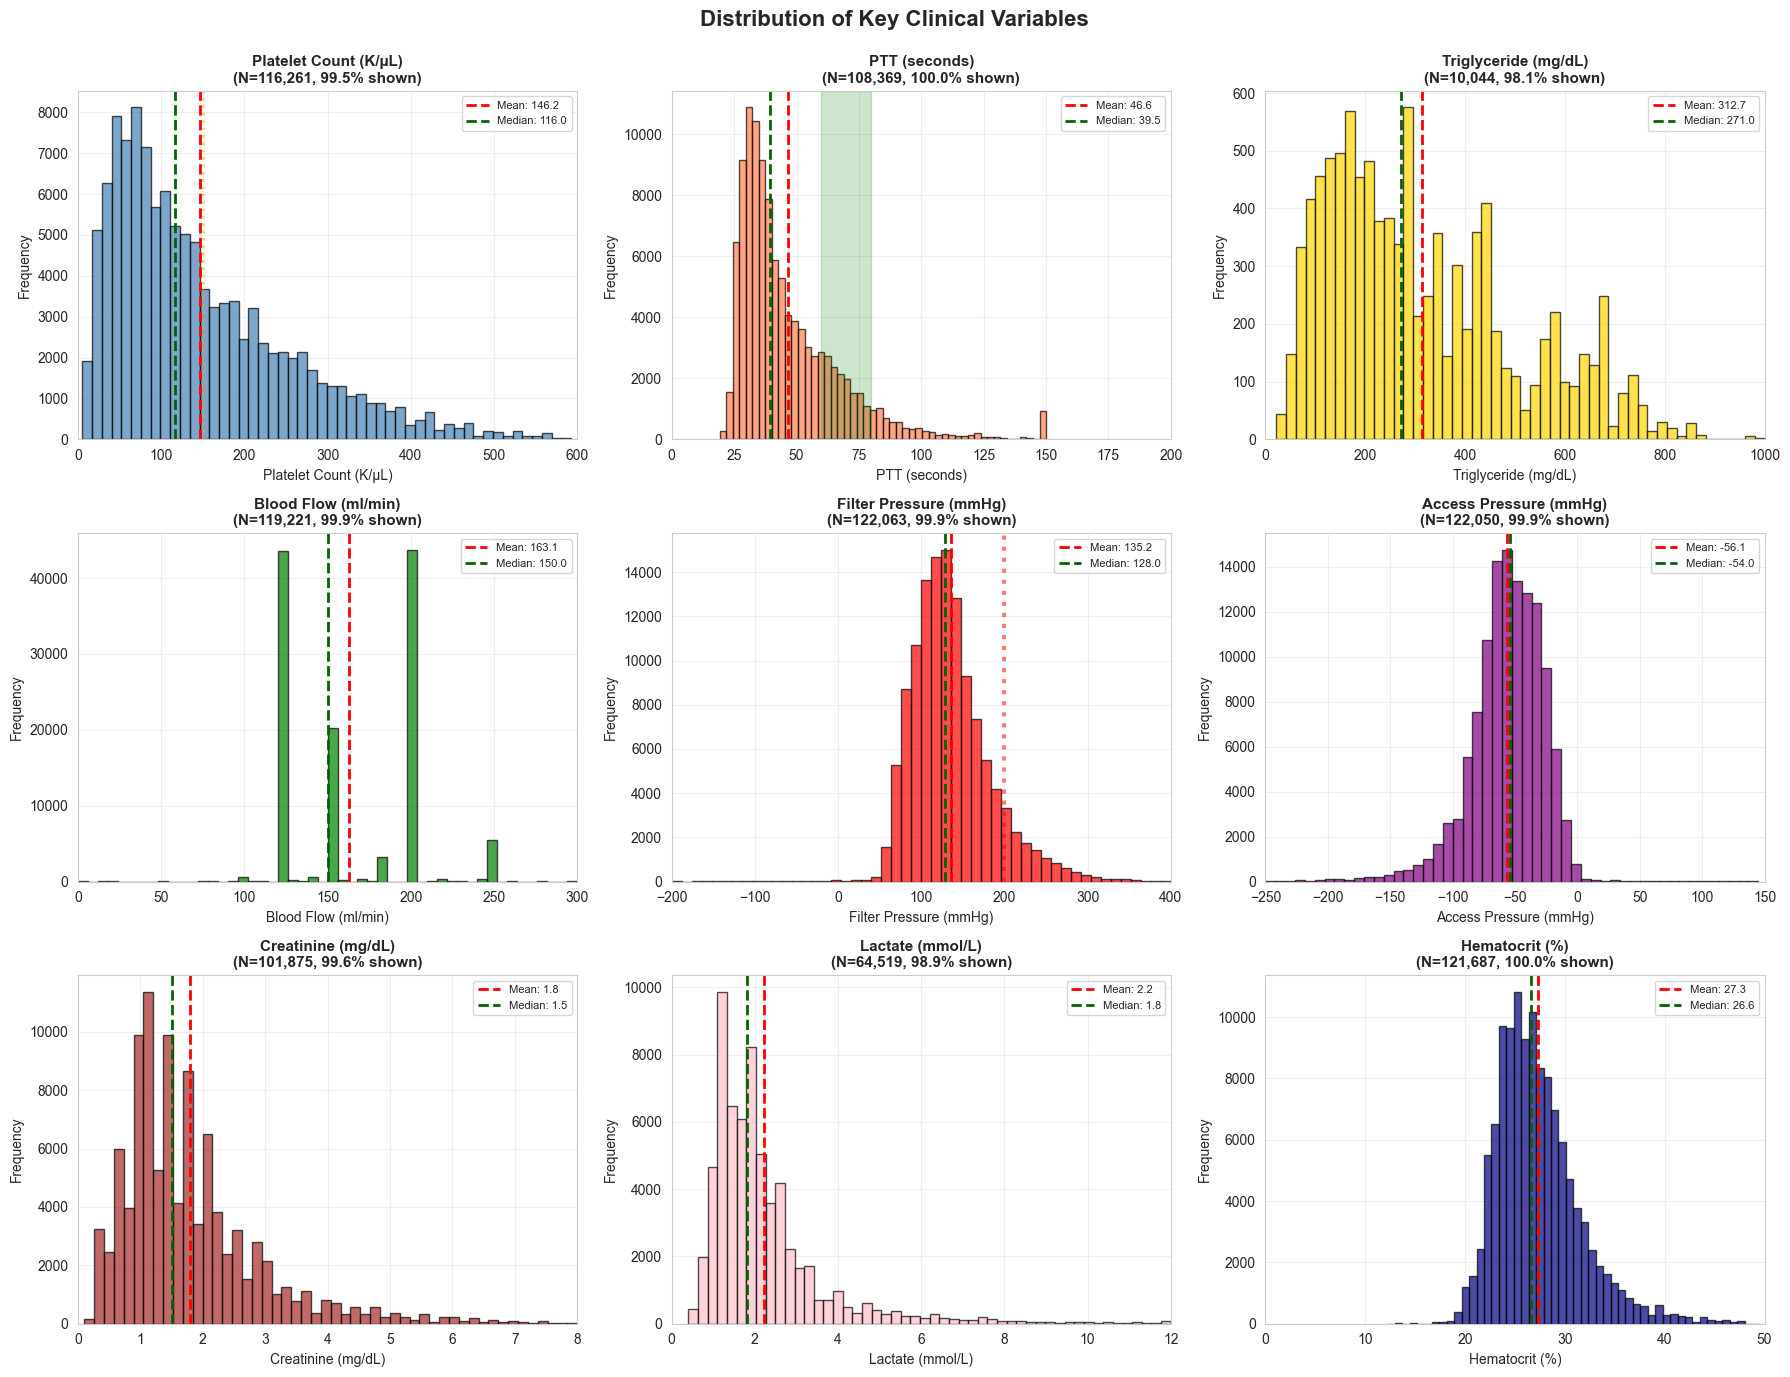


OUTLIER ANALYSIS

Percentage of extreme outliers (beyond 99th percentile):

platelet            :  1,155 ( 0.99%) above 518.0
ptt                 :  1,075 ( 0.99%) above 138.4
triglyceride        :    100 ( 1.00%) above 1140.0
blood_flow          :    248 ( 0.21%) above 250.0
filter_pressure     :  1,207 ( 0.99%) above 286.0
creatinine          :    992 ( 0.97%) above 6.4
lactate             :    633 ( 0.98%) above 12.2


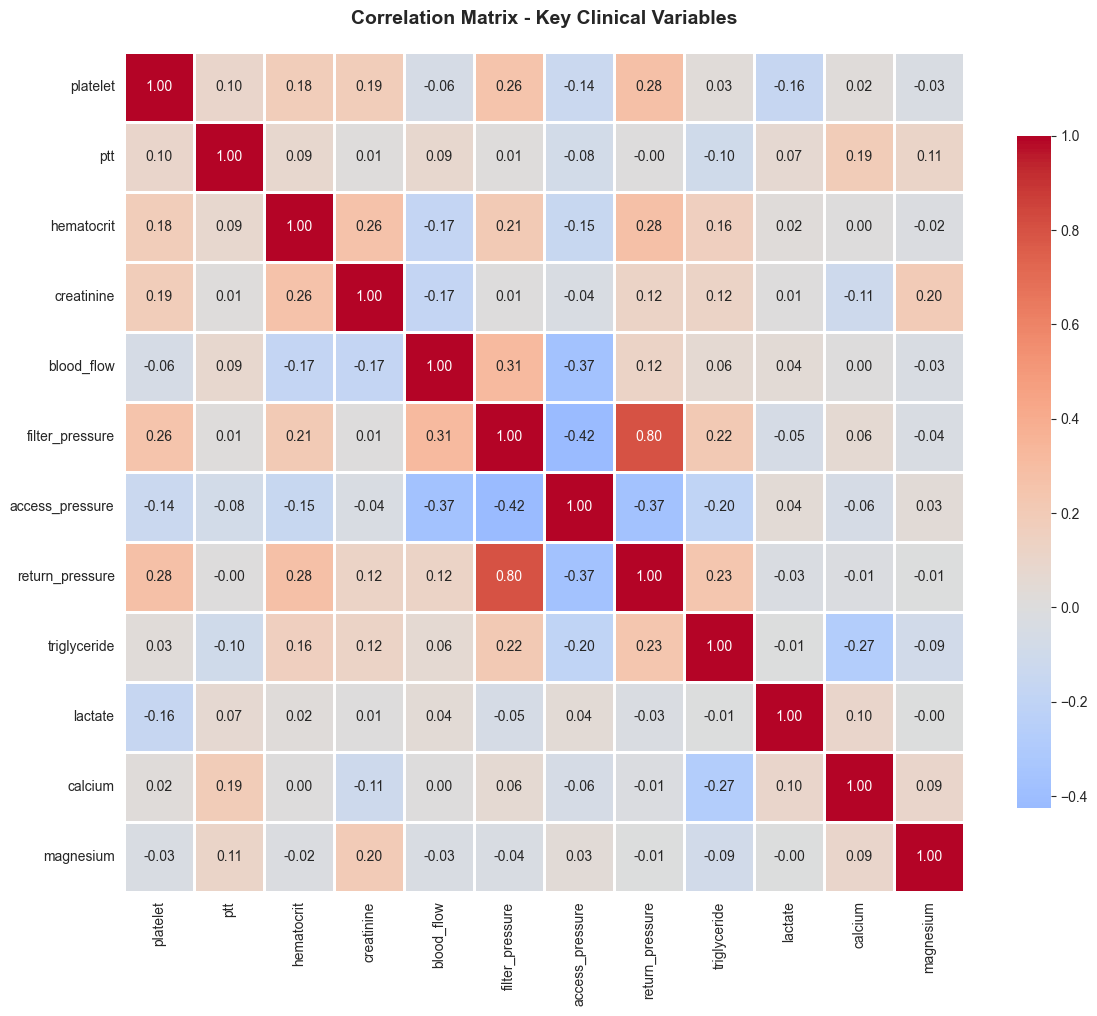

In [7]:
# ----------------------------------------------------------------
# FIGURE 1: Distribution of Key Variables
# ----------------------------------------------------------------
# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (16, 12)

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle('Distribution of Key Clinical Variables\n', fontsize=16, fontweight='bold')

key_vars = [
    ('platelet', 'Platelet Count (K/µL)', 'steelblue', (0, 600)),  # Cut off extreme outliers
    ('ptt', 'PTT (seconds)', 'coral', (0, 200)),  # Focus on clinically relevant range
    ('triglyceride', 'Triglyceride (mg/dL)', 'gold', (0, 1000)),  # Cut off extremes
    ('blood_flow', 'Blood Flow (ml/min)', 'green', (0, 300)),  # Focus on main distribution
    ('filter_pressure', 'Filter Pressure (mmHg)', 'red', (-200, 400)),  # Cut off outliers
    ('access_pressure', 'Access Pressure (mmHg)', 'purple', (-250, 150)),  # Should be negative
    ('creatinine', 'Creatinine (mg/dL)', 'brown', (0, 8)),  # Focus on relevant range
    ('lactate', 'Lactate (mmol/L)', 'pink', (0, 12)),  # Cut off extremes
    ('hematocrit', 'Hematocrit (%)', 'navy', (0, 50))  # Physiologic range
]

for idx, (var, title, color, xlim) in enumerate(key_vars):
    ax = axes[idx // 3, idx % 3]
    if var in df.columns:
        data = df[var].dropna()

        # Filter data to reasonable range for better visualization
        data_filtered = data[(data >= xlim[0]) & (data <= xlim[1])]

        if len(data_filtered) > 0:
            ax.hist(data_filtered, bins=50, edgecolor='black', alpha=0.7, color=color)

            # Add mean and median lines
            mean_val = data_filtered.mean()
            median_val = data_filtered.median()
            ax.axvline(mean_val, color='red', linestyle='--', linewidth=2,
                      label=f'Mean: {mean_val:.1f}')
            ax.axvline(median_val, color='darkgreen', linestyle='--', linewidth=2,
                      label=f'Median: {median_val:.1f}')

            # Set labels and limits
            ax.set_xlabel(title, fontsize=10)
            ax.set_ylabel('Frequency', fontsize=10)
            ax.set_xlim(xlim)

            # Show percentage of data included
            pct_included = (len(data_filtered) / len(data)) * 100
            ax.set_title(f'{title}\n(N={len(data):,}, {pct_included:.1f}% shown)',
                        fontsize=11, fontweight='bold')

            ax.legend(fontsize=8, loc='upper right')
            ax.grid(True, alpha=0.3)

            # Add reference lines for clinically important values
            if var == 'filter_pressure':
                ax.axvline(200, color='red', linestyle=':', linewidth=3,
                          label='High Pressure (≥200)', alpha=0.5)
            elif var == 'ptt':
                ax.axvspan(60, 80, alpha=0.2, color='green', label='Therapeutic Range')
            elif var == 'platelet':
                ax.axvline(150, color='orange', linestyle=':', linewidth=2,
                          label='Low (<150)', alpha=0.5)

    else:
        ax.text(0.5, 0.5, f'{var}\nNot Available', ha='center', va='center', fontsize=12)
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.show()

# ----------------------------------------------------------------
# ADDITIONAL: Show outlier information
# ----------------------------------------------------------------

print("\n" + "="*70)
print("OUTLIER ANALYSIS")
print("="*70)

outlier_vars = ['platelet', 'ptt', 'triglyceride', 'blood_flow', 'filter_pressure',
                'creatinine', 'lactate']

print("\nPercentage of extreme outliers (beyond 99th percentile):\n")
for var in outlier_vars:
    if var in df.columns:
        data = df[var].dropna()
        p99 = data.quantile(0.99)
        outliers = (data > p99).sum()
        pct = (outliers / len(data)) * 100
        print(f"{var:20s}: {outliers:6,} ({pct:5.2f}%) above {p99:.1f}")

# ----------------------------------------------------------------
# FIGURE 2: Correlation Heatmap
# ----------------------------------------------------------------

# Select numeric columns for correlation
numeric_cols = ['platelet', 'ptt', 'hematocrit', 'creatinine', 'blood_flow',
                'filter_pressure', 'access_pressure', 'return_pressure',
                'triglyceride', 'lactate', 'calcium', 'magnesium']

available_numeric = [col for col in numeric_cols if col in df.columns]
corr_data = df[available_numeric].dropna()

if len(corr_data) > 100:
    correlation_matrix = corr_data.corr()

    plt.figure(figsize=(12, 10))
    sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
    plt.title('Correlation Matrix - Key Clinical Variables', fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()
else:
    print("Insufficient data for correlation matrix")

## **Comparison by Outcome**


Creating improved box plots by outcome...


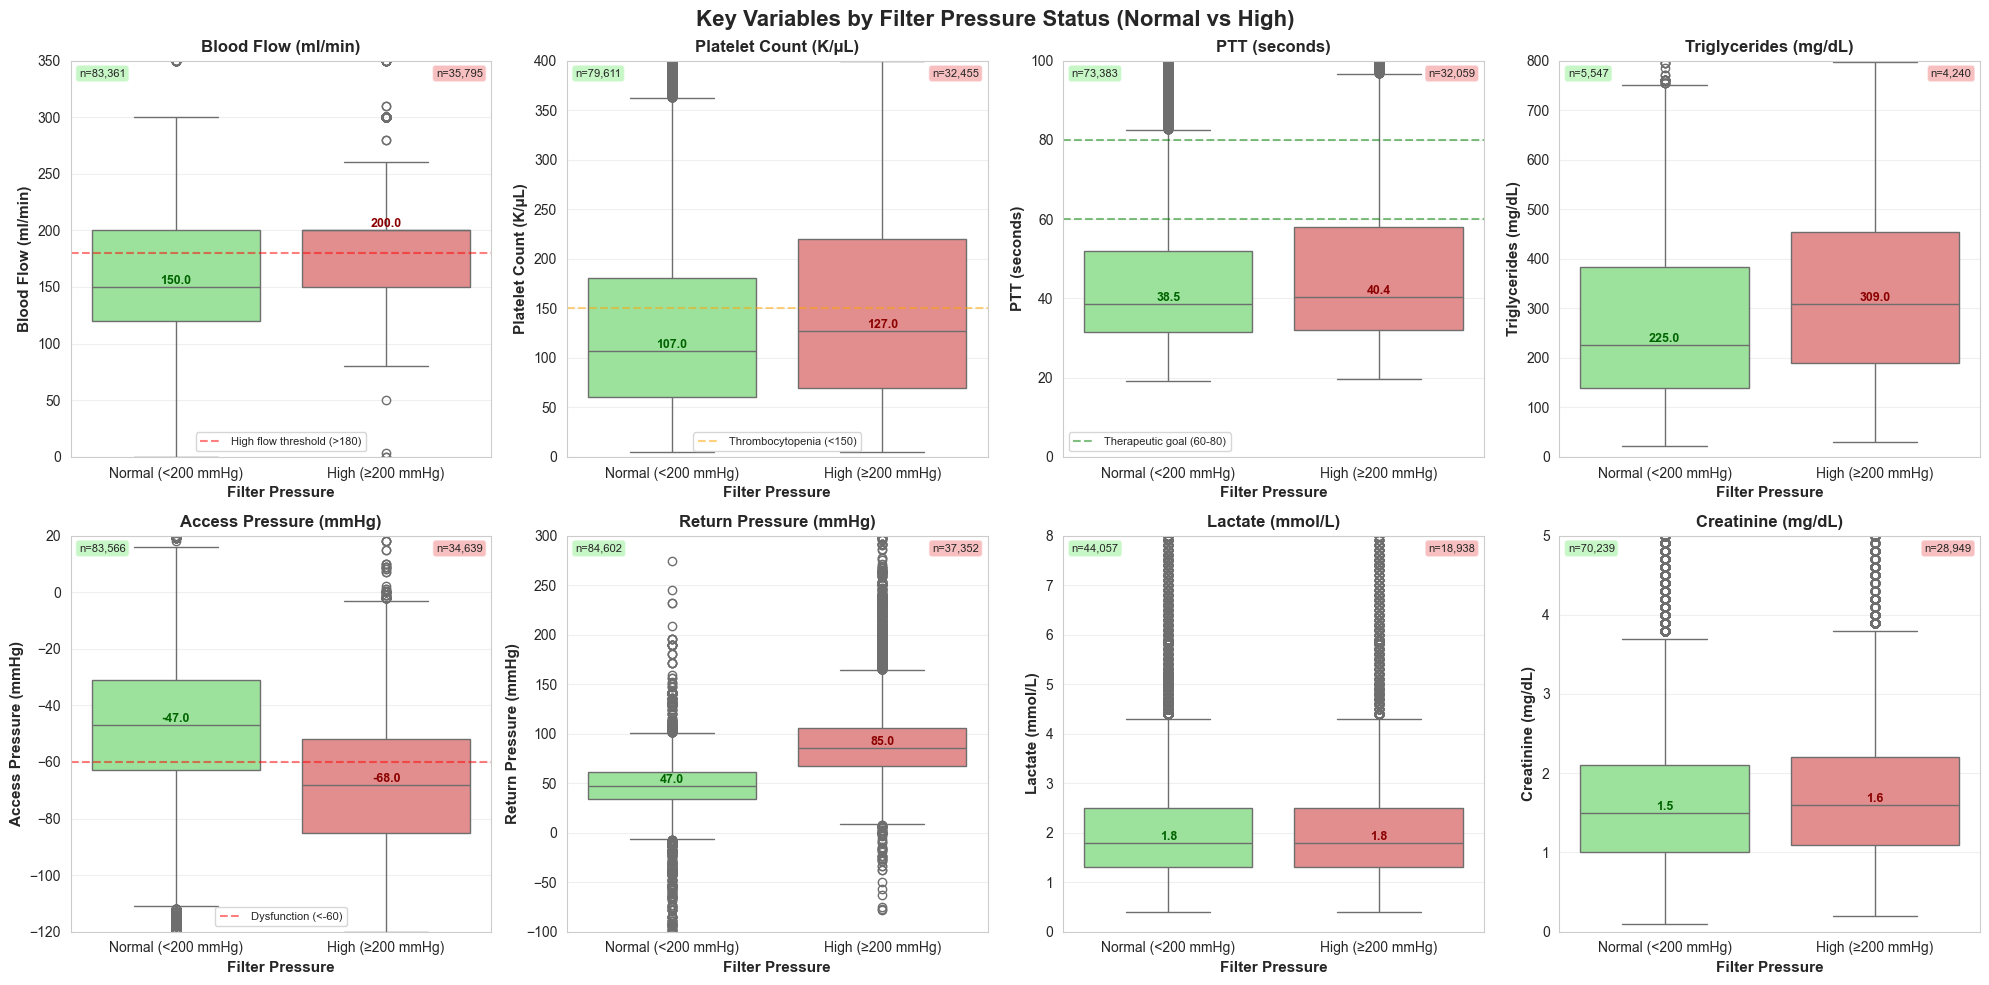


COMPARISON: NORMAL vs HIGH FILTER PRESSURE

               Variable  Normal_Median  High_Median  Difference  Normal_Mean  High_Mean
   Blood Flow (ml/min)          150.0        200.0        50.0       154.09     184.39
 Platelet Count (K/µL)          107.0        127.0        20.0       129.82     150.64
         PTT (seconds)           38.5         40.4         1.9        43.50      46.33
 Triglycerides (mg/dL)          225.0        309.0        84.0       278.65     348.23
Access Pressure (mmHg)          -47.0        -68.0       -21.0       -47.83     -68.25
Return Pressure (mmHg)           47.0         85.0        38.0        48.13      89.21
      Lactate (mmol/L)            1.8          1.8         0.0         2.12       2.14
    Creatinine (mg/dL)            1.5          1.6         0.1         1.66       1.79


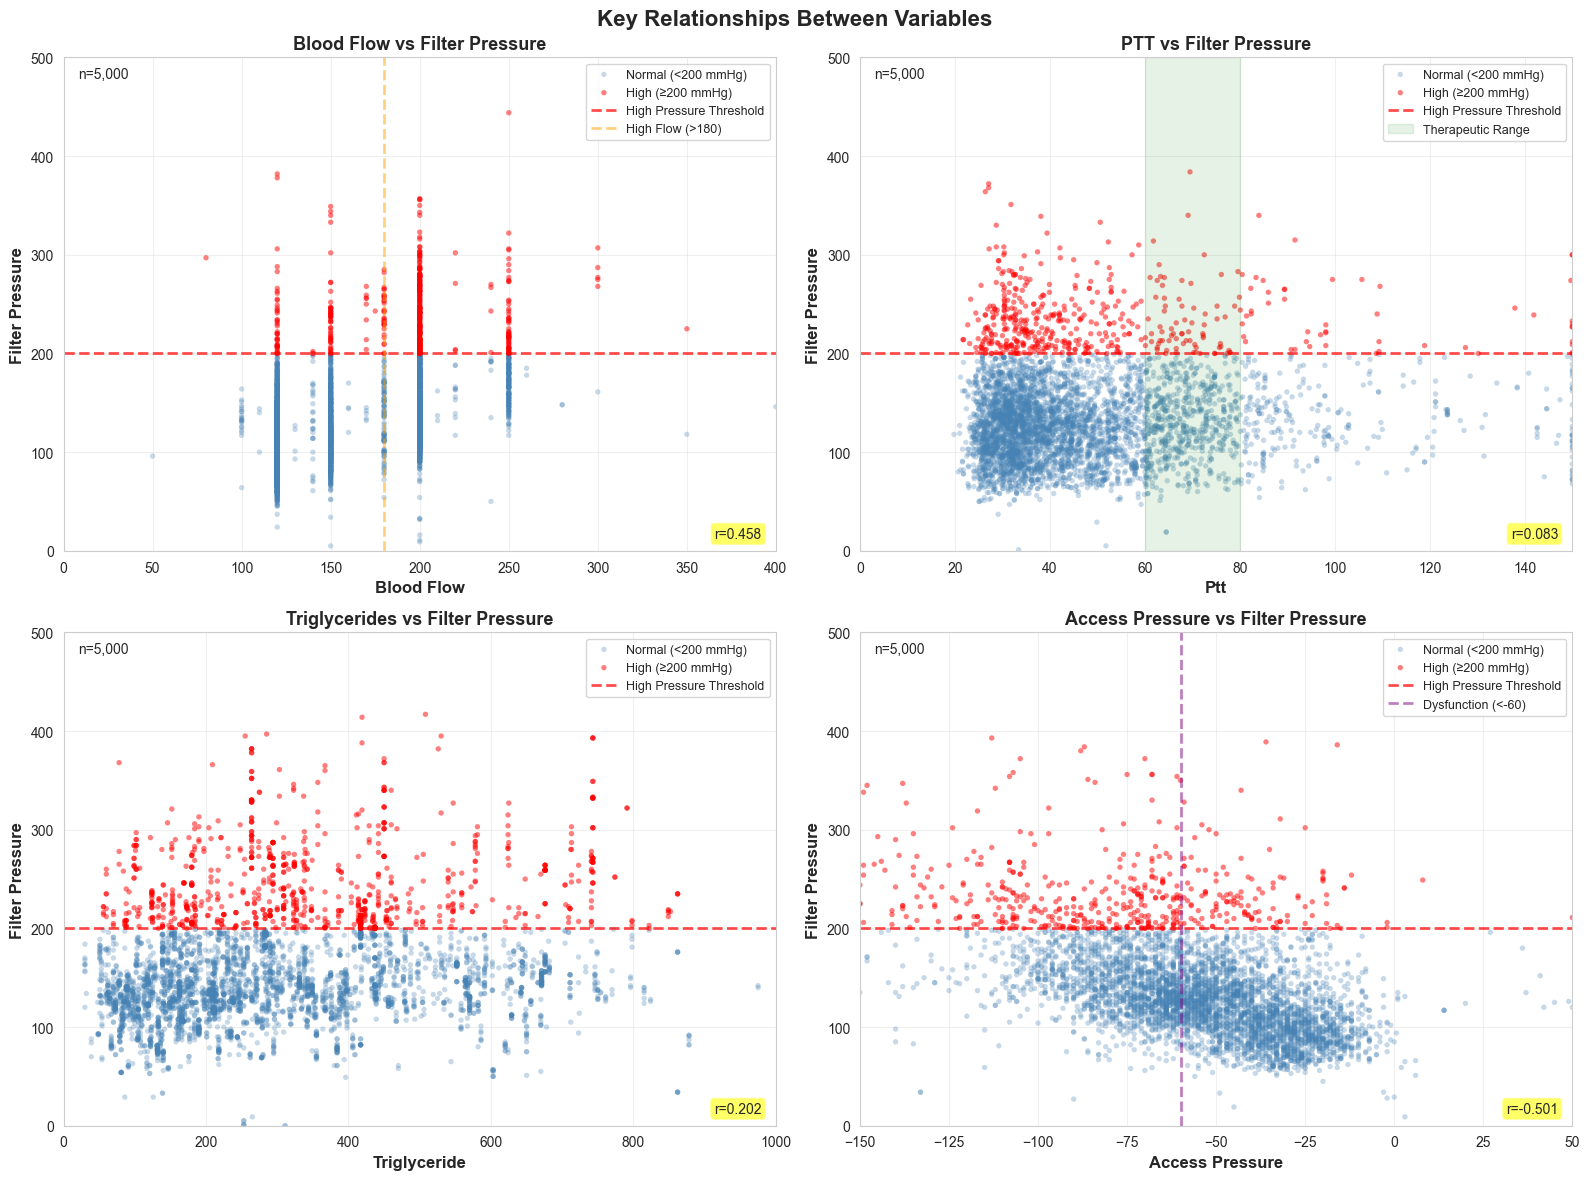

In [8]:
# ----------------------------------------------------------------
# FIGURE 3: Box Plots by Outcome
# ----------------------------------------------------------------

print("\nCreating improved box plots by outcome...")

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Key Variables by Filter Pressure Status (Normal vs High)', fontsize=16, fontweight='bold')

# Create outcome variable for visualization
df['high_pressure'] = (df['filter_pressure'] >= 150).astype(int)

# Define variables with better y-axis limits and outlier handling
boxplot_vars = [
    ('blood_flow', 'Blood Flow (ml/min)', (0, 350)),
    ('platelet', 'Platelet Count (K/µL)', (0, 400)),
    ('ptt', 'PTT (seconds)', (0, 100)),
    ('triglyceride', 'Triglycerides (mg/dL)', (0, 800)),
    ('access_pressure', 'Access Pressure (mmHg)', (-120, 20)),
    ('return_pressure', 'Return Pressure (mmHg)', (-100, 300)),
    ('lactate', 'Lactate (mmol/L)', (0, 8)),
    ('creatinine', 'Creatinine (mg/dL)', (0, 5))
]

for idx, (var, title, ylim) in enumerate(boxplot_vars):
    ax = axes[idx // 4, idx % 4]
    if var in df.columns:
        # Filter data to remove extreme outliers
        data_to_plot = df[[var, 'high_pressure']].dropna()
        data_to_plot = data_to_plot[(data_to_plot[var] >= ylim[0]) &
                                     (data_to_plot[var] <= ylim[1])]

        if len(data_to_plot) > 0:
            # Create boxplot
            sns.boxplot(data=data_to_plot, x='high_pressure', y=var, ax=ax,
                       palette=['lightgreen', 'lightcoral'], showfliers=True)

            # Set labels
            ax.set_xlabel('Filter Pressure', fontsize=11, fontweight='bold')
            ax.set_xticklabels(['Normal (<200 mmHg)', 'High (≥200 mmHg)'], fontsize=10)
            ax.set_ylabel(title, fontsize=11, fontweight='bold')
            ax.set_title(title, fontsize=12, fontweight='bold')
            ax.set_ylim(ylim)
            ax.grid(True, alpha=0.3, axis='y')

            # Calculate and display statistics
            normal_vals = data_to_plot[data_to_plot['high_pressure']==0][var]
            high_vals = data_to_plot[data_to_plot['high_pressure']==1][var]

            if len(normal_vals) > 0 and len(high_vals) > 0:
                normal_median = normal_vals.median()
                high_median = high_vals.median()

                # Add median values as text
                ax.text(0, normal_median, f'{normal_median:.1f}',
                       ha='center', va='bottom', fontsize=9, fontweight='bold', color='darkgreen')
                ax.text(1, high_median, f'{high_median:.1f}',
                       ha='center', va='bottom', fontsize=9, fontweight='bold', color='darkred')

                # Add reference lines for clinical thresholds
                if var == 'ptt':
                    ax.axhline(y=60, color='green', linestyle='--', linewidth=1.5,
                              alpha=0.5, label='Therapeutic goal (60-80)')
                    ax.axhline(y=80, color='green', linestyle='--', linewidth=1.5, alpha=0.5)
                    ax.legend(fontsize=8)
                elif var == 'platelet':
                    ax.axhline(y=150, color='orange', linestyle='--', linewidth=1.5,
                              alpha=0.5, label='Thrombocytopenia (<150)')
                    ax.legend(fontsize=8)
                elif var == 'blood_flow':
                    ax.axhline(y=180, color='red', linestyle='--', linewidth=1.5,
                              alpha=0.5, label='High flow threshold (>180)')
                    ax.legend(fontsize=8)
                elif var == 'access_pressure':
                    ax.axhline(y=-60, color='red', linestyle='--', linewidth=1.5,
                              alpha=0.5, label='Dysfunction (<-60)')
                    ax.legend(fontsize=8)

            # Show sample sizes
            n_normal = len(normal_vals)
            n_high = len(high_vals)
            ax.text(0.02, 0.98, f'n={n_normal:,}', transform=ax.transAxes,
                   fontsize=8, va='top', ha='left', bbox=dict(boxstyle='round',
                   facecolor='lightgreen', alpha=0.5))
            ax.text(0.98, 0.98, f'n={n_high:,}', transform=ax.transAxes,
                   fontsize=8, va='top', ha='right', bbox=dict(boxstyle='round',
                   facecolor='lightcoral', alpha=0.5))
    else:
        ax.text(0.5, 0.5, f'{var}\nNot Available', ha='center', va='center', fontsize=12)
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.show()

# ----------------------------------------------------------------
# Print comparison statistics
# ----------------------------------------------------------------

print("\n" + "="*70)
print("COMPARISON: NORMAL vs HIGH FILTER PRESSURE")
print("="*70)

comparison_results = []
for var, title, ylim in boxplot_vars:
    if var in df.columns:
        normal_vals = df[df['high_pressure']==0][var].dropna()
        high_vals = df[df['high_pressure']==1][var].dropna()

        # Filter to reasonable range
        normal_vals = normal_vals[(normal_vals >= ylim[0]) & (normal_vals <= ylim[1])]
        high_vals = high_vals[(high_vals >= ylim[0]) & (high_vals <= ylim[1])]

        if len(normal_vals) > 0 and len(high_vals) > 0:
            comparison_results.append({
                'Variable': title,
                'Normal_Median': normal_vals.median(),
                'High_Median': high_vals.median(),
                'Difference': high_vals.median() - normal_vals.median(),
                'Normal_Mean': round(normal_vals.mean(), 2),
                'High_Mean': round(high_vals.mean(), 2)
            })

comparison_df = pd.DataFrame(comparison_results)
print("\n", comparison_df.to_string(index=False))


# ----------------------------------------------------------------
# FIGURE 4: Scatter Plots - Key Relationships
# ----------------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Key Relationships Between Variables', fontsize=16, fontweight='bold')

# Define scatter pairs with appropriate axis limits
scatter_pairs = [
    ('blood_flow', 'filter_pressure', 'Blood Flow vs Filter Pressure',
     (0, 400), (0, 500)),
    ('ptt', 'filter_pressure', 'PTT vs Filter Pressure',
     (0, 150), (0, 500)),
    ('triglyceride', 'filter_pressure', 'Triglycerides vs Filter Pressure',
     (0, 1000), (0, 500)),
    ('access_pressure', 'filter_pressure', 'Access Pressure vs Filter Pressure',
     (-150, 50), (0, 500))
]

for idx, (x_var, y_var, title, xlim, ylim) in enumerate(scatter_pairs):
    ax = axes[idx // 2, idx % 2]
    if x_var in df.columns and y_var in df.columns:
        # Filter data to remove outliers
        plot_data = df[[x_var, y_var]].dropna()
        plot_data = plot_data[
            (plot_data[x_var] >= xlim[0]) & (plot_data[x_var] <= xlim[1]) &
            (plot_data[y_var] >= ylim[0]) & (plot_data[y_var] <= ylim[1])
        ]

        # Sample if too many points (for performance)
        if len(plot_data) > 5000:
            plot_data = plot_data.sample(5000, random_state=42)

        if len(plot_data) > 0:
            # Create scatter plot with color based on high pressure
            plot_data['high_pressure'] = (plot_data[y_var] >= 200).astype(int)

            # Plot normal pressure in blue, high pressure in red
            normal = plot_data[plot_data['high_pressure'] == 0]
            high = plot_data[plot_data['high_pressure'] == 1]

            ax.scatter(normal[x_var], normal[y_var], alpha=0.3, s=15,
                      c='steelblue', label='Normal (<200 mmHg)', edgecolors='none')
            ax.scatter(high[x_var], high[y_var], alpha=0.5, s=15,
                      c='red', label='High (≥200 mmHg)', edgecolors='none')

            # Add horizontal line at high pressure threshold
            ax.axhline(y=200, color='red', linestyle='--', linewidth=2,
                      label='High Pressure Threshold', alpha=0.7)

            # Add vertical reference lines for specific variables
            if x_var == 'blood_flow':
                ax.axvline(x=180, color='orange', linestyle='--', linewidth=2,
                          label='High Flow (>180)', alpha=0.5)
            elif x_var == 'ptt':
                ax.axvspan(60, 80, alpha=0.1, color='green', label='Therapeutic Range')
            elif x_var == 'access_pressure':
                ax.axvline(x=-60, color='purple', linestyle='--', linewidth=2,
                          label='Dysfunction (<-60)', alpha=0.5)

            # Set labels and limits
            ax.set_xlabel(x_var.replace('_', ' ').title(), fontsize=12, fontweight='bold')
            ax.set_ylabel(y_var.replace('_', ' ').title(), fontsize=12, fontweight='bold')
            ax.set_title(title, fontsize=13, fontweight='bold')
            ax.set_xlim(xlim)
            ax.set_ylim(ylim)
            ax.legend(fontsize=9, loc='best')
            ax.grid(True, alpha=0.3)

            # Add sample size
            ax.text(0.02, 0.98, f'n={len(plot_data):,}',
                   transform=ax.transAxes, fontsize=10, va='top', ha='left',
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

            # Calculate and display correlation
            corr = plot_data[x_var].corr(plot_data[y_var])
            ax.text(0.98, 0.02, f'r={corr:.3f}',
                   transform=ax.transAxes, fontsize=10, va='bottom', ha='right',
                   bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.6))
    else:
        ax.text(0.5, 0.5, f'Data not available', ha='center', va='center', fontsize=12)
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.show()




## **Missing Data**


MISSING DATA ANALYSIS

Variables with Missing Data (Top 20):
            Variable  Missing Count  Missing %
        antithrombin         125611     100.00
            globulin         125553      99.95
            thrombin         125511      99.92
       total_protein         125425      99.85
     ldl_cholesterol         125292      99.75
     hdl_cholesterol         125126      99.61
             d_dimer         123300      98.16
        triglyceride         115567      92.00
             albumin         109938      87.52
          fibrinogen          99359      79.10
                 ldh          74317      59.16
             lactate          61092      48.64
        heparin_dose          52839      42.07
ultrafiltrate_output          29891      23.80
             calcium          25682      20.45
                 bun          24012      19.12
          creatinine          23736      18.90
             citrate          23570      18.76
                 inr          22658      18.0

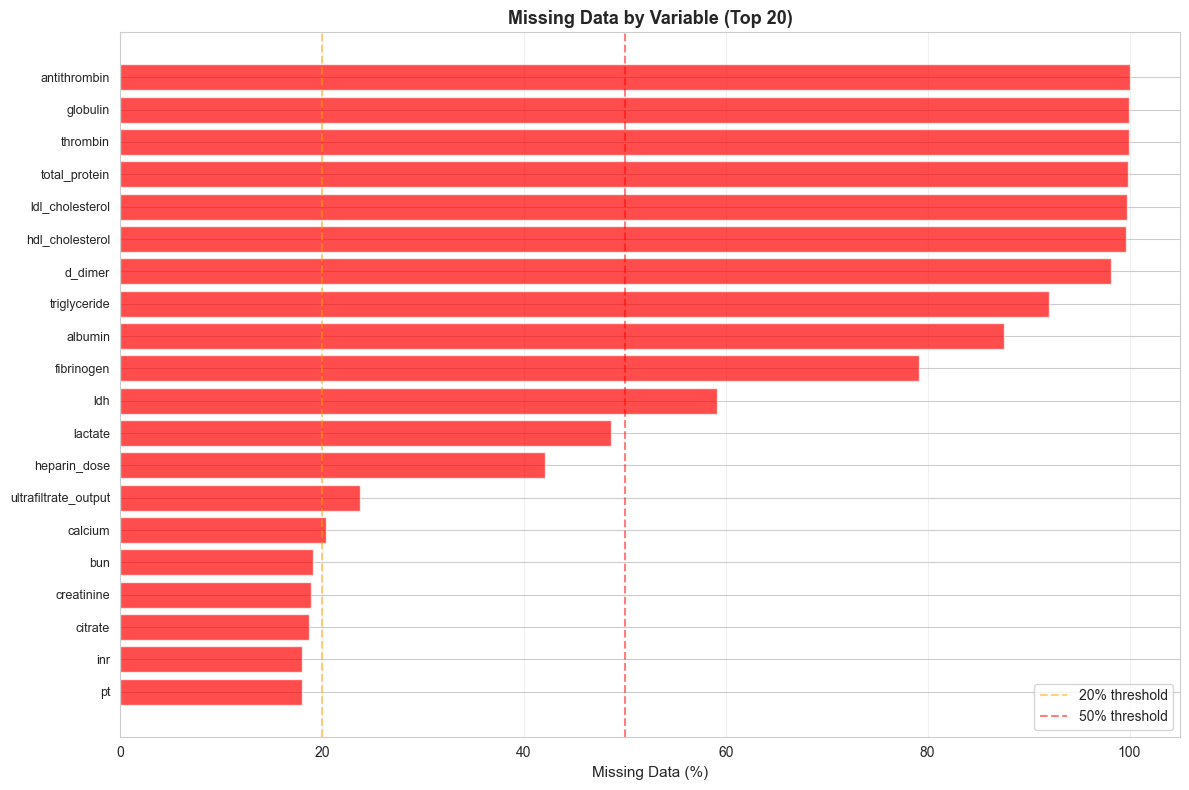

In [9]:
# ----------------------------------------------------------------
# MISSING DATA ANALYSIS
# ----------------------------------------------------------------

print("\n" + "="*70)
print("MISSING DATA ANALYSIS")
print("="*70)

missing_summary = []
for col in available_continuous:
    missing_count = df[col].isna().sum()
    missing_pct = round((missing_count / len(df)) * 100, 2)
    if missing_count > 0:
        missing_summary.append({
            'Variable': col,
            'Missing Count': missing_count,
            'Missing %': missing_pct
        })

missing_df = pd.DataFrame(missing_summary).sort_values('Missing %', ascending=False)

print("\nVariables with Missing Data (Top 20):")
print(missing_df.head(20).to_string(index=False))

# Visualize missing data
if len(missing_df) > 0:
    fig, ax = plt.subplots(figsize=(12, 8))
    top_missing = missing_df.head(20).sort_values('Missing %')
    colors = ['red']
    ax.barh(range(len(top_missing)), top_missing['Missing %'], color=colors, alpha=0.7)
    ax.set_yticks(range(len(top_missing)))
    ax.set_yticklabels(top_missing['Variable'], fontsize=9)
    ax.set_xlabel('Missing Data (%)', fontsize=11)
    ax.set_title('Missing Data by Variable (Top 20)', fontsize=13, fontweight='bold')
    ax.axvline(x=20, color='orange', linestyle='--', alpha=0.5, label='20% threshold')
    ax.axvline(x=50, color='red', linestyle='--', alpha=0.5, label='50% threshold')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()

### Drop features with >80% missing data

In [10]:
# ================================================================
# REMOVE FEATURES WITH >80% MISSING DATA
# ================================================================

print("="*70)
print("REMOVING LOW-QUALITY FEATURES")
print("="*70)

# Calculate missing percentage for ALL features (not just specific groups)
missing_threshold = 0.80
id_cols = ['subject_id', 'hadm_id', 'stay_id', 'charttime']
target_col = 'clots_corrected'  # Our prediction target (1=clot, 0=no clot)

# Get all columns except IDs and target
potential_features = [col for col in df.columns if col not in id_cols + [target_col, 'clots']]

# Calculate missing percentages
missing_pct = df[potential_features].isnull().sum() / len(df)

# Find features with too much missing data
high_missing_features = missing_pct[missing_pct > missing_threshold].sort_values(ascending=False)

print(f"\nAnalyzing {len(potential_features)} features...")
print(f"Threshold: >{missing_threshold*100}% missing data\n")

if len(high_missing_features) > 0:
    print(f"Found {len(high_missing_features)} features with >{missing_threshold*100}% missing data:")
    print("-" * 60)
    for feat, pct in high_missing_features.items():
        print(f"  {feat:.<50} {pct*100:>6.1f}% missing")
    print("-" * 60)

    # Remove these features from the dataframe
    df = df.drop(columns=high_missing_features.index.tolist())
    print(f"\n Removed {len(high_missing_features)} low-quality features")
else:
    print(" No features have more than 80% missing data")

print(f"\n Remaining columns in dataset: {len(df.columns)}")
print(f"  (This includes IDs, target, and all usable features)")

REMOVING LOW-QUALITY FEATURES

Analyzing 60 features...
Threshold: >80.0% missing data

Found 14 features with >80.0% missing data:
------------------------------------------------------------
  antithrombin......................................  100.0% missing
  globulin..........................................  100.0% missing
  thrombin..........................................   99.9% missing
  clotted...........................................   99.9% missing
  total_protein.....................................   99.9% missing
  ldl_cholesterol...................................   99.7% missing
  bicarbonate_1.....................................   99.7% missing
  hdl_cholesterol...................................   99.6% missing
  ldl_source........................................   99.5% missing
  clots_increasing..................................   98.3% missing
  d_dimer...........................................   98.2% missing
  triglyceride..................................

## Outcome Analysis

PATIENT-LEVEL CLOTS ANALYSIS

Total unique patients: 1,971

Patients who had visible clots: 1,791
Patients who never had clots: 180

Proportion of patients with clots: 90.87%

------------------------------------------------------------
Distribution of clots observations per patient (among those with clots):
count    1791.000000
mean       63.440536
std       150.819514
min         1.000000
25%         8.000000
50%        24.000000
75%        65.000000
max      2803.000000
Name: num_clots_observations, dtype: float64


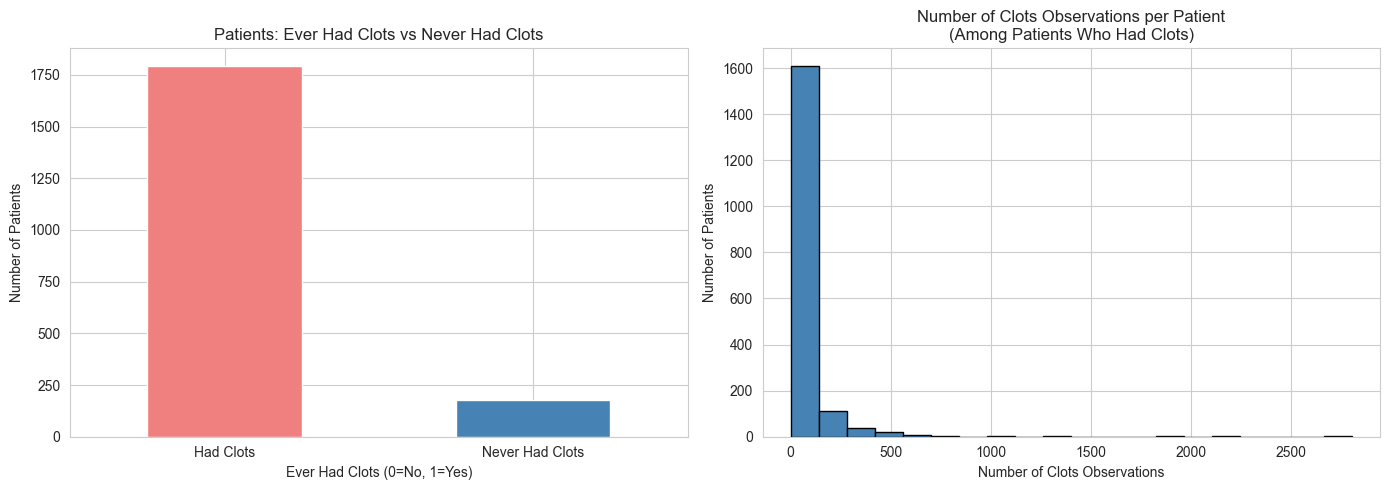

In [11]:
# Patient-level clots analysis
print("=" * 60)
print("PATIENT-LEVEL CLOTS ANALYSIS")
print("=" * 60)

# For each patient, check if they had visible clots
patient_clots = df.groupby('subject_id')['clots'].agg(['max', 'sum', 'count'])
patient_clots.columns = ['ever_had_clots', 'num_clots_observations', 'total_observations']

print(f"\nTotal unique patients: {len(patient_clots):,}")
print(f"\nPatients who had visible clots: {(patient_clots['ever_had_clots'] == 1).sum():,}")
print(f"Patients who never had clots: {(patient_clots['ever_had_clots'] == 0).sum():,}")
print(f"\nProportion of patients with clots: {(patient_clots['ever_had_clots'] == 1).mean()*100:.2f}%")

print("\n" + "-" * 60)
print("Distribution of clots observations per patient (among those with clots):")
print(patient_clots[patient_clots['ever_had_clots'] == 1]['num_clots_observations'].describe())

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Patient-level clots
patient_clots['ever_had_clots'].value_counts().plot(kind='bar', ax=axes[0], color=['lightcoral', 'steelblue'])
axes[0].set_title('Patients: Ever Had Clots vs Never Had Clots')
axes[0].set_xlabel('Ever Had Clots (0=No, 1=Yes)')
axes[0].set_ylabel('Number of Patients')
axes[0].set_xticklabels(['Had Clots', 'Never Had Clots'], rotation=0)

# Distribution of clots observations among patients who had clots
clots_patients = patient_clots[patient_clots['ever_had_clots'] == 1]
clots_patients['num_clots_observations'].hist(bins=20, ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title('Number of Clots Observations per Patient\n(Among Patients Who Had Clots)')
axes[1].set_xlabel('Number of Clots Observations')
axes[1].set_ylabel('Number of Patients')

plt.tight_layout()
plt.show()

# **Feature Engineering**

## **Define Original Feature Groups**

In [12]:
# Define ID columns and target
id_cols = ['subject_id', 'hadm_id', 'stay_id', 'charttime']
target_col = 'clots_corrected'  # Our prediction target (1=clot, 0=no clot)

# Document feature groups for reference
# (Create the actual feature_cols list after feature engineering)

crrt_machine_params = [
    'crrt_mode', 'access_pressure', 'blood_flow', 'citrate', 'current_goal',
    'dialysate_fluid', 'dialysate_rate', 'effluent_pressure', 'filter_pressure',
    'heparin_concentration', 'heparin_dose', 'hourly_patient_fluid_removal',
    'prefilter_replacement_rate', 'postfilter_replacement_rate',
    'replacement_fluid', 'replacement_rate', 'return_pressure',
    'ultrafiltrate_output', 'system_active'
]
# demographics and lines
demographics = ['race', 'line_type', 'line_site']

lab_values = [
    # Complete Blood Count
    'hematocrit', 'platelet', 'rbc', 'wbc',
    # Coagulation
    'd_dimer', 'fibrinogen', 'thrombin', 'inr', 'pt', 'ptt',
    # Chemistry
    'albumin', 'globulin', 'total_protein', 'aniongap', 'bicarbonate',
    'bun', 'calcium', 'chloride', 'creatinine', 'glucose', 'sodium', 'potassium'
]

print("Feature groups defined:")
print(f"  - ID columns: {len(id_cols)}")
print(f"  - CRRT machine parameters: {len(crrt_machine_params)}")
print(f"  - Demographics: {len(demographics)}")
print(f"  - Lab values: {len(lab_values)}")
print(f"\n  - TARGET: '{target_col}' (1=clot, 0=no clot)")

# Note: create feature_cols list after all feature engineering is complete

Feature groups defined:
  - ID columns: 4
  - CRRT machine parameters: 19
  - Demographics: 3
  - Lab values: 22

  - TARGET: 'clots_corrected' (1=clot, 0=no clot)


## Feature Engineering

### Create interaction, ratio, and polynomial features

In [13]:
# ================================================================
# CREATE INTERACTION AND RATIO FEATURES
# ================================================================

print("="*70)
print("CREATING ENGINEERED FEATURES")
print("="*70)

features_created = []

# === INTERACTION FEATURES ===
print("\n1. Creating interaction features...")

# BUN/Creatinine ratio (classic kidney function marker)
if 'bun' in df.columns and 'creatinine' in df.columns:
    df['bun_creatinine_ratio'] = df['bun'] / (df['creatinine'] + 1e-6)
    features_created.append('bun_creatinine_ratio')

# Platelet * PTT interaction (clotting capacity)
if 'platelet' in df.columns and 'ptt' in df.columns:
    df['platelet_ptt_interaction'] = df['platelet'] * df['ptt']
    features_created.append('platelet_ptt_interaction')

# Hematocrit * Blood Flow (blood viscosity effect)
if 'hematocrit' in df.columns and 'blood_flow' in df.columns:
    df['hct_bloodflow_interaction'] = df['hematocrit'] * df['blood_flow']
    features_created.append('hct_bloodflow_interaction')

# === RATIO FEATURES ===
print("2. Creating ratio features...")

# WBC/RBC ratio (immune/red cell balance)
if 'wbc' in df.columns and 'rbc' in df.columns:
    df['wbc_rbc_ratio'] = df['wbc'] / (df['rbc'] + 1e-6)
    features_created.append('wbc_rbc_ratio')

# Platelet/WBC ratio
if 'platelet' in df.columns and 'wbc' in df.columns:
    df['platelet_wbc_ratio'] = df['platelet'] / (df['wbc'] + 1e-6)
    features_created.append('platelet_wbc_ratio')

# Calcium/Albumin ratio (corrected calcium)
if 'calcium' in df.columns and 'albumin' in df.columns:
    df['calcium_albumin_ratio'] = df['calcium'] / (df['albumin'] + 1e-6)
    features_created.append('calcium_albumin_ratio')

# Blood flow / filter pressure ratio (flow efficiency)
if 'blood_flow' in df.columns and 'filter_pressure' in df.columns:
    df['flow_pressure_ratio'] = df['blood_flow'] / (df['filter_pressure'] + 1e-6)
    features_created.append('flow_pressure_ratio')

# === POLYNOMIAL FEATURES (for key predictors) ===
print("3. Creating polynomial features...")

# Squared terms for potentially non-linear relationships

if 'platelet' in df.columns:
    df['platelets_squared'] = df['platelet'] ** 2
    features_created.append('platelets_squared')

print(f"\n Created {len(features_created)} new features:")
for feat in features_created:
    print(f"  - {feat}")

CREATING ENGINEERED FEATURES

1. Creating interaction features...
2. Creating ratio features...
3. Creating polynomial features...

 Created 7 new features:
  - bun_creatinine_ratio
  - platelet_ptt_interaction
  - hct_bloodflow_interaction
  - wbc_rbc_ratio
  - platelet_wbc_ratio
  - flow_pressure_ratio
  - platelets_squared


In [14]:
# =========================
# Create Filtration Fraction Feature Group
# =========================

if (
    'blood_flow' in df.columns and
    'ultrafiltrate_output' in df.columns and
    'hematocrit' in df.columns
):

    # Convert UF from mL/hr → mL/min
    uf_min = df['ultrafiltrate_output'] / 60.0

    # Ensure hematocrit values make sense (e.g., 0–0.7 range)
    df['hematocrit'] = df['hematocrit'].clip(lower=0, upper=0.7)

    # Plasma fraction (1 - Hct)
    plasma_fraction = (1 - df['hematocrit'])

    # FF formula
    df['filtration_fraction'] = uf_min / (df['blood_flow'] * plasma_fraction + 1e-6)

    # Keep FF in physiologic range
    df['filtration_fraction'] = df['filtration_fraction'].clip(0, 1)

    features_created.append('filtration_fraction')


In [15]:
# =========================
# Create Effluent-to-Blood Flow Ratio (EBR) Feature Group
# =========================

effluent_components = [
    'dialysate_rate',
    'prefilter_replacement_rate',
    'postfilter_replacement_rate',
    'ultrafiltrate_output'
]

# Only use the columns available in your dataset
effluent_cols = [c for c in effluent_components if c in df.columns]

if effluent_cols and 'blood_flow' in df.columns:

    # Sum effluent components (mL/hr)
    df['effluent_rate_hr'] = df[effluent_cols].sum(axis=1)

    # Convert to mL/min
    df['effluent_rate_min'] = df['effluent_rate_hr'] / 60.0

    # Compute ratio
    df['effluent_bloodflow_ratio'] = df['effluent_rate_min'] / (df['blood_flow'] + 1e-6)

    # Clean ranges—avoid insane ratios
    df['effluent_bloodflow_ratio'] = df['effluent_bloodflow_ratio'].clip(0, 2)

    features_created.append('effluent_bloodflow_ratio')

    # Optional: drop intermediate columns
    df.drop(columns=['effluent_rate_hr', 'effluent_rate_min'], inplace=True)


### Temporal features

In [16]:
# ================================================================
# CREATE TEMPORAL FEATURES
# ================================================================

print("="*70)
print("CREATING TEMPORAL FEATURES")
print("="*70)

temporal_features_created = []

# Convert charttime to datetime first!
df['charttime'] = pd.to_datetime(df['charttime'])

# Sort by patient and time
df = df.sort_values(['stay_id', 'charttime'])

# Time since last measurement (within patient) - CREATE BUT DON'T INCLUDE AS FEATURE
df['hours_since_last'] = df.groupby('stay_id')['charttime'].diff().dt.total_seconds() / 3600
df['hours_since_last'] = df['hours_since_last'].fillna(0)
# DON'T add to temporal_features_created - this is just for calculation
print("Created: hours_since_last (for rate calculations only)")

# IMPORTANT: Rate of change features (these are powerful!)
print("\n3. Creating rate-of-change features...")

rate_change_features = ['platelet', 'ptt', 'creatinine', 'hematocrit']

for feature in rate_change_features:
    if feature in df.columns:
        # Calculate change from previous measurement
        df[f'{feature}_change'] = df.groupby('stay_id')[feature].diff()

        # Calculate rate of change (change per hour)
        df[f'{feature}_change_rate'] = (
            df[f'{feature}_change'] / (df['hours_since_last'] + 0.01)
        )

        # Fill NaN for first observation per patient
        df[f'{feature}_change'] = df[f'{feature}_change'].fillna(0)
        df[f'{feature}_change_rate'] = df[f'{feature}_change_rate'].fillna(0)

        temporal_features_created.append(f'{feature}_change')
        temporal_features_created.append(f'{feature}_change_rate')
        print(f"  ✓ Created: {feature}_change and {feature}_change_rate")
    else:
        print(f" Skipped {feature} (not in dataset)")

# Remove hours_since_last from the dataframe
df = df.drop(columns=['hours_since_last'])
print("Removed: hours_since_last (was only needed for rate calculations)")

# Patient history features
print("\n4. Creating patient history features...")
print("  NOTE: These features look at PAST clots only")

# Check which target column exists
if 'clots_corrected' in df.columns:
    clot_col = 'clots_corrected'
elif 'clots' in df.columns:
    clot_col = 'clots'
else:
    clot_col = None
    print("  WARNING: No clots column found - skipping history features")

print(f"\n✓ Created {len(temporal_features_created)} temporal features:")

CREATING TEMPORAL FEATURES
Created: hours_since_last (for rate calculations only)

3. Creating rate-of-change features...
  ✓ Created: platelet_change and platelet_change_rate
  ✓ Created: ptt_change and ptt_change_rate
  ✓ Created: creatinine_change and creatinine_change_rate
  ✓ Created: hematocrit_change and hematocrit_change_rate
Removed: hours_since_last (was only needed for rate calculations)

4. Creating patient history features...
  NOTE: These features look at PAST clots only

✓ Created 8 temporal features:


### Final Feature List

In [17]:
# ================================================================
# CREATE FINAL FEATURE LIST (after all feature engineering)
# ================================================================

print("="*70)
print("CREATING FINAL FEATURE LIST")
print("="*70)

# Get all columns from dataframe
all_cols = df.columns.tolist()

# Exclude: IDs, target variables, and timestamp
exclude_cols = id_cols + [target_col, 'clots', 'charttime', 'system_active']

# CRITICAL: Remove data leakage features
leakage_features = ['clots_increasing']  # Contains future information!
exclude_cols.extend(leakage_features)

# Create final feature list
feature_cols = [col for col in all_cols if col not in exclude_cols]

# Add this line after creating feature_cols
if 'high_pressure' in feature_cols:
    feature_cols.remove('high_pressure')

print(f"\nTotal columns in dataframe: {len(all_cols)}")
print(f"Excluded columns: {len(exclude_cols)}")
print(f"  - ID columns: {id_cols}")
print(f"  - Target: {target_col}")
print(f"  - Data leakage features: {leakage_features}")

print(f"\n Final feature count: {len(feature_cols)}")

# Show which features are included
print(f"\nFeatures included for modeling:")
for i, feat in enumerate(feature_cols, 1):
    print(f"  {i:3d}. {feat}")

# Check for any remaining nulls
null_counts = df[feature_cols].isnull().sum()
features_with_nulls = null_counts[null_counts > 0]
if len(features_with_nulls) > 0:
    print(f"\n WARNING: {len(features_with_nulls)} features still have missing values:")
    print(features_with_nulls.sort_values(ascending=False).head(10))
else:
    print("\n No missing values in feature columns")

CREATING FINAL FEATURE LIST

Total columns in dataframe: 69
Excluded columns: 9
  - ID columns: ['subject_id', 'hadm_id', 'stay_id', 'charttime']
  - Target: clots_corrected
  - Data leakage features: ['clots_increasing']

 Final feature count: 61

Features included for modeling:
    1. crrt_mode
    2. access_pressure
    3. blood_flow
    4. citrate
    5. current_goal
    6. dialysate_fluid
    7. dialysate_rate
    8. effluent_pressure
    9. filter_pressure
   10. heparin_dose
   11. hourly_patient_fluid_removal
   12. prefilter_replacement_rate
   13. postfilter_replacement_rate
   14. replacement_fluid
   15. replacement_rate
   16. return_pressure
   17. ultrafiltrate_output
   18. race
   19. line_type
   20. line_site
   21. hematocrit
   22. hemoglobin
   23. platelet
   24. rbc
   25. wbc
   26. fibrinogen
   27. inr
   28. pt
   29. ptt
   30. aniongap
   31. bicarbonate
   32. bun
   33. calcium
   34. chloride
   35. creatinine
   36. glucose
   37. sodium
   38. potassi

### Anticoag Feature Restructuring

In [18]:
# =============================================================================
# ANTICOAGULATION FEATURE RESTRUCTURING
# =============================================================================
# This fixes two problems:
# 1. Confounding by indication: Citrate appears predictive because high-risk
#    patients are selected for citrate, not because citrate causes clots
# 2. OOD deployment: Staff select ONE strategy, so heparin/citrate as
#    independent features creates invalid input combinations
# =============================================================================

print("=" * 70)
print("ANTICOAGULATION FEATURE RESTRUCTURING")
print("=" * 70)

# --- Step 1: Classify anticoagulation mode ---
def get_anticoag_mode(row):
    """Classify each row as citrate, heparin, or none."""
    citrate_val = row.get('citrate', np.nan)
    heparin_val = row.get('heparin_dose', np.nan)

    citrate_on = pd.notna(citrate_val) and citrate_val > 0
    heparin_on = pd.notna(heparin_val) and heparin_val > 0

    if citrate_on:
        return 'citrate'
    elif heparin_on:
        return 'heparin'
    else:
        return 'none'

df['anticoagulation_mode'] = df.apply(get_anticoag_mode, axis=1)

# Show distribution
mode_counts = df['anticoagulation_mode'].value_counts()
print(f"\nAnticoagulation mode distribution:")
for mode, count in mode_counts.items():
    print(f"  {mode:10s}: {count:,} ({count/len(df)*100:.1f}%)")

# --- Step 2: Create one-hot mode indicators ---
df['mode_heparin'] = (df['anticoagulation_mode'] == 'heparin').astype(int)
df['mode_citrate'] = (df['anticoagulation_mode'] == 'citrate').astype(int)
df['mode_none'] = (df['anticoagulation_mode'] == 'none').astype(int)

# --- Step 3: Set structurally missing values to NaN ---
# For citrate/none patients: heparin_dose is meaningless
df.loc[df['anticoagulation_mode'].isin(['citrate', 'none']), 'heparin_dose'] = np.nan

# For heparin/none patients: citrate is meaningless
df.loc[df['anticoagulation_mode'].isin(['heparin', 'none']), 'citrate'] = np.nan

print(f"\nNaN structure after transformation:")
print(f"  heparin_dose: {df['heparin_dose'].isna().sum():,} NaN ({df['heparin_dose'].isna().mean()*100:.1f}%)")
print(f"  citrate:      {df['citrate'].isna().sum():,} NaN ({df['citrate'].isna().mean()*100:.1f}%)")

# --- Step 4: Update feature_cols ---
# Remove categorical mode column (XGBoost can't use strings)
if 'anticoagulation_mode' in feature_cols:
    feature_cols.remove('anticoagulation_mode')

# Add binary mode indicators
for col in ['mode_heparin', 'mode_citrate', 'mode_none']:
    if col not in feature_cols:
        feature_cols.append(col)

print(f"\nUpdated feature count: {len(feature_cols)}")
print(f"Added: mode_heparin, mode_citrate, mode_none")
print("\n✓ Anticoagulation restructuring complete!")
print("=" * 70)

ANTICOAGULATION FEATURE RESTRUCTURING

Anticoagulation mode distribution:
  citrate   : 77,410 (61.6%)
  none      : 40,362 (32.1%)
  heparin   : 7,839 (6.2%)

NaN structure after transformation:
  heparin_dose: 117,772 NaN (93.8%)
  citrate:      48,201 NaN (38.4%)

Updated feature count: 64
Added: mode_heparin, mode_citrate, mode_none

✓ Anticoagulation restructuring complete!


### **Correlation Analysis with Engineered Features**

CORRELATION WITH CLOTS

Top 15 positive correlations:
calcium                         0.100116
effluent_bloodflow_ratio        0.079241
ultrafiltrate_output            0.054577
dialysate_rate                  0.053386
mode_citrate                    0.050670
ph                              0.041153
bicarbonate                     0.030693
hourly_patient_fluid_removal    0.030244
replacement_rate                0.029728
platelets_squared               0.026314
glucose                         0.019730
platelet                        0.018419
filtration_fraction             0.015727
sodium                          0.014537
creatinine_change_rate          0.013612
Name: clots_corrected, dtype: float64

Top 15 negative correlations:
aniongap                 -0.046468
rbc                      -0.047255
lactate                  -0.055100
ptt                      -0.055345
potassium                -0.062618
ldh                      -0.080500
heparin_dose             -0.080673
effluent_pressure

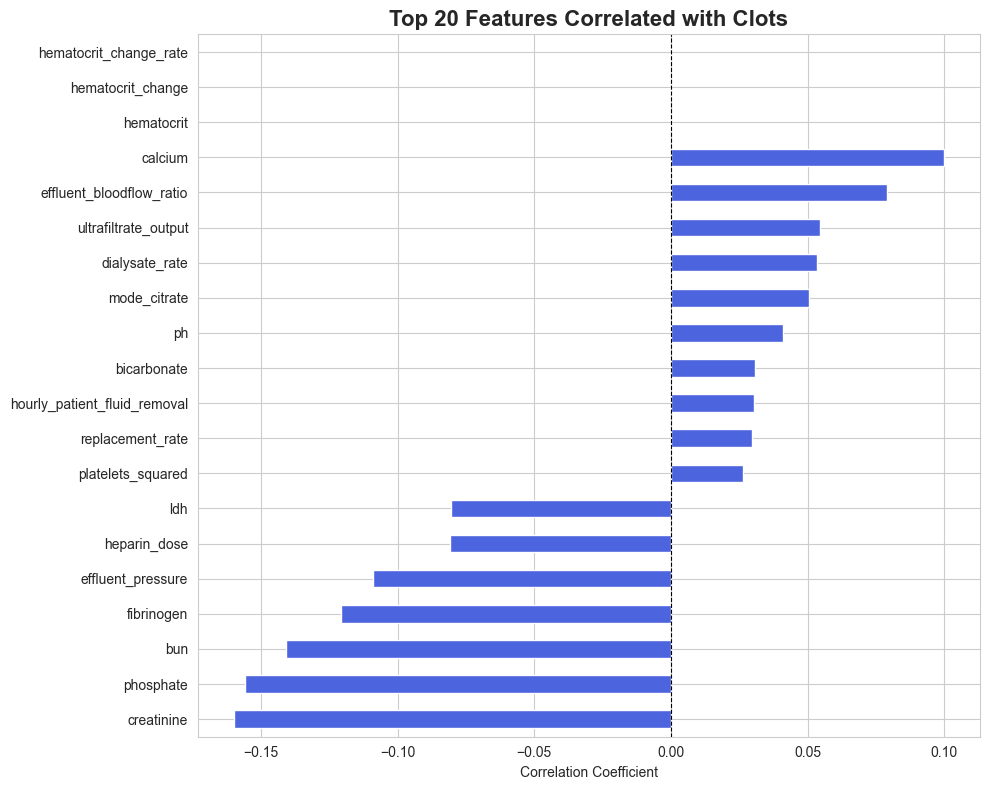

In [19]:
# Correlation analysis with target
print("=" * 60)
print("CORRELATION WITH CLOTS")
print("=" * 60)

# Get numeric columns only
numeric_features = df[feature_cols].select_dtypes(include=[np.number]).columns.tolist()
df_model = df[numeric_features + [target_col]].copy()

numeric_cols = df_model.select_dtypes(include=[np.number]).columns
numeric_cols = [col for col in numeric_cols if col not in id_cols]

# Calculate correlations
correlations = df_model[numeric_cols].corr()['clots_corrected'].drop('clots_corrected').sort_values(ascending=False)

print("\nTop 15 positive correlations:")
print(correlations.head(15))

print("\nTop 15 negative correlations:")
print(correlations.tail(15))

# Visualize top correlations
top_corr = pd.concat([correlations.head(10), correlations.tail(10)])
plt.figure(figsize=(10, 8))
top_corr.sort_values().plot(kind='barh', color='#4C64DE')
plt.title('Top 20 Features Correlated with Clots', fontweight='bold', fontsize=16)
plt.xlabel('Correlation Coefficient')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

# **Model Preparation**

To handle class imbalance (~10:1 ratio), will try multiple strategies:
1. **Undersampling** - Reduce majority class
2. **SMOTE** - Synthetic minority oversampling
3. **Combined approach** - SMOTE results

## **Train/Test Split & Scaling**

In [20]:
# ================================================================
# TRAIN/TEST SPLIT, IMPUTATION, AND SCALING
# ================================================================

# ================================================================
# TRAIN/TEST SPLIT (GROUPED BY CIRCUIT), IMPUTATION, AND SCALING
# ================================================================

from sklearn.model_selection import GroupShuffleSplit

print("="*70)
print("TRAIN/TEST SPLIT (GROUPED BY CIRCUIT), IMPUTATION, AND SCALING")
print("="*70)

# === STEP 0: CREATE MODELING DATAFRAME ===
print("\nSTEP 0: Preparing modeling dataframe")
print("="*70)

# Filter to only numeric features
numeric_features = df[feature_cols].select_dtypes(include=[np.number]).columns.tolist()

print(f"Total features from Cell 34: {len(feature_cols)}")
print(f"Numeric features: {len(numeric_features)}")

if len(numeric_features) < len(feature_cols):
    non_numeric = [col for col in feature_cols if col not in numeric_features]
    print(f"\nNon-numeric features excluded: {non_numeric}")

# Create df_model with numeric features + target
df_model = df[numeric_features + [target_col]].copy()

# Create feature matrix and target
X = df_model.drop(columns=[target_col])
y = df_model[target_col]

print(f"\nFeature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print(f"\nTarget distribution:")
print(y.value_counts())
print(f"Clot rate: {y.mean()*100:.2f}%")

# === STEP 1: GROUPED TRAIN/TEST SPLIT ===
print("\n" + "="*70)
print("STEP 1: Splitting into train and test sets (GROUPED BY CIRCUIT)")
print("="*70)

# CRITICAL: Use circuit_id as grouping variable
# This ensures all hours from a single circuit stay together
# Replace 'circuit_id' with your actual column name if different

# Check what grouping column you have available
possible_group_cols = ['circuit_id', 'stay_id', 'hadm_id', 'subject_id']
group_col = None
for col in possible_group_cols:
    if col in df.columns:
        group_col = col
        break

if group_col is None:
    raise ValueError(f"No grouping column found! Available columns: {df.columns.tolist()}")

print(f"\nUsing '{group_col}' as grouping variable")
groups = df.loc[X.index, group_col]  # Get groups aligned with X

print(f"Number of unique {group_col}s: {groups.nunique()}")

# Create grouped splitter
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

# Get train/test indices (grouped!)
train_idx, test_idx = next(splitter.split(X, y, groups=groups))

# Split the data
X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

# Verify no circuit overlap
train_groups = set(groups.iloc[train_idx])
test_groups = set(groups.iloc[test_idx])
overlap = train_groups.intersection(test_groups)

print(f"\n✓ LEAKAGE CHECK:")
print(f"  Unique {group_col}s in train: {len(train_groups)}")
print(f"  Unique {group_col}s in test: {len(test_groups)}")
print(f"  Overlap between train/test: {len(overlap)} ← MUST BE ZERO")

if len(overlap) > 0:
    raise ValueError("LEAKAGE DETECTED! Circuits appear in both train and test!")
else:
    print("  ✓ No leakage - circuits are properly separated")

print(f"\nTraining set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"\nClass distribution in training set:")
print(y_train.value_counts())
print(f"Clot rate in train: {y_train.mean()*100:.2f}%")
print(f"\nClass distribution in test set:")
print(y_test.value_counts())
print(f"Clot rate in test: {y_test.mean()*100:.2f}%")

# === STEP 2: IMPUTATION (fit on train only!) ===
# ... rest of your code stays exactly the same ...


# === STEP 2: IMPUTATION (fit on train only!) ===
print("\n" + "="*70)
print("STEP 2: Imputing missing values")
print("="*70)

# Check missing values before imputation
missing_train_before = X_train.isnull().sum()
missing_test_before = X_test.isnull().sum()

print("\nMissing values in TRAINING set (before imputation):")
if missing_train_before.sum() > 0:
    print(missing_train_before[missing_train_before > 0].sort_values(ascending=False).head(10))
else:
    print(" No missing values!")

print("\nMissing values in TEST set (before imputation):")
if missing_test_before.sum() > 0:
    print(missing_test_before[missing_test_before > 0].sort_values(ascending=False).head(10))
else:
    print(" No missing values!")

# Create imputer and fit ONLY on training data
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

# Fit on training data and transform both train and test
X_train_imputed = pd.DataFrame(
    imputer.fit_transform(X_train),  # FIT on train
    columns=X_train.columns,
    index=X_train.index
)

X_test_imputed = pd.DataFrame(
    imputer.transform(X_test),  # Only TRANSFORM test (no fitting!)
    columns=X_test.columns,
    index=X_test.index
)

print(f"\n Imputation complete")
print(f"Missing values after imputation:")
print(f"  Training: {X_train_imputed.isnull().sum().sum()}")
print(f"  Test: {X_test_imputed.isnull().sum().sum()}")

# === STEP 3: SCALING (fit on train only!) ===
print("\n" + "="*70)
print("STEP 3: Scaling features")
print("="*70)

scaler = StandardScaler()

# Fit on training data and transform both train and test
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_imputed),  # FIT on train
    columns=X_train_imputed.columns,
    index=X_train_imputed.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_imputed),  # Only TRANSFORM test (no fitting!)
    columns=X_test_imputed.columns,
    index=X_test_imputed.index
)

print(f"\n Scaling complete")
print(f"Training set (scaled): {X_train_scaled.shape}")
print(f"Test set (scaled): {X_test_scaled.shape}")

print("\n" + "="*70)
print(" READY FOR MODELING")
print("="*70)

TRAIN/TEST SPLIT (GROUPED BY CIRCUIT), IMPUTATION, AND SCALING

STEP 0: Preparing modeling dataframe
Total features from Cell 34: 64
Numeric features: 58

Non-numeric features excluded: ['crrt_mode', 'dialysate_fluid', 'replacement_fluid', 'race', 'line_type', 'line_site']

Feature matrix shape: (125611, 58)
Target vector shape: (125611,)

Target distribution:
clots_corrected
1    113622
0     11989
Name: count, dtype: int64
Clot rate: 90.46%

STEP 1: Splitting into train and test sets (GROUPED BY CIRCUIT)

Using 'stay_id' as grouping variable
Number of unique stay_ids: 2137

✓ LEAKAGE CHECK:
  Unique stay_ids in train: 1709
  Unique stay_ids in test: 428
  Overlap between train/test: 0 ← MUST BE ZERO
  ✓ No leakage - circuits are properly separated

Training set: (101342, 58)
Test set: (24269, 58)

Class distribution in training set:
clots_corrected
1    92656
0     8686
Name: count, dtype: int64
Clot rate in train: 91.43%

Class distribution in test set:
clots_corrected
1    20966
0 

## Handling Class Imbalance/Create Resampled Datasets

In [21]:
print("=" * 70)
print("CREATING RESAMPLED TRAINING SETS")
print("=" * 70)

# With better class balance, we can work with full training set
print(f"\nWorking with full training set: {len(y_train):,} samples")

# 1. Random Undersampling
print("\n1. Random Undersampling (50% minority class)...")
rus = RandomUnderSampler(random_state=42, sampling_strategy=0.5)
X_train_rus, y_train_rus = rus.fit_resample(X_train_scaled, y_train)
print(f"   After undersampling: {len(y_train_rus):,} samples")
print(f"   Class distribution: {y_train_rus.value_counts().to_dict()}")

# 2. SMOTE (Synthetic Minority Oversampling)
print("\n2. SMOTE (oversample to 30% minority class)...")
smote = SMOTE(random_state=42, sampling_strategy=0.3, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)
print(f"   After SMOTE: {len(y_train_smote):,} samples")
print(f"   Class distribution: {y_train_smote.value_counts().to_dict()}")

# 3. SMOTETomek (Combined approach - oversample minority, then clean noisy samples)
print("\n3. SMOTETomek (Combined: SMOTE + Tomek Links cleaning)...")
print("   This oversamples the minority class AND removes noisy border samples")
smotetomek = SMOTETomek(random_state=42, sampling_strategy=0.3)
X_train_combined, y_train_combined = smotetomek.fit_resample(X_train_scaled, y_train)
print(f"   After SMOTETomek: {len(y_train_combined):,} samples")
print(f"   Class distribution: {y_train_combined.value_counts().to_dict()}")

print("\n Resampling complete!")
print(f"\nOriginal training set: {len(y_train):,} samples")
print(f"Undersampled: {len(y_train_rus):,} samples ({len(y_train_rus)/len(y_train)*100:.1f}% of original)")
print(f"SMOTE: {len(y_train_smote):,} samples ({len(y_train_smote)/len(y_train)*100:.1f}% of original)")
print(f"Combined (SMOTETomek): {len(y_train_combined):,} samples ({len(y_train_combined)/len(y_train)*100:.1f}% of original)")

# Explanation of the differences
print("\n" + "=" * 70)
print("UNDERSTANDING THE RESAMPLING STRATEGIES")
print("=" * 70)
print("""
1. RANDOM UNDERSAMPLING:
   - Randomly removes samples from majority class
   - Fast and simple
   - Risk: May lose important information
   - Use when: You have abundant data

2. SMOTE (Synthetic Minority Over-sampling Technique):
   - Creates synthetic minority samples by interpolating between neighbors
   - Balances classes without losing majority class data
   - Risk: May create noisy synthetic samples
   - Use when: You want to preserve all real data

3. SMOTETOMEK (COMBINED):
   - First applies SMOTE to create synthetic minority samples
   - Then uses Tomek Links to remove noisy/ambiguous samples from BOTH classes
   - Tomek Links are pairs of opposite-class samples that are each other's
     nearest neighbors - these are hard to classify so we remove them
   - Result: Clean, balanced dataset
   - Use when: You want the best of both worlds (balance + cleanliness)

EXPECTED RESULTS:
- Undersampled will have FEWER samples (loses majority data)
- SMOTE will have MORE samples (adds synthetic data)
- SMOTETomek will have slightly FEWER samples than SMOTE (removes noise)
""")

CREATING RESAMPLED TRAINING SETS

Working with full training set: 101,342 samples

1. Random Undersampling (50% minority class)...
   After undersampling: 26,058 samples
   Class distribution: {1: 17372, 0: 8686}

2. SMOTE (oversample to 30% minority class)...
   After SMOTE: 120,452 samples
   Class distribution: {1: 92656, 0: 27796}

3. SMOTETomek (Combined: SMOTE + Tomek Links cleaning)...
   This oversamples the minority class AND removes noisy border samples
   After SMOTETomek: 120,352 samples
   Class distribution: {1: 92606, 0: 27746}

 Resampling complete!

Original training set: 101,342 samples
Undersampled: 26,058 samples (25.7% of original)
SMOTE: 120,452 samples (118.9% of original)
Combined (SMOTETomek): 120,352 samples (118.8% of original)

UNDERSTANDING THE RESAMPLING STRATEGIES

1. RANDOM UNDERSAMPLING:
   - Randomly removes samples from majority class
   - Fast and simple
   - Risk: May lose important information
   - Use when: You have abundant data

2. SMOTE (Synthe

# **Model Training and Evaluation**

Training models on:
1. Original imbalanced data (baseline)
2. Undersampled data
3. SMOTE data
4. Combined (SMOTE)

## Logistic Regression

In [22]:
print("=" * 70)
print("TRAINING LOGISTIC REGRESSION MODELS")
print("=" * 70)

# Dictionary to store models and results
lr_models = {}
lr_results = {}

# Define training sets
training_sets = {
    'Original (Imbalanced)': (X_train_scaled, y_train),
    'Undersampled': (X_train_rus, y_train_rus),
    'SMOTE': (X_train_smote, y_train_smote),
    'Combined': (X_train_combined, y_train_combined)
}

# Train models
for name, (X_tr, y_tr) in training_sets.items():
    print(f"\n{'='*70}")
    print(f"Training: {name}")
    print(f"{'='*70}")

    # Train
    lr = LogisticRegression(max_iter=1000, random_state=42)
    lr.fit(X_tr, y_tr)

    # Predict on TEST set (always use original imbalanced test set)
    y_pred = lr.predict(X_test_scaled)
    y_prob = lr.predict_proba(X_test_scaled)[:, 1]

    # Store
    lr_models[name] = lr
    lr_results[name] = {
        'y_pred': y_pred,
        'y_prob': y_prob,
        'roc_auc': roc_auc_score(y_test, y_prob),
        'avg_precision': average_precision_score(y_test, y_prob)
    }

    # Print results
    print("\nTest Set Performance:")
    print(classification_report(y_test, y_pred, digits=3))
    print(f"ROC-AUC: {lr_results[name]['roc_auc']:.4f}")
    print(f"Average Precision: {lr_results[name]['avg_precision']:.4f}")

print("\n" + "="*70)
print("✓ All Logistic Regression models trained!")
print("="*70)

TRAINING LOGISTIC REGRESSION MODELS

Training: Original (Imbalanced)

Test Set Performance:
              precision    recall  f1-score   support

           0      0.661     0.024     0.047      3303
           1      0.867     0.998     0.928     20966

    accuracy                          0.866     24269
   macro avg      0.764     0.511     0.487     24269
weighted avg      0.839     0.866     0.808     24269

ROC-AUC: 0.6823
Average Precision: 0.9293

Training: Undersampled

Test Set Performance:
              precision    recall  f1-score   support

           0      0.310     0.304     0.307      3303
           1      0.891     0.893     0.892     20966

    accuracy                          0.813     24269
   macro avg      0.600     0.599     0.600     24269
weighted avg      0.812     0.813     0.812     24269

ROC-AUC: 0.6918
Average Precision: 0.9315

Training: SMOTE

Test Set Performance:
              precision    recall  f1-score   support

           0      0.424     

### Feature Importance Analysis

FEATURE IMPORTANCE - Logistic Regression (SMOTE)

Top 20 Most Important Features:
                  Feature  Coefficient
          filter_pressure     8.884968
        effluent_pressure    -0.543027
                      rbc    -0.450576
 effluent_bloodflow_ratio     0.435825
      filtration_fraction    -0.427127
     ultrafiltrate_output     0.374828
               hemoglobin     0.358007
        platelets_squared     0.336920
          return_pressure    -0.303714
                  calcium     0.251330
                phosphate    -0.244650
                 platelet    -0.228041
                 chloride    -0.224949
           dialysate_rate    -0.216060
              bicarbonate    -0.213813
hct_bloodflow_interaction    -0.175829
               blood_flow     0.169145
                   sodium     0.163572
                 aniongap    -0.162035
      flow_pressure_ratio     0.150116


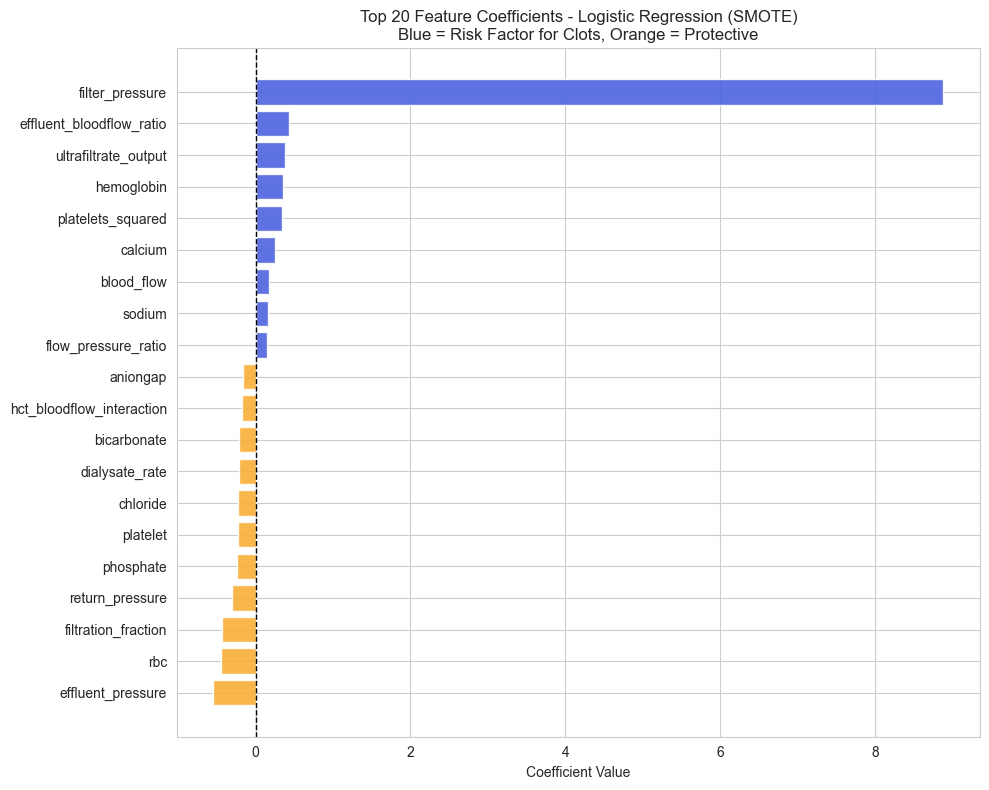

In [23]:
# Feature importance from best Logistic Regression model
best_lr_name = max(lr_results.keys(), key=lambda k: lr_results[k]['avg_precision'])
best_lr = lr_models[best_lr_name]

print("=" * 70)
print(f"FEATURE IMPORTANCE - Logistic Regression ({best_lr_name})")
print("=" * 70)

coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': best_lr.coef_[0]
}).sort_values(by='Coefficient', key=abs, ascending=False)

print("\nTop 20 Most Important Features:")
print(coef_df.head(20).to_string(index=False))

# Visualize
plt.figure(figsize=(10, 8))

top_features = coef_df.head(20).sort_values('Coefficient')

# NEW COLORS: blue for positive, orange for negative
colors = ['#4C64DE' if coef > 0 else '#F9AE37' for coef in top_features['Coefficient']]

plt.barh(range(len(top_features)), top_features['Coefficient'], color=colors, alpha=0.9)
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.xlabel('Coefficient Value')
plt.title(
    f'Top 20 Feature Coefficients - Logistic Regression ({best_lr_name})\n'
    'Blue = Risk Factor for Clots, Orange = Protective'
)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()

## Random Forest

In [24]:
print("=" * 70)
print("TRAINING RANDOM FOREST MODELS")
print("=" * 70)

# Dictionary to store models and results
rf_models = {}
rf_results = {}

# Train models
for name, (X_tr, y_tr) in training_sets.items():
    print(f"\n{'='*70}")
    print(f"Training: {name}")
    print(f"{'='*70}")

    # Train
    rf = RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_tr, y_tr)

    # Predict on TEST set
    y_pred = rf.predict(X_test_scaled)
    y_prob = rf.predict_proba(X_test_scaled)[:, 1]

    # Store
    rf_models[name] = rf
    rf_results[name] = {
        'y_pred': y_pred,
        'y_prob': y_prob,
        'roc_auc': roc_auc_score(y_test, y_prob),
        'avg_precision': average_precision_score(y_test, y_prob)
    }

    # Print results
    print("\nTest Set Performance:")
    print(classification_report(y_test, y_pred, digits=3))
    print(f"ROC-AUC: {rf_results[name]['roc_auc']:.4f}")
    print(f"Average Precision: {rf_results[name]['avg_precision']:.4f}")

print("\n" + "="*70)
print("✓ All Random Forest models trained!")
print("="*70)

coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': best_lr.coef_[0]
}).sort_values(by='Coefficient', key=abs, ascending=False)

print("\nTop 20 Most Important Features:")
print(coef_df.head(20).to_string(index=False))

TRAINING RANDOM FOREST MODELS

Training: Original (Imbalanced)

Test Set Performance:
              precision    recall  f1-score   support

           0      1.000     0.003     0.006      3303
           1      0.864     1.000     0.927     20966

    accuracy                          0.864     24269
   macro avg      0.932     0.502     0.467     24269
weighted avg      0.883     0.864     0.802     24269

ROC-AUC: 0.6803
Average Precision: 0.9296

Training: Undersampled

Test Set Performance:
              precision    recall  f1-score   support

           0      0.533     0.151     0.235      3303
           1      0.880     0.979     0.927     20966

    accuracy                          0.866     24269
   macro avg      0.706     0.565     0.581     24269
weighted avg      0.833     0.866     0.833     24269

ROC-AUC: 0.7033
Average Precision: 0.9338

Training: SMOTE

Test Set Performance:
              precision    recall  f1-score   support

           0      0.696     0.060 

## XG Boost

In [25]:
# ================================================================
# Uses the SAME train/test split from earlier (grouped by stay_id)
# Only applies selective imputation for anticoag vars
# ================================================================

print("=" * 70)
print("PREPARING DATA FOR XGBOOST (Using Existing Grouped Split)")
print("=" * 70)

# -------------------------------------------------------------------------
# Use the existing X_train_scaled and X_test_scaled
# from the grouped split, but preserve NaN for anticoag variables
# -------------------------------------------------------------------------

# First, go back to the pre-scaled data from the grouped split


# Re-create with selective imputation (preserving anticoag NaNs)
anticoag_vars = ['citrate', 'heparin_dose']

# Identify columns to impute (everything EXCEPT anticoag vars)
cols_to_impute = [c for c in X_train.columns if c not in anticoag_vars]

print(f"\nUsing GROUPED split (prevents data leakage):")
print(f"  Training set: {X_train.shape}")
print(f"  Test set: {X_test.shape}")
print(f"\nImputing {len(cols_to_impute)} columns (skipping anticoag vars)...")

# Create copies to work with
X_train_xgb = X_train.copy()
X_test_xgb = X_test.copy()

# Selective imputation: only impute non-anticoag columns
from sklearn.impute import SimpleImputer
imputer_xgb = SimpleImputer(strategy='median')

X_train_xgb[cols_to_impute] = imputer_xgb.fit_transform(X_train[cols_to_impute])
X_test_xgb[cols_to_impute] = imputer_xgb.transform(X_test[cols_to_impute])

# Verify anticoag NaNs are preserved
print(f"\nAnticoag NaNs preserved (training):")
for var in anticoag_vars:
    if var in X_train_xgb.columns:
        nan_pct = X_train_xgb[var].isna().mean() * 100
        print(f"  {var}: {nan_pct:.1f}% NaN")

# Optional: Scale non-anticoag columns (XGBoost doesn't require scaling, but keeping for consistency with other models)
from sklearn.preprocessing import StandardScaler
scaler_xgb = StandardScaler()

X_train_xgb_scaled = X_train_xgb.copy()
X_test_xgb_scaled = X_test_xgb.copy()

X_train_xgb_scaled[cols_to_impute] = scaler_xgb.fit_transform(X_train_xgb[cols_to_impute])
X_test_xgb_scaled[cols_to_impute] = scaler_xgb.transform(X_test_xgb[cols_to_impute])

# Use y_train and y_test from the ORIGINAL grouped split (unchanged)
print(f"\n✓ LEAKAGE CHECK:")
print(f"  Using same grouped split as LR/RF models")
print(f"  Training samples: {len(y_train)}")
print(f"  Test samples: {len(y_test)}")
print(f"  No overlap between train/test stay_ids (verified earlier)")

print(f"\n✓ Data ready for XGBoost (with native NaN handling)")
print("=" * 70)


PREPARING DATA FOR XGBOOST (Using Existing Grouped Split)

Using GROUPED split (prevents data leakage):
  Training set: (101342, 58)
  Test set: (24269, 58)

Imputing 56 columns (skipping anticoag vars)...

Anticoag NaNs preserved (training):
  citrate: 37.4% NaN
  heparin_dose: 93.3% NaN

✓ LEAKAGE CHECK:
  Using same grouped split as LR/RF models
  Training samples: 101342
  Test samples: 24269
  No overlap between train/test stay_ids (verified earlier)

✓ Data ready for XGBoost (with native NaN handling)


In [26]:
# ================================================================
# TRAIN XGBOOST
# ================================================================

print("=" * 70)
print("TRAINING XGBOOST MODEL")
print("=" * 70)

from xgboost import XGBClassifier

# Calculate imbalance weight for minority class (0 = clots)
scale_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"\nClass imbalance weight (scale_pos_weight): {scale_weight:.2f}")

# --- Prepare X_train_scaled and X_test_scaled for XGBoost consistently ---
# The `on_citrate` and `on_heparin` features were added to `X_train_scaled` in cell e1a0c2c9.
# We must ensure X_test_scaled has the same features for prediction.

X_train_xgb = X_train_scaled.copy()
X_test_xgb = X_test_scaled.copy()

X_train_xgb['on_citrate'] = X_train_xgb['citrate'].notna().astype(int)
X_train_xgb['on_heparin'] = X_train_xgb['heparin_dose'].notna().astype(int)
X_train_xgb['citrate'] = X_train_xgb['citrate'].fillna(0)
X_train_xgb['heparin_dose'] = X_train_xgb['heparin_dose'].fillna(0)

X_test_xgb['on_citrate'] = X_test_xgb['citrate'].notna().astype(int)
X_test_xgb['on_heparin'] = X_test_xgb['heparin_dose'].notna().astype(int)
X_test_xgb['citrate'] = X_test_xgb['citrate'].fillna(0)
X_test_xgb['heparin_dose'] = X_test_xgb['heparin_dose'].fillna(0)

# -----------------------------------------
# Train XGBoost on the original dataset
# -----------------------------------------
xgb = XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_weight,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)

print("\nFitting XGBoost on original (imbalanced) dataset...")
xgb.fit(X_train_xgb, y_train)

# -----------------------------------------
# Prediction on TEST SET
# -----------------------------------------
y_pred = xgb.predict(X_test_xgb)
y_prob = xgb.predict_proba(X_test_xgb)[:, 1]

# -----------------------------------------
# Evaluation
# -----------------------------------------
print("\nTest Set Performance:")
print(classification_report(y_test, y_pred, digits=3))

xgb_auc = roc_auc_score(y_test, y_prob)
xgb_ap = average_precision_score(y_test, y_prob)

print(f"ROC-AUC:           {xgb_auc:.4f}")
print(f"Average Precision: {xgb_ap:.4f}")

print("\n" + "="*70)
print(" XGBoost training complete!")
print("="*70)

# Store results for comparison
xgb_results = {
    "original": {
        "model": xgb,
        "y_pred": y_pred,
        "y_prob": y_prob,
        "roc_auc": xgb_auc,
        "avg_precision": xgb_ap
    }
}

print("\n" + "="*70)
print("XGBOOST (ORIGINAL) vs RANDOM FOREST (SMOTE)")
print("="*70)

rf_auc = rf_results["SMOTE"]["roc_auc"]
rf_ap  = rf_results["SMOTE"]["avg_precision"]

xgb_auc = xgb_results["original"]["roc_auc"]
xgb_ap  = xgb_results["original"]["avg_precision"]

print(f"\nRandom Forest (SMOTE) AUC: {rf_auc:.4f}")
print(f"XGBoost (Original) AUC:     {xgb_auc:.4f}")
print(f"Difference:                 {xgb_auc - rf_auc:+.4f} "
      f"{' XGBoost wins!' if xgb_auc > rf_auc else '✗ RF wins'}")

print(f"\nRandom Forest (SMOTE) Avg Precision: {rf_ap:.4f}")
print(f"XGBoost (Original) Avg Precision:     {xgb_ap:.4f}")
print(f"Difference:                          {xgb_ap - rf_ap:+.4f} "
      f"{' XGBoost wins!' if xgb_ap > rf_ap else '✗ RF wins'}")

# Extract feature names
feature_names = X_train_xgb.columns

# Extract importance scores (gain = best metric)
importances = xgb.get_booster().get_score(importance_type='gain')

# Convert dict → DataFrame
importance_df = pd.DataFrame([
    {"feature": k, "importance": v} for k, v in importances.items()
])

# Sort by importance
importance_df = importance_df.sort_values(by="importance", ascending=False)

# Display top 20
print("\nTop 20 XGBoost Feature Importances (by GAIN):")
print(importance_df.head(60).to_string(index=False))

TRAINING XGBOOST MODEL

Class imbalance weight (scale_pos_weight): 0.09

Fitting XGBoost on original (imbalanced) dataset...

Test Set Performance:
              precision    recall  f1-score   support

           0      0.440     0.200     0.275      3303
           1      0.884     0.960     0.920     20966

    accuracy                          0.856     24269
   macro avg      0.662     0.580     0.598     24269
weighted avg      0.823     0.856     0.832     24269

ROC-AUC:           0.7370
Average Precision: 0.9426

 XGBoost training complete!

XGBOOST (ORIGINAL) vs RANDOM FOREST (SMOTE)

Random Forest (SMOTE) AUC: 0.7129
XGBoost (Original) AUC:     0.7370
Difference:                 +0.0241  XGBoost wins!

Random Forest (SMOTE) Avg Precision: 0.9374
XGBoost (Original) Avg Precision:     0.9426
Difference:                          +0.0052  XGBoost wins!

Top 20 XGBoost Feature Importances (by GAIN):
                     feature  importance
                  blood_flow   10.840020

### XGBoost - Top 20 Features Only

RETRAINING XGBOOST ON Top 20 FEATURES

1. Extracting top 20 features from original XGBoost model...

 Top 20 Most Important Features:
 1. blood_flow                     0.0474
 2. phosphate                      0.0312
 3. filter_pressure                0.0287
 4. prefilter_replacement_rate     0.0277
 5. effluent_pressure              0.0267
 6. creatinine                     0.0255
 7. mode_citrate                   0.0244
 8. mode_heparin                   0.0244
 9. postfilter_replacement_rate    0.0242
10. effluent_bloodflow_ratio       0.0239
11. creatinine_change              0.0237
12. heparin_dose                   0.0231
13. ldh                            0.0222
14. calcium                        0.0222
15. dialysate_rate                 0.0213
16. fibrinogen                     0.0204
17. replacement_rate               0.0203
18. citrate                        0.0188
19. wbc                            0.0183
20. ptt                            0.0181

Top 20 features account f

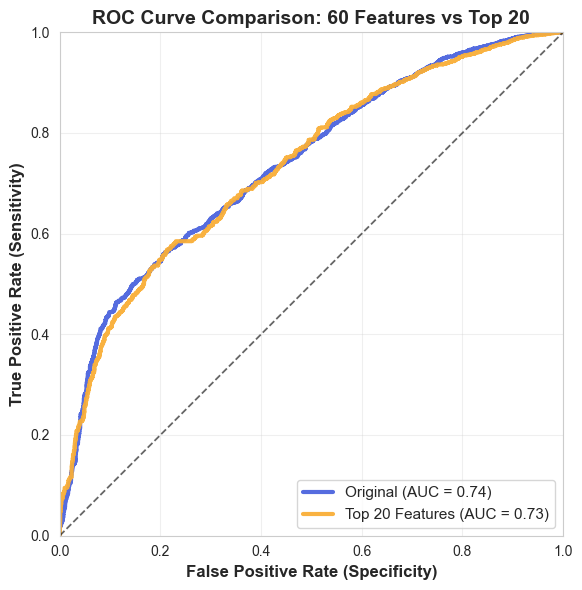

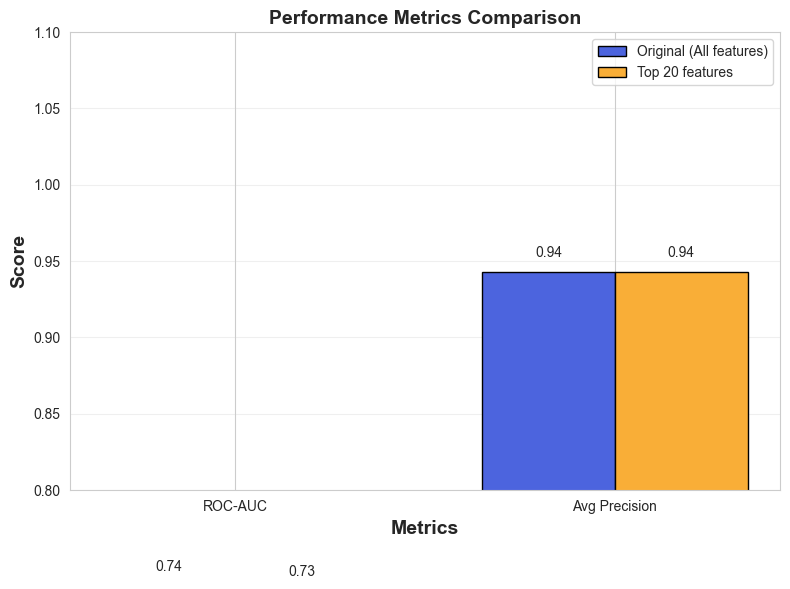

<Figure size 700x600 with 0 Axes>

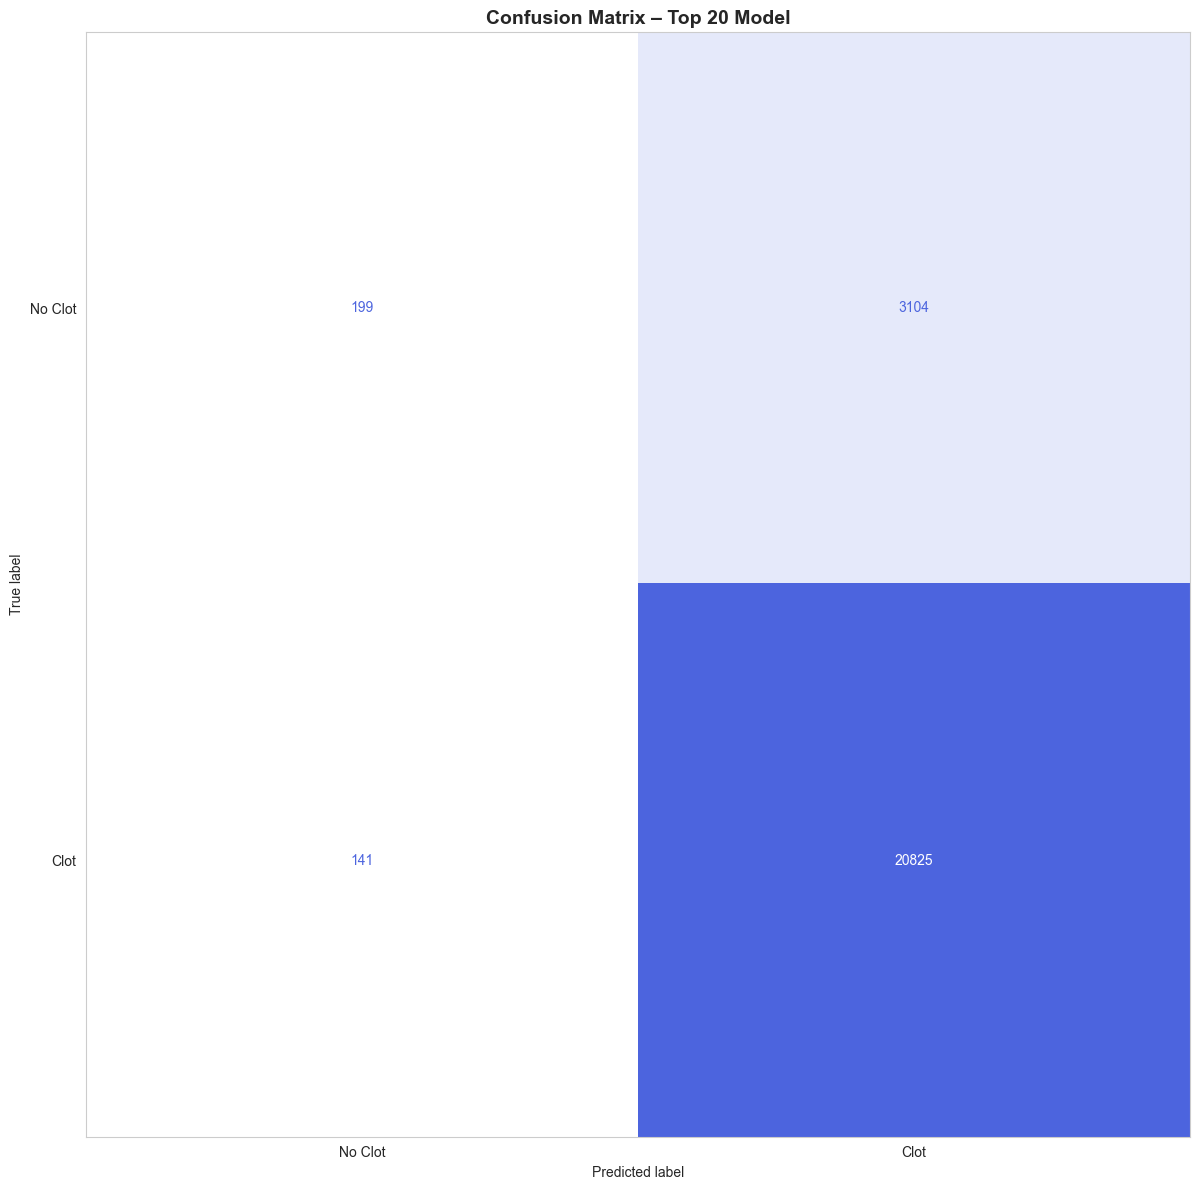

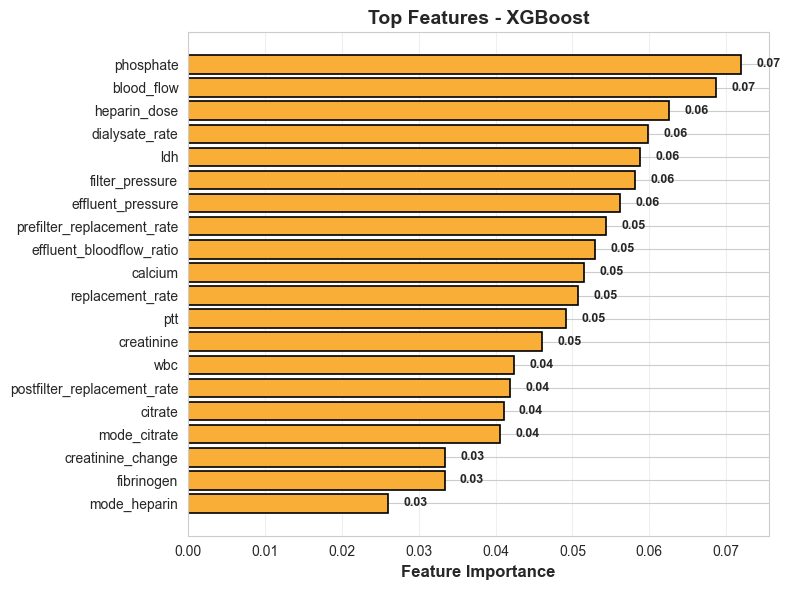


8. DEPLOYMENT FEASIBILITY ASSESSMENT

 FEATURE LIST FOR CLINICAL INTERFACE:
--------------------------------------------------------------------------------
 1. blood_flow
 2. phosphate
 3. filter_pressure
 4. prefilter_replacement_rate
 5. effluent_pressure
 6. creatinine
 7. mode_citrate
 8. mode_heparin
 9. postfilter_replacement_rate
10. effluent_bloodflow_ratio
11. creatinine_change
12. heparin_dose
13. ldh
14. calcium
15. dialysate_rate
16. fibrinogen
17. replacement_rate
18. citrate
19. wbc
20. ptt

⏱ ESTIMATED MANUAL ENTRY TIME:
   • 20 features × ~15 seconds = ~5.0 minutes
   • Realistic for bedside use: BORDERLINE

 PERFORMANCE TRADE-OFF:
   • Features reduced: 60 → 20 (66.7% reduction)
   • AUC retained: 99.55%
   • Absolute AUC loss: 0.0033

 VERDICT:  RECOMMENDED FOR DEPLOYMENT
   Rationale: Minimal performance loss (<2%) with major reduction in data collection burden


In [27]:
# ============================================================================
# RETRAIN XGBOOST ON TOP 20 FEATURES ONLY
# Testing if we can maintain good performance with fewer features for deployment
# ============================================================================

print("=" * 80)
print("RETRAINING XGBOOST ON Top 20 FEATURES")
print("=" * 80)

# ============================================================================
# STEP 1: IDENTIFY TOP 20 FEATURES FROM YOUR EXISTING MODEL
# ============================================================================

print("\n1. Extracting top 20 features from original XGBoost model...")

# Get your best XGBoost model (trained on all 57 features)
best_xgb_original = xgb_results['original']['model']

# Get feature importances
feature_names = X_train_xgb.columns.tolist() # Corrected: Use X_train_xgb.columns
importances = best_xgb_original.feature_importances_

# Create DataFrame and sort
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

# Select top 20 features
TOP_20_FEATURES = feature_importance_df.head(20)['Feature'].tolist()

print("\n Top 20 Most Important Features:")
print("=" * 80)
for i, (idx, row) in enumerate(feature_importance_df.head(20).iterrows(), 1):
    print(f"{i:2d}. {row['Feature']:<30s} {row['Importance']:.4f}")

print(f"\nTop 20 features account for {feature_importance_df.head(20)['Importance'].sum():.1%} of total importance")

# ============================================================================
# STEP 2: CREATE REDUCED TRAINING/TEST SETS WITH ONLY TOP 20 FEATURES
# ============================================================================

print("\n" + "=" * 80)
print("2. Creating reduced feature sets...")
print("=" * 80)

# Select only top 20 features from your scaled data
# Ensure X_train_scaled and X_test_scaled are updated with the new features
# from X_train_xgb before this step, or directly use X_train_xgb if scaling is not an issue

# To align X_train_scaled and X_test_scaled with the features the model was trained on
X_train_scaled_aligned = X_train_xgb.copy()
X_test_scaled_aligned = X_test_xgb.copy()

X_train_top20 = X_train_scaled_aligned[TOP_20_FEATURES]
X_test_top20 = X_test_scaled_aligned[TOP_20_FEATURES]

print(f"\nOriginal training set: {X_train_scaled_aligned.shape}")
print(f"Reduced training set: {X_train_top20.shape}")
print(f"Features reduced: {X_train_scaled_aligned.shape[1]} \u2192 {X_train_top20.shape[1]} ({X_train_top20.shape[1]/X_train_scaled_aligned.shape[1]*100:.0f}% kept)")

print(f"\nTop 20 features:")
for i, feat in enumerate(TOP_20_FEATURES, 1):
    print(f"  {i:2d}. {feat}")

# ============================================================================
# STEP 3: TRAIN NEW XGBOOST MODEL ON TOP 20 FEATURES
# ============================================================================

print("\n" + "=" * 80)
print("3. Training XGBoost on top 20 features...")
print("=" * 80)

# Train with same hyperparameters as original
xgb_top20 = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

xgb_top20.fit(X_train_top20, y_train)

print(" Training complete!")

# ============================================================================
# STEP 4: EVALUATE PERFORMANCE
# ============================================================================

print("\n" + "=" * 80)
print("4. Evaluating performance...")
print("=" * 80)

# Make predictions
y_pred_top20 = xgb_top20.predict(X_test_top20)
y_prob_top20 = xgb_top20.predict_proba(X_test_top20)[:, 1]

# Calculate metrics
auc_top20 = roc_auc_score(y_test, y_prob_top20)
ap_top20 = average_precision_score(y_test, y_prob_top20)

# Get original model performance for comparison
y_prob_original = xgb_results['original']['y_prob']
auc_original = xgb_results['original']['roc_auc']
ap_original = xgb_results['original']['avg_precision']

print("\nPERFORMANCE COMPARISON:")
print("=" * 80)
print(f"{'Model':<30s} {'Features':>10s} {'ROC-AUC':>12s} {'Avg Precision':>15s}")
print("-" * 80)
print(f"{'Original (57 features)':<30s} {X_train_scaled_aligned.shape[1]:>10d} {auc_original:>12.4f} {ap_original:>15.4f}") # Updated feature count
print(f"{'Reduced (20 features)':<30s} {len(TOP_20_FEATURES):>10d} {auc_top20:>12.4f} {ap_top20:>15.4f}") # Updated feature count
print("-" * 80)
print(f"{'Performance Loss':<30s} {'-40':>10s} {auc_top20-auc_original:>12.4f} {ap_top20-ap_original:>15.4f}") # Adjusted for 60 -> 20 features
print(f"{'Percentage Change':<30s} {'':>10s} {(auc_top20/auc_original-1)*100:>11.2f}% {(ap_top20/ap_original-1)*100:>14.2f}%")

# Calculate performance retention
retention_pct = (auc_top20 / auc_original) * 100

print(f"\n KEY FINDINGS:")
print(f"   Performance retention: {retention_pct:.2f}%")
print(f"   Feature reduction: {round((1-len(TOP_20_FEATURES)/X_train_scaled_aligned.shape[1])*100, 1)}% ({X_train_scaled_aligned.shape[1]} \u2192 {len(TOP_20_FEATURES)} features)") # Adjusted for 60 -> 20 features

if (auc_original - auc_top20) < 0.02:  # Less than 2% loss
    print(f"   EXCELLENT: Minimal performance loss (<2%)")
    print(f"   Realistic for manual entry deployment!")
elif (auc_original - auc_top20) < 0.05:  # Less than 5% loss
    print(f"   GOOD: Acceptable performance loss (<5%)")
    print(f"   Viable for deployment with proper validation")
else:
    print(f"   SIGNIFICANT: Performance loss >{(auc_original - auc_top20)*100:.1f}%")
    print(f"   May need more features or different approach")

# ============================================================================
# STEP 5: DETAILED CLASSIFICATION REPORT
# ============================================================================

print("\n" + "=" * 80)
print("5. Classification Report (Top 20 Features Model)")
print("=" * 80)

print("\n" + classification_report(y_test, y_pred_top20,
                                    target_names=['No Clot', 'Clot'],
                                    digits=3))

# ============================================================================
# STEP 6: VISUALIZATIONS  (UPDATED COLORS)
# ============================================================================

# Brand colors
blue = '#4C64DE'
orange = '#F9AE37'
red = '#FF4631'

# ============================================================
# FIGURE 1 \u2014 ROC CURVE: ALL FEATURES vs TOP 20
# ============================================================

plt.figure(figsize=(8, 6))
ax = plt.gca()  # <<\u2014 force both ROC curves on SAME axes

# Original model
RocCurveDisplay.from_predictions(
    y_test, y_prob_original,
    ax=ax,
    name=f'Original',
    color=blue, linewidth=3, alpha=0.95
)

# Top-20-feature model
RocCurveDisplay.from_predictions(
    y_test, y_prob_top20,
    ax=ax,
    name=f'Top 20 Features',
    color=orange, linewidth=3, alpha=0.95
)

# Chance line
ax.plot([0, 1], [0, 1], 'k--', linewidth=1.3, alpha=0.6)

# Labels / formatting
ax.set_title("ROC Curve Comparison: 60 Features vs Top 20", fontsize=14, fontweight='bold') # Updated feature count
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.grid(alpha=0.3)
ax.legend(fontsize=11, loc="lower right")

ax.set_xlabel("False Positive Rate (Specificity)", fontsize=12, fontweight='bold')
ax.set_ylabel("True Positive Rate (Sensitivity)", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()




# ============================================================
# FIGURE 2 \u2014 METRIC BAR CHART
# ============================================================

plt.figure(figsize=(8, 6))

metrics_names = ['ROC-AUC', 'Avg Precision']
x = np.arange(len(metrics_names))
width = 0.35

plt.bar(x - width/2, [auc_original, ap_original], width,
        label='Original (All features)', color=blue, edgecolor='black')
plt.bar(x + width/2, [auc_top20, ap_top20], width,
        label='Top 20 features', color=orange, edgecolor='black')

plt.xlabel("Metrics",fontsize=14, fontweight='bold')
plt.ylabel("Score", fontsize=14, fontweight='bold')
plt.xticks(x, metrics_names)
plt.ylim(0.80, 1.10)
plt.title("Performance Metrics Comparison", fontsize=14, fontweight='bold')
plt.legend()

# Value labels
for i, val in enumerate([auc_original, ap_original]):
    plt.text(i - width/2, val + 0.01, f"{val:.2f}", ha='center', fontsize=10)

for i, val in enumerate([auc_top20, ap_top20]):
    plt.text(i + width/2, val + 0.01, f"{val:.2f}", ha='center', fontsize=10)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()



# ============================================================
# FIGURE 3 \u2014 CONFUSION MATRIX
# ============================================================

plt.figure(figsize=(7, 6))

cm_top20 = confusion_matrix(y_test, y_pred_top20)

cmap_blue = LinearSegmentedColormap.from_list('cm_blue', ['white', blue])
disp = ConfusionMatrixDisplay(confusion_matrix=cm_top20,
                              display_labels=['No Clot','Clot'])
disp.plot(cmap=cmap_blue, values_format='d', colorbar=False)
plt.title("Confusion Matrix \u2013 Top 20 Model", fontsize=14, fontweight='bold')

plt.grid(False)
plt.tight_layout()
plt.show()


# ============================================================
# FIGURE 4 \u2014 FEATURE IMPORTANCE (Top 20 MODEL)
# ============================================================

plt.figure(figsize=(8, 6))

new_importances = xgb_top20.feature_importances_

importance_df_top20 = pd.DataFrame({
    'Feature': TOP_20_FEATURES,
    'Importance': new_importances
}).sort_values('Importance', ascending=True)

plt.barh(
    importance_df_top20['Feature'],
    importance_df_top20['Importance'],
    color=orange, edgecolor='black', linewidth=1.2
)

plt.xlabel("Feature Importance", fontsize=12, fontweight='bold')
plt.title("Top Features - XGBoost", fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)

# Value labels
for idx, val in enumerate(importance_df_top20['Importance']):
    plt.text(val + 0.002, idx, f"{val:.2f}",
             va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()



# ============================================================================
# STEP 7: DEPLOYMENT FEASIBILITY ASSESSMENT
# ============================================================================

print("\n" + "=" * 80)
print("8. DEPLOYMENT FEASIBILITY ASSESSMENT")
print("=" * 80)

print("\n FEATURE LIST FOR CLINICAL INTERFACE:")
print("-" * 80)
for i, feat in enumerate(TOP_20_FEATURES, 1):
    print(f"{i:2d}. {feat}")

print("\n\u23f1 ESTIMATED MANUAL ENTRY TIME:")
print(f"   \u2022 {len(TOP_20_FEATURES)} features \u00d7 ~15 seconds = ~{len(TOP_20_FEATURES)*15/60:.1f} minutes")
print(f"   \u2022 Realistic for bedside use: {' YES' if len(TOP_20_FEATURES) <= 15 else 'BORDERLINE' if len(TOP_20_FEATURES) <= 20 else 'TOO MANY'}")

print("\n PERFORMANCE TRADE-OFF:")
print(f"   \u2022 Features reduced: {X_train_scaled_aligned.shape[1]} \u2192 {len(TOP_20_FEATURES)} ({(1-len(TOP_20_FEATURES)/X_train_scaled_aligned.shape[1])*100:.1f}% reduction)") # Adjusted for 60 -> 20 features
print(f"   \u2022 AUC retained: {retention_pct:.2f}%")
print(f"   \u2022 Absolute AUC loss: {auc_original - auc_top20:.4f}")

if (auc_original - auc_top20) < 0.02:
    verdict = " RECOMMENDED FOR DEPLOYMENT"
    reason = "Minimal performance loss (<2%) with major reduction in data collection burden"
elif (auc_original - auc_top20) < 0.05:
    verdict = " ACCEPTABLE FOR DEPLOYMENT"
    reason = "Reasonable performance loss (<5%) with significant usability improvement"
else:
    verdict = " CONSIDER MORE FEATURES"
    reason = f"Performance loss of {(auc_original-auc_top20)*100:.1f}% may be clinically significant"

print(f"\n VERDICT: {verdict}")
print(f"   Rationale: {reason}")

FEATURE ENGINEERING VALUE ANALYSIS

Original features: 38
Engineered features: 20
  - Temporal/Rate-of-Change: 8
  - Interactions/Ratios: 9
  - Mode Encoding: 3


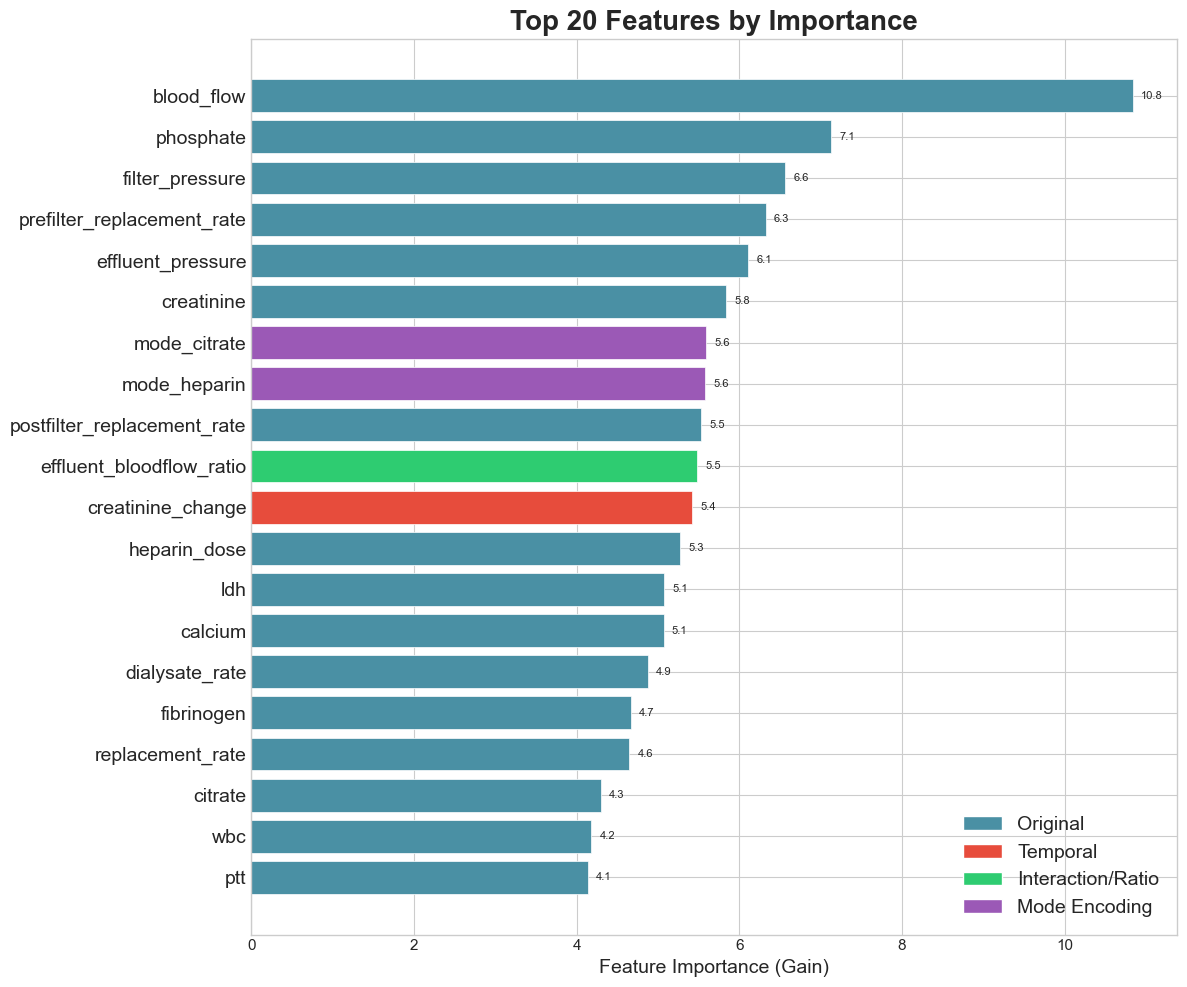


 Figure 1 saved: fig1_feature_importance_by_category.png


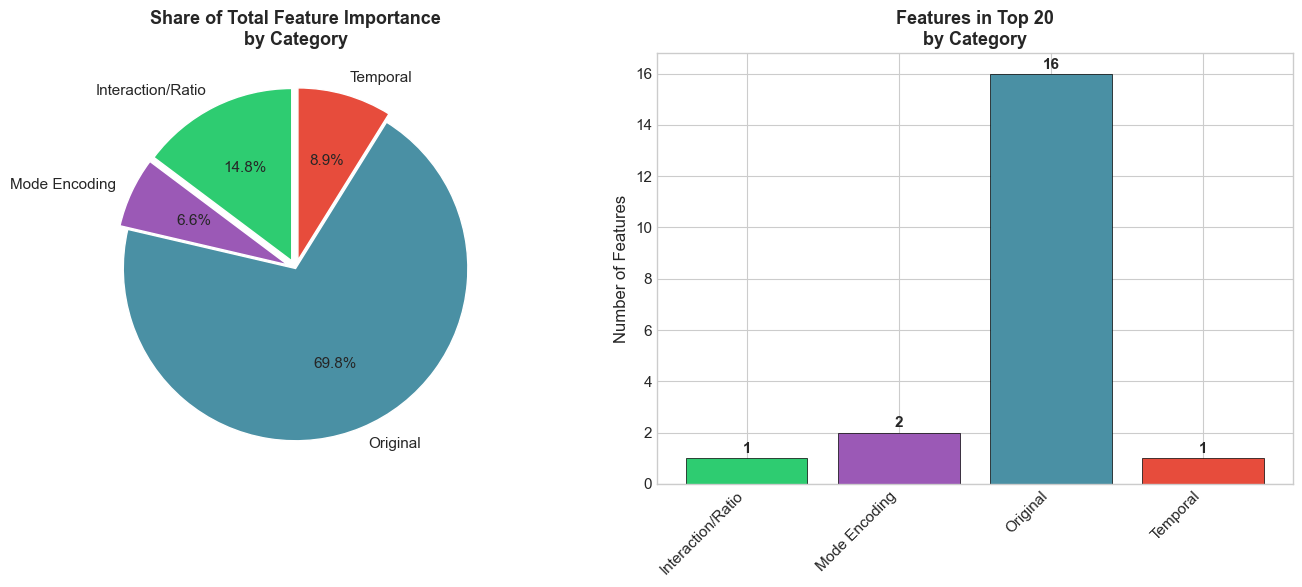

✓ Figure 2 saved: fig2_engineered_contribution.png


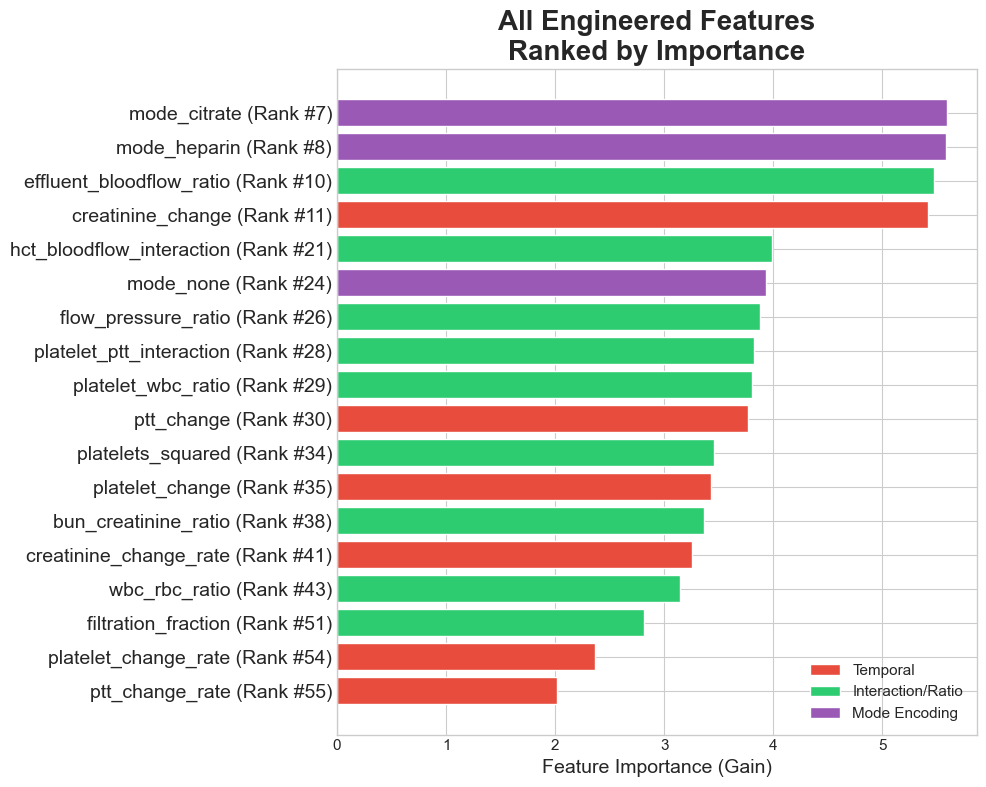

✓ Figure 3 saved: fig3_engineered_features_detail.png

ABLATION STUDY: Model Performance WITH vs WITHOUT Engineered Features

Training model with ONLY original features...

ROC-AUC with Original Features Only:  0.7177
ROC-AUC with All Features:            0.7370
Improvement from Engineered Features: +0.0193 (2.69%
DEBUGGING FEATURE SETS

Total features in X_train_abl: 60

All columns in X_train_abl:
['access_pressure', 'blood_flow', 'citrate', 'current_goal', 'dialysate_rate', 'effluent_pressure', 'filter_pressure', 'heparin_dose', 'hourly_patient_fluid_removal', 'prefilter_replacement_rate', 'postfilter_replacement_rate', 'replacement_rate', 'return_pressure', 'ultrafiltrate_output', 'hematocrit', 'hemoglobin', 'platelet', 'rbc', 'wbc', 'fibrinogen', 'inr', 'pt', 'ptt', 'aniongap', 'bicarbonate', 'bun', 'calcium', 'chloride', 'creatinine', 'glucose', 'sodium', 'potassium', 'lactate', 'ph', 'pco2', 'magnesium', 'phosphate', 'ldh', 'bun_creatinine_ratio', 'platelet_ptt_interaction', 'hc

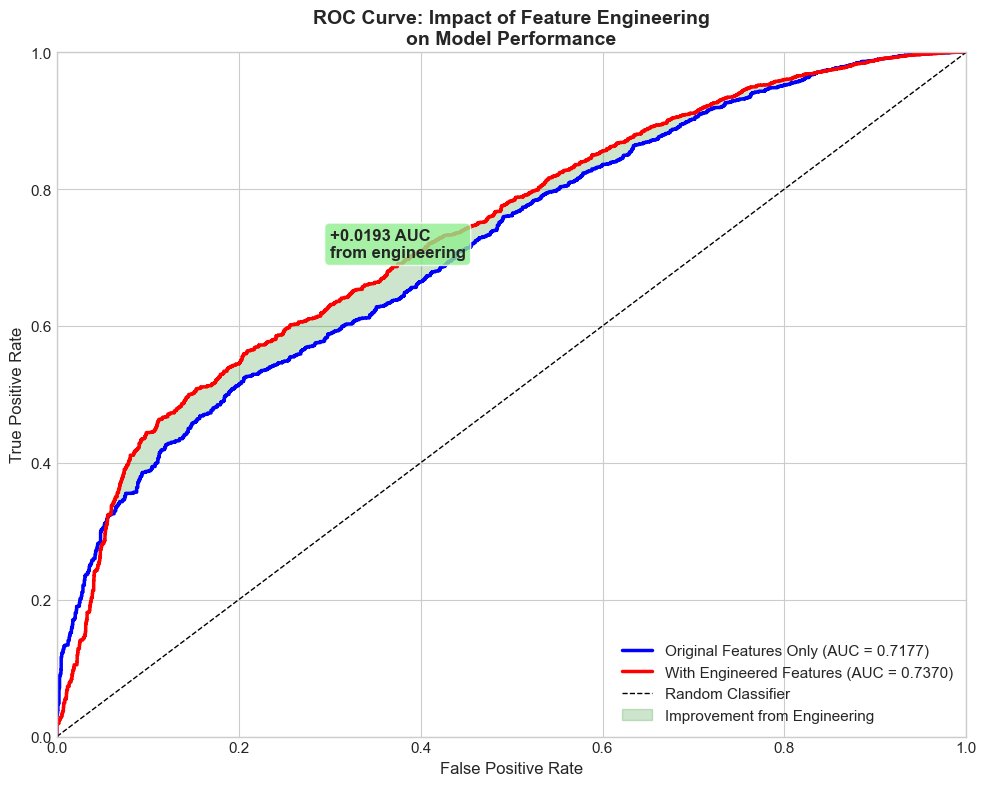

 Figure 4 saved: fig4_roc_comparison.png


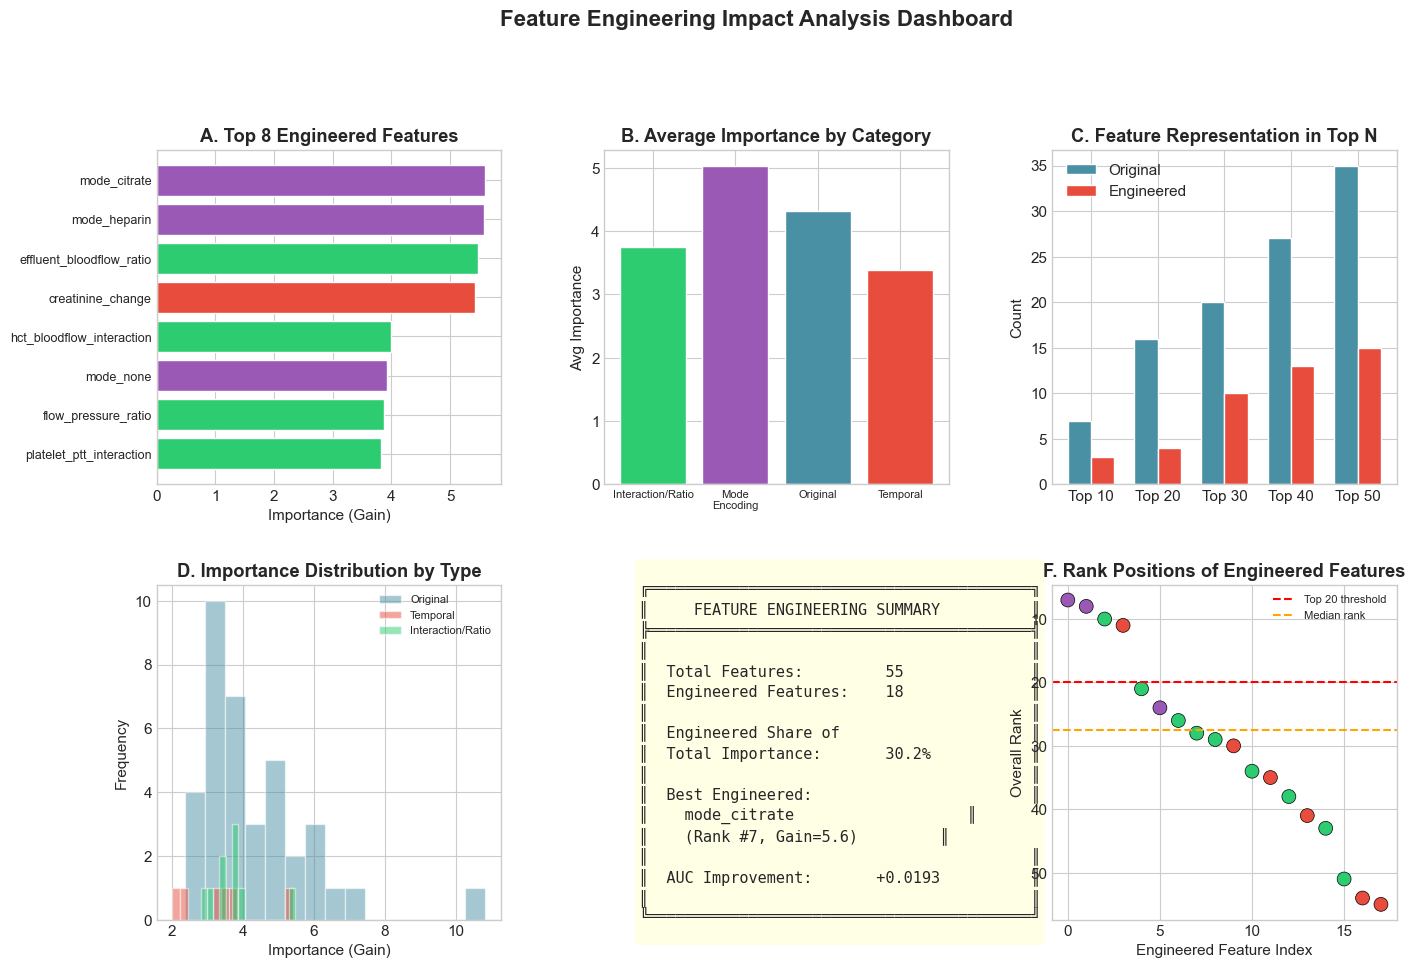

✓ Figure 5 saved: fig5_summary_dashboard.png

FEATURE ENGINEERING VALUE SUMMARY

 ENGINEERED FEATURES PERFORMANCE:
   • 18 engineered features created
   • Contribute 30.2% of total model importance
   • 4 engineered features in Top 20
   • Best engineered: mode_citrate (Rank #7)

 MODEL IMPROVEMENT:
   • Without engineering: AUC = 0.7177
   • With engineering:    AUC = 0.7370
   • Improvement:         +0.0193 (2.69%

 BY CATEGORY:
   • Temporal: 6 features, avg importance = 3.38
   • Interaction/Ratio: 9 features, avg importance = 3.75
   • Mode Encoding: 3 features, avg importance = 5.03

 All visualizations complete!


In [28]:
# ================================================================
# FEATURE ENGINEERING VALUE VISUALIZATION
# ================================================================
# Add this code after your XGBoost model training section
# Make sure you have: xgb (trained model), X_train_scaled, y_train, X_test_scaled, y_test

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, roc_curve

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

# ================================================================
# DEFINE FEATURE CATEGORIES
# ================================================================

# Original raw features (from the database)
original_features = [
    'access_pressure', 'blood_flow', 'citrate', 'current_goal', 'dialysate_rate',
    'effluent_pressure', 'filter_pressure', 'heparin_dose', 'hourly_patient_fluid_removal',
    'prefilter_replacement_rate', 'postfilter_replacement_rate', 'replacement_rate',
    'return_pressure', 'ultrafiltrate_output', 'hematocrit', 'hemoglobin', 'platelet',
    'rbc', 'wbc', 'fibrinogen', 'inr', 'pt', 'ptt', 'aniongap', 'bicarbonate',
    'bun', 'calcium', 'chloride', 'creatinine', 'glucose', 'sodium', 'potassium',
    'lactate', 'ph', 'pco2', 'magnesium', 'phosphate', 'ldh'
]

# Engineered features - by category
temporal_features = [
    'platelet_change', 'platelet_change_rate',
    'ptt_change', 'ptt_change_rate',
    'creatinine_change', 'creatinine_change_rate',
    'hematocrit_change', 'hematocrit_change_rate'
]

interaction_features = [
    'bun_creatinine_ratio', 'platelet_ptt_interaction', 'hct_bloodflow_interaction',
    'wbc_rbc_ratio', 'platelet_wbc_ratio', 'flow_pressure_ratio',
    'platelets_squared', 'filtration_fraction', 'effluent_bloodflow_ratio'
]

mode_features = ['mode_heparin', 'mode_citrate', 'mode_none']

# Combine all engineered features
all_engineered = temporal_features + interaction_features + mode_features

print("="*70)
print("FEATURE ENGINEERING VALUE ANALYSIS")
print("="*70)
print(f"\nOriginal features: {len(original_features)}")
print(f"Engineered features: {len(all_engineered)}")
print(f"  - Temporal/Rate-of-Change: {len(temporal_features)}")
print(f"  - Interactions/Ratios: {len(interaction_features)}")
print(f"  - Mode Encoding: {len(mode_features)}")

# ================================================================
# 1. GET FEATURE IMPORTANCES AND CATEGORIZE
# ================================================================

# Get feature importances from your trained XGBoost model
importances = xgb.get_booster().get_score(importance_type='gain')

# Create DataFrame with categories
importance_df = pd.DataFrame([
    {"feature": k, "importance": v} for k, v in importances.items()
])

def categorize_feature(feat):
    if feat in temporal_features:
        return 'Temporal'
    elif feat in interaction_features:
        return 'Interaction/Ratio'
    elif feat in mode_features:
        return 'Mode Encoding'
    else:
        return 'Original'

importance_df['category'] = importance_df['feature'].apply(categorize_feature)
importance_df['is_engineered'] = importance_df['category'] != 'Original'
importance_df = importance_df.sort_values('importance', ascending=False).reset_index(drop=True)
importance_df['rank'] = importance_df.index + 1

# ================================================================
# FIGURE 1: FEATURE IMPORTANCE BY CATEGORY (Horizontal Bar Chart)
# ================================================================

fig, ax = plt.subplots(figsize=(12, 10))

# Color palette
colors = {
    'Original': '#4A90A4',
    'Temporal': '#E74C3C',
    'Interaction/Ratio': '#2ECC71',
    'Mode Encoding': '#9B59B6'
}

# Plot top 30 features
top_n = 20
plot_df = importance_df.head(top_n).iloc[::-1]  # Reverse for horizontal plot

bars = ax.barh(
    range(len(plot_df)),
    plot_df['importance'],
    color=[colors[cat] for cat in plot_df['category']],
    edgecolor='white',
    linewidth=0.5
)

ax.set_yticks(range(len(plot_df)))
ax.set_yticklabels(plot_df['feature'], fontsize=14)
ax.set_xlabel('Feature Importance (Gain)', fontsize=14)
ax.set_title('Top 20 Features by Importance', fontsize=20, fontweight='bold')

# Add legend
legend_elements = [Patch(facecolor=colors[cat], label=cat) for cat in colors.keys()]
ax.legend(handles=legend_elements, loc='lower right', fontsize=14)

# Add importance values on bars
for i, (idx, row) in enumerate(plot_df.iterrows()):
    ax.text(row['importance'] + 0.1, i, f'{row["importance"]:.1f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('fig1_feature_importance_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Figure 1 saved: fig1_feature_importance_by_category.png")

# ================================================================
# FIGURE 2: ENGINEERED FEATURES CONTRIBUTION PIE CHART
# ================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Importance sum by category
category_importance = importance_df.groupby('category')['importance'].sum()

ax1 = axes[0]
wedges, texts, autotexts = ax1.pie(
    category_importance,
    labels=category_importance.index,
    autopct='%1.1f%%',
    colors=[colors[cat] for cat in category_importance.index],
    explode=[0.05 if cat != 'Original' else 0 for cat in category_importance.index],
    startangle=90
)
ax1.set_title('Share of Total Feature Importance\nby Category', fontsize=13, fontweight='bold')

# Right: Count of features in top 20 by category
top20_counts = importance_df.head(20).groupby('category').size()

ax2 = axes[1]
bars = ax2.bar(
    range(len(top20_counts)),
    top20_counts.values,
    color=[colors[cat] for cat in top20_counts.index],
    edgecolor='black',
    linewidth=0.5
)
ax2.set_xticks(range(len(top20_counts)))
ax2.set_xticklabels(top20_counts.index, rotation=45, ha='right')
ax2.set_ylabel('Number of Features', fontsize=12)
ax2.set_title('Features in Top 20\nby Category', fontsize=13, fontweight='bold')

for i, v in enumerate(top20_counts.values):
    ax2.text(i, v + 0.2, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('fig2_engineered_contribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Figure 2 saved: fig2_engineered_contribution.png")

# ================================================================
# FIGURE 3: ENGINEERED FEATURES DEEP DIVE
# ================================================================

# Filter to just engineered features
eng_df = importance_df[importance_df['is_engineered']].copy()

fig, ax = plt.subplots(figsize=(10, 8))

eng_df_sorted = eng_df.sort_values('importance', ascending=True)

bars = ax.barh(
    range(len(eng_df_sorted)),
    eng_df_sorted['importance'],
    color=[colors[cat] for cat in eng_df_sorted['category']],
    edgecolor='white'
)

ax.set_yticks(range(len(eng_df_sorted)))
ax.set_yticklabels([f"{row['feature']} (Rank #{row['rank']})"
                    for _, row in eng_df_sorted.iterrows()], fontsize=14)
ax.set_xlabel('Feature Importance (Gain)', fontsize=14)
ax.set_title('All Engineered Features\nRanked by Importance', fontsize=20, fontweight='bold')

# Legend
legend_elements = [Patch(facecolor=colors[cat], label=cat)
                   for cat in ['Temporal', 'Interaction/Ratio', 'Mode Encoding']]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig('fig3_engineered_features_detail.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Figure 3 saved: fig3_engineered_features_detail.png")

# ================================================================
# FIGURE 4: MODEL COMPARISON - WITH vs WITHOUT ENGINEERED FEATURES
# ================================================================

print("\n" + "="*70)
print("ABLATION STUDY: Model Performance WITH vs WITHOUT Engineered Features")
print("="*70)

# Create processed versions of X_train_scaled and X_test_scaled that match the xgb model's trained features
# This includes adding 'on_citrate', 'on_heparin' and filling NaNs in 'citrate', 'heparin_dose'

X_train_abl = X_train_scaled.copy()
X_test_abl = X_test_scaled.copy()

X_train_abl['on_citrate'] = X_train_abl['citrate'].notna().astype(int)
X_train_abl['on_heparin'] = X_train_abl['heparin_dose'].notna().astype(int)
X_train_abl['citrate'] = X_train_abl['citrate'].fillna(0)
X_train_abl['heparin_dose'] = X_train_abl['heparin_dose'].fillna(0)

X_test_abl['on_citrate'] = X_test_abl['citrate'].notna().astype(int)
X_test_abl['on_heparin'] = X_test_abl['heparin_dose'].notna().astype(int)
X_test_abl['citrate'] = X_test_abl['citrate'].fillna(0)
X_test_abl['heparin_dose'] = X_test_abl['heparin_dose'].fillna(0)

# The full model prediction (`y_prob_all`) should use the processed test set
y_prob_all = xgb.predict_proba(X_test_abl)[:, 1]
auc_all = roc_auc_score(y_test, y_prob_all)

# For the 'original features only' model, we select features that were not explicitly engineered
# from the `all_engineered` list. This assumes `citrate` and `heparin_dose` are handled
# by XGBoost's native NaN handling and are not further engineered like `mode_heparin`.
original_features_for_ablation = [f for f in X_train_abl.columns if f not in all_engineered]

X_train_orig_only = X_train_abl[original_features_for_ablation].copy()
X_test_orig_only = X_test_abl[original_features_for_ablation].copy()

scale_weight = (y_train == 0).sum() / (y_train == 1).sum()

print("\nTraining model with ONLY original features...")
xgb_orig_only = XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_weight,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss',
    verbosity=0
)

# Fit the original-features-only model on its respective training data
xgb_orig_only.fit(X_train_orig_only, y_train)
y_prob_orig = xgb_orig_only.predict_proba(X_test_orig_only)[:, 1]
auc_orig = roc_auc_score(y_test, y_prob_orig)

print(f"\n{'='*50}")
print(f"ROC-AUC with Original Features Only:  {auc_orig:.4f}")
print(f"ROC-AUC with All Features:            {auc_all:.4f}")
print(f"{'='*50}")
print(f"Improvement from Engineered Features: +{(auc_all - auc_orig):.4f} ({((auc_all - auc_orig) / auc_orig * 100):.2f}%")

# DEBUG: What features are we actually comparing?

print("="*70)
print("DEBUGGING FEATURE SETS")
print("="*70)

print(f"\nTotal features in X_train_abl: {len(X_train_abl.columns)}")
print(f"\nAll columns in X_train_abl:")
print(list(X_train_abl.columns))

print(f"\n" + "="*70)
print("Checking which engineered features are present:")
print("="*70)

for feat in all_engineered:
    status = " FOUND" if feat in X_train_abl.columns else "✗ MISSING"
    print(f"  {feat}: {status}")

print(f"\n" + "="*70)
print("Feature sets for ablation study:")
print("="*70)
print(f"Original features for ablation: {len(original_features_for_ablation)}")
print(f"Engineered features found: {len(all_engineered)}")

print(f"\nOriginal-only model will use: {len(X_train_orig_only.columns)} features")
print(f"Full model uses: {len(X_train_abl.columns)} features")

# THE KEY CHECK:
print(f"\n>>> DIFFERENCE: {len(X_train_abl.columns) - len(X_train_orig_only.columns)} features")

if len(X_train_abl.columns) == len(X_train_orig_only.columns):
    print("\n WARNING: Both models are using the SAME number of features!")
    print("    This explains why AUC is identical.")

# ================================================================
# FIGURE 4: MODEL COMPARISON - WITH vs WITHOUT ENGINEERED FEATURES
# ================================================================

# Plot ROC curves comparison
fig, ax = plt.subplots(figsize=(10, 8))

fpr_orig, tpr_orig, _ = roc_curve(y_test, y_prob_orig)
fpr_all, tpr_all, _ = roc_curve(y_test, y_prob_all)

ax.plot(fpr_orig, tpr_orig, 'b-', linewidth=2.5,
        label=f'Original Features Only (AUC = {auc_orig:.4f})')
ax.plot(fpr_all, tpr_all, 'r-', linewidth=2.5,
        label=f'With Engineered Features (AUC = {auc_all:.4f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')

# Interpolate to show improvement area (fix for mismatched array sizes)
from scipy import interpolate
common_fpr = np.linspace(0, 1, 200)
interp_orig = interpolate.interp1d(fpr_orig, tpr_orig, kind='linear', bounds_error=False, fill_value=(0, 1))
interp_all = interpolate.interp1d(fpr_all, tpr_all, kind='linear', bounds_error=False, fill_value=(0, 1))
tpr_orig_common = interp_orig(common_fpr)
tpr_all_common = interp_all(common_fpr)

ax.fill_between(common_fpr, tpr_orig_common, tpr_all_common,
                where=(tpr_all_common > tpr_orig_common),
                alpha=0.2, color='green',
                label='Improvement from Engineering')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve: Impact of Feature Engineering\non Model Performance', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

# Add annotation
ax.annotate(f'+{(auc_all - auc_orig):.4f} AUC\nfrom engineering',
            xy=(0.3, 0.7), fontsize=12, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))

plt.tight_layout()
plt.savefig('fig4_roc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(" Figure 4 saved: fig4_roc_comparison.png")

# ================================================================
# FIGURE 5: SUMMARY DASHBOARD
# ================================================================

fig = plt.figure(figsize=(16, 10))

# Create grid
gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)

# Panel A: Top engineered features
ax1 = fig.add_subplot(gs[0, 0])
top_eng = eng_df.nsmallest(8, 'rank').sort_values('importance', ascending=True)
ax1.barh(range(len(top_eng)), top_eng['importance'],
         color=[colors[c] for c in top_eng['category']])
ax1.set_yticks(range(len(top_eng)))
ax1.set_yticklabels(top_eng['feature'], fontsize=9)
ax1.set_title('A. Top 8 Engineered Features', fontweight='bold')
ax1.set_xlabel('Importance (Gain)')

# Panel B: Category breakdown
ax2 = fig.add_subplot(gs[0, 1])
cat_summary = importance_df.groupby('category').agg({
    'importance': 'sum',
    'feature': 'count'
}).rename(columns={'feature': 'count'})
cat_summary['avg_importance'] = cat_summary['importance'] / cat_summary['count']

x = range(len(cat_summary))
ax2.bar(x, cat_summary['avg_importance'], color=[colors[c] for c in cat_summary.index])
ax2.set_xticks(x)
ax2.set_xticklabels([c.replace(' ', '\n') for c in cat_summary.index], fontsize=8)
ax2.set_title('B. Average Importance by Category', fontweight='bold')
ax2.set_ylabel('Avg Importance')

# Panel C: Feature count in top N
ax3 = fig.add_subplot(gs[0, 2])
top_ns = [10, 20, 30, 40, 50]
eng_counts = []
orig_counts = []
for n in top_ns:
    top_n_df = importance_df.head(n)
    eng_counts.append(top_n_df['is_engineered'].sum())
    orig_counts.append((~top_n_df['is_engineered']).sum())

x = range(len(top_ns))
width = 0.35
ax3.bar([i - width/2 for i in x], orig_counts, width, label='Original', color='#4A90A4')
ax3.bar([i + width/2 for i in x], eng_counts, width, label='Engineered', color='#E74C3C')
ax3.set_xticks(x)
ax3.set_xticklabels([f'Top {n}' for n in top_ns])
ax3.set_title('C. Feature Representation in Top N', fontweight='bold')
ax3.set_ylabel('Count')
ax3.legend()

# Panel D: Importance distribution
ax4 = fig.add_subplot(gs[1, 0])
for cat in ['Original', 'Temporal', 'Interaction/Ratio']:
    subset = importance_df[importance_df['category'] == cat]['importance']
    if len(subset) > 0:
        ax4.hist(subset, bins=15, alpha=0.5, label=cat.split()[0], color=colors[cat])
ax4.set_title('D. Importance Distribution by Type', fontweight='bold')
ax4.set_xlabel('Importance (Gain)')
ax4.set_ylabel('Frequency')
ax4.legend(fontsize=8)

# Panel E: Key metrics box
ax5 = fig.add_subplot(gs[1, 1])
ax5.axis('off')

total_importance = importance_df['importance'].sum()
eng_importance = importance_df[importance_df['is_engineered']]['importance'].sum()
eng_pct = eng_importance / total_importance * 100

# Best engineered feature
best_eng = eng_df.iloc[0]

metrics_text = f"""
╔══════════════════════════════════════════╗
║     FEATURE ENGINEERING SUMMARY          ║
╠══════════════════════════════════════════╣
║                                          ║
║  Total Features:        {len(importance_df):>3}              ║
║  Engineered Features:   {len(eng_df):>3}              ║
║                                          ║
║  Engineered Share of                     ║
║  Total Importance:      {eng_pct:>5.1f}%           ║
║                                          ║
║  Best Engineered:                        ║
║    {best_eng['feature']:<25}      ║
║    (Rank #{best_eng['rank']}, Gain={best_eng['importance']:.1f})         ║
║                                          ║
║  AUC Improvement:       +{(auc_all - auc_orig):.4f}          ║
║                                          ║
╚══════════════════════════════════════════╝
"""
ax5.text(0.1, 0.5, metrics_text, fontsize=11, fontfamily='monospace',
         verticalalignment='center', transform=ax5.transAxes,
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# Panel F: Rank positions of engineered features
ax6 = fig.add_subplot(gs[1, 2])
eng_ranks = eng_df['rank'].values
ax6.scatter(range(len(eng_ranks)), sorted(eng_ranks),
            c=[colors[c] for c in eng_df.sort_values('rank')['category']],
            s=100, edgecolor='black', linewidth=0.5)
ax6.axhline(y=20, color='red', linestyle='--', label='Top 20 threshold')
ax6.axhline(y=len(importance_df)/2, color='orange', linestyle='--', label='Median rank')
ax6.set_xlabel('Engineered Feature Index')
ax6.set_ylabel('Overall Rank')
ax6.set_title('F. Rank Positions of Engineered Features', fontweight='bold')
ax6.legend(fontsize=8)
ax6.invert_yaxis()

plt.suptitle('Feature Engineering Impact Analysis Dashboard',
             fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('fig5_summary_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Figure 5 saved: fig5_summary_dashboard.png")

# ================================================================
# PRINT FINAL SUMMARY
# ================================================================

print("\n" + "="*70)
print("FEATURE ENGINEERING VALUE SUMMARY")
print("="*70)

print(f"\n ENGINEERED FEATURES PERFORMANCE:")
print(f"   • {len(eng_df)} engineered features created")
print(f"   • Contribute {eng_pct:.1f}% of total model importance")
print(f"   • {len(eng_df[eng_df['rank'] <= 20])} engineered features in Top 20")
print(f"   • Best engineered: {best_eng['feature']} (Rank #{best_eng['rank']})")

print(f"\n MODEL IMPROVEMENT:")
print(f"   • Without engineering: AUC = {auc_orig:.4f}")
print(f"   • With engineering:    AUC = {auc_all:.4f}")
print(f"   • Improvement:         +{(auc_all - auc_orig):.4f} ({((auc_all - auc_orig) / auc_orig * 100):.2f}%")

print(f"\n BY CATEGORY:")
for cat in ['Temporal', 'Interaction/Ratio', 'Mode Encoding']:
    cat_df = importance_df[importance_df['category'] == cat]
    if len(cat_df) > 0:
        print(f"   • {cat}: {len(cat_df)} features, avg importance = {cat_df['importance'].mean():.2f}")

print("\n" + "="*70)
print(" All visualizations complete!")
print("="*70)

In [29]:
print(f"ROC-AUC Original Only:  {auc_orig:.10f}")
print(f"ROC-AUC All Features:   {auc_all:.10f}")
print(f"Difference:             {auc_all - auc_orig:.10f}")

ROC-AUC Original Only:  0.7177066721
ROC-AUC All Features:   0.7369843261
Difference:             0.0192776541


In [30]:
# =============================================================================
# CLINICAL DEPLOYMENT HELPER
# =============================================================================
# Use this function to create valid inputs for the model during deployment.
# The UI should first ask for anticoagulation mode, then show relevant inputs.
# =============================================================================

def create_clinical_input(anticoag_mode, other_features,
                          heparin_dose=None, citrate_rate=None,
                          feature_columns=None):
    """
    Create properly structured input for model inference.

    Parameters:
    -----------
    anticoag_mode : str
        One of 'none', 'heparin', 'citrate'
    other_features : dict
        Other feature values, e.g., {'blood_flow': 200, 'filter_pressure': 150}
    heparin_dose : float (required if mode='heparin')
    citrate_rate : float (required if mode='citrate')
    feature_columns : list (optional)
        Feature order from training. If provided, output matches this order.

    Returns:
    --------
    pd.DataFrame : Single-row DataFrame for model.predict()
    """
    if anticoag_mode not in ['none', 'heparin', 'citrate']:
        raise ValueError("anticoag_mode must be 'none', 'heparin', or 'citrate'")

    input_dict = other_features.copy()

    if anticoag_mode == 'heparin':
        if heparin_dose is None:
            raise ValueError("heparin_dose required for heparin mode")
        input_dict['heparin_dose'] = heparin_dose
        input_dict['citrate'] = np.nan
        input_dict['mode_heparin'] = 1
        input_dict['mode_citrate'] = 0
        input_dict['mode_none'] = 0
    elif anticoag_mode == 'citrate':
        if citrate_rate is None:
            raise ValueError("citrate_rate required for citrate mode")
        input_dict['citrate'] = citrate_rate
        input_dict['heparin_dose'] = np.nan
        input_dict['mode_heparin'] = 0
        input_dict['mode_citrate'] = 1
        input_dict['mode_none'] = 0
    else:  # none
        input_dict['heparin_dose'] = np.nan
        input_dict['citrate'] = np.nan
        input_dict['mode_heparin'] = 0
        input_dict['mode_citrate'] = 0
        input_dict['mode_none'] = 1

    df_input = pd.DataFrame([input_dict])

    if feature_columns is not None:
        for col in feature_columns:
            if col not in df_input.columns:
                df_input[col] = np.nan
        df_input = df_input[feature_columns]

    return df_input


def get_inputs_for_mode(mode):
    """Returns which inputs to show/hide in UI based on anticoag mode."""
    common = ['blood_flow', 'filter_pressure', 'effluent_pressure',
              'phosphate', 'fibrinogen', 'creatinine',
              'prefilter_replacement_rate', 'high_pressure']

    if mode == 'heparin':
        return {'show': common + ['heparin_dose'], 'hide': ['citrate']}
    elif mode == 'citrate':
        return {'show': common + ['citrate'], 'hide': ['heparin_dose']}
    else:
        return {'show': common, 'hide': ['heparin_dose', 'citrate']}


# Example usage
print("=" * 70)
print("CLINICAL DEPLOYMENT EXAMPLE")
print("=" * 70)

# Get feature columns from training data
feature_cols_for_inference = X_train_scaled.columns.tolist()

# Example: HEPARIN patient
example_input = create_clinical_input(
    anticoag_mode='heparin',
    heparin_dose=1000,
    other_features={
        'blood_flow': 220,
        'filter_pressure': 180,
        'phosphate': 4.5,
        'fibrinogen': 300,
        'effluent_pressure': 100,
        'creatinine': 2.5
    },
    feature_columns=feature_cols_for_inference
)

print("\nExample HEPARIN patient input:")
print(f"  heparin_dose: {example_input['heparin_dose'].values[0]}")
print(f"  citrate: {example_input['citrate'].values[0]} (NaN = not on citrate)")
print(f"  mode_heparin: {example_input['mode_heparin'].values[0]}")

# Make prediction (using your trained model)
# prob = xgb.predict_proba(example_input)[:, 1][0]
# print(f"\n  Predicted clot probability: {prob:.1%}")

print("\nUI Configuration by Mode:")
for mode in ['none', 'heparin', 'citrate']:
    config = get_inputs_for_mode(mode)
    print(f"  {mode.upper()}: Show {len(config['show'])} inputs, hide {config['hide']}")


CLINICAL DEPLOYMENT EXAMPLE

Example HEPARIN patient input:
  heparin_dose: 1000
  citrate: nan (NaN = not on citrate)
  mode_heparin: 1

UI Configuration by Mode:
  NONE: Show 8 inputs, hide ['heparin_dose', 'citrate']
  HEPARIN: Show 9 inputs, hide ['citrate']
  CITRATE: Show 9 inputs, hide ['heparin_dose']


In [31]:
import joblib
joblib.dump(best_xgb_original, "xgb_full_57.pkl")
joblib.dump(xgb_top20, "xgb_top20.pkl")
joblib.dump(scaler, "scaler_full.pkl")


['scaler_full.pkl']

In [32]:
# 1) FULL 57 FEATURES (from X_train_scaled)
full_features = X_train_scaled.columns.tolist()

print("FULL_FEATURES (raw list):")
print(full_features)

print("\n\nPASTE-READY FULL_FEATURES PYTHON LIST:\n")
print("FULL_FEATURES = [")
for f in full_features:
    print(f"    '{f}',")
print("]\n")


# 2) Top 20 FEATURES (from original XGBoost feature importance)
best_xgb_original = xgb_results['original']['model']
importances = best_xgb_original.feature_importances_
feature_names = X_train_xgb.columns # Corrected: Use X_train_xgb.columns for feature names

importance_df = (
    pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    .sort_values('Importance', ascending=False)
)

TOP_20_FEATURES = importance_df.head(10)['Feature'].tolist()

print("TOP_20_FEATURES (raw list):")
print(TOP_20_FEATURES)

print("\n\nPASTE-READY top20_FEATURES PYTHON LIST:\n")
print("top20_FEATURES = [")
for f in TOP_20_FEATURES:
    print(f"    '{f}',")
print("]")

FULL_FEATURES (raw list):
['access_pressure', 'blood_flow', 'citrate', 'current_goal', 'dialysate_rate', 'effluent_pressure', 'filter_pressure', 'heparin_dose', 'hourly_patient_fluid_removal', 'prefilter_replacement_rate', 'postfilter_replacement_rate', 'replacement_rate', 'return_pressure', 'ultrafiltrate_output', 'hematocrit', 'hemoglobin', 'platelet', 'rbc', 'wbc', 'fibrinogen', 'inr', 'pt', 'ptt', 'aniongap', 'bicarbonate', 'bun', 'calcium', 'chloride', 'creatinine', 'glucose', 'sodium', 'potassium', 'lactate', 'ph', 'pco2', 'magnesium', 'phosphate', 'ldh', 'bun_creatinine_ratio', 'platelet_ptt_interaction', 'hct_bloodflow_interaction', 'wbc_rbc_ratio', 'platelet_wbc_ratio', 'flow_pressure_ratio', 'platelets_squared', 'filtration_fraction', 'effluent_bloodflow_ratio', 'platelet_change', 'platelet_change_rate', 'ptt_change', 'ptt_change_rate', 'creatinine_change', 'creatinine_change_rate', 'hematocrit_change', 'hematocrit_change_rate', 'mode_heparin', 'mode_citrate', 'mode_none']




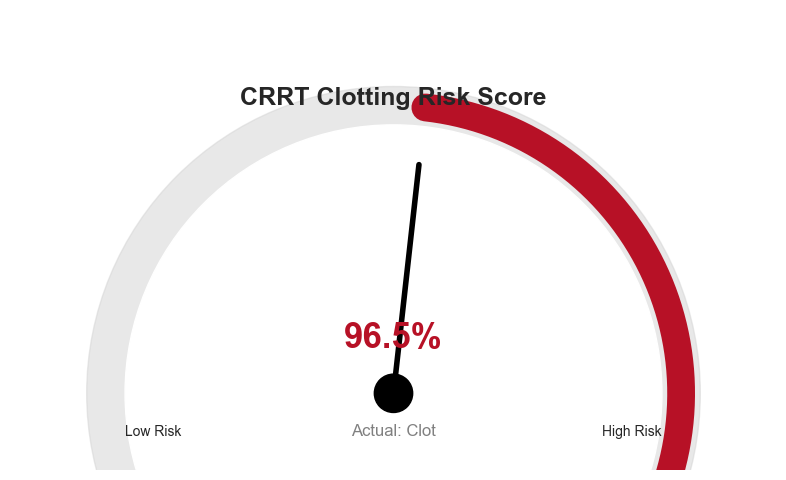

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

best_xgb = xgb_results['original']['model']

# Assuming `best_xgb` is your best XGBoost model and `X_train_scaled.columns` are your features
# And assuming `X_test_scaled` has a patient row for prediction

# For demonstration, let's pick a random patient from the test set
np.random.seed(27)
rnd_idx = np.random.randint(0, len(X_test_xgb)) # Sample from X_test_xgb, which has all engineered features
hypothetical_patient_data_scaled = X_test_xgb.iloc[[rnd_idx]]
actual_outcome = y_test.iloc[rnd_idx]

# Predict the risk score (probability of clot)
predicted_risk_score = best_xgb.predict_proba(hypothetical_patient_data_scaled)[:, 1][0]

# Create a gauge plot for the risk score
fig, ax = plt.subplots(figsize=(8, 6))

def plot_gauge(ax, value, title, min_val=0, max_val=1, cmap='RdYlGn_r'):
    norm = plt.Normalize(min_val, max_val)
    color = plt.cm.get_cmap(cmap)(norm(value))

    # Outer circle
    ax.add_patch(plt.Circle((0, 0), 0.8, color='lightgray', alpha=0.5))
    # Inner circle
    ax.add_patch(plt.Circle((0, 0), 0.7, color='white'))

    # Colored arc based on value
    theta = np.linspace(0, value * 180 / max_val, 100) # Angle from 0 to 180
    x_arc = 0.75 * np.cos(np.radians(theta - 90))
    y_arc = 0.75 * np.sin(np.radians(theta - 90))
    ax.plot(x_arc, y_arc, color=color, linewidth=20, solid_capstyle='round')

    # Needle
    angle = value * 180 / max_val
    ax.plot([0, 0.6 * np.cos(np.radians(angle - 90))],
            [0, 0.6 * np.sin(np.radians(angle - 90))],
            color='black', linewidth=4, solid_capstyle='round')
    ax.add_patch(plt.Circle((0, 0), 0.05, color='black'))

    ax.set_xlim(-1, 1)
    ax.set_ylim(-0.2, 1.0)
    ax.set_aspect('equal')
    ax.axis('off')

    # Value text
    ax.text(0, 0.1, f'{value:.1%}', ha='center', va='bottom', fontsize=25, fontweight='bold', color=color)
    ax.text(0, 0.8, title, ha='center', va='top', fontsize=18, fontweight='bold')
    ax.text(-0.7, -0.1, 'Low Risk', ha='left', va='center', fontsize=10)
    ax.text(0.7, -0.1, 'High Risk', ha='right', va='center', fontsize=10)

    ax.text(0.0, -0.1, f'Actual: {"Clot" if actual_outcome == 1 else "No Clot"}', ha='center', va='center', fontsize=12, color='gray')

plot_gauge(ax, predicted_risk_score, 'CRRT Clotting Risk Score')
plt.tight_layout()
plt.show()

In [34]:
# Update SHAP to the latest version
!pip install --upgrade shap

# Then restart your runtime and try again


[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


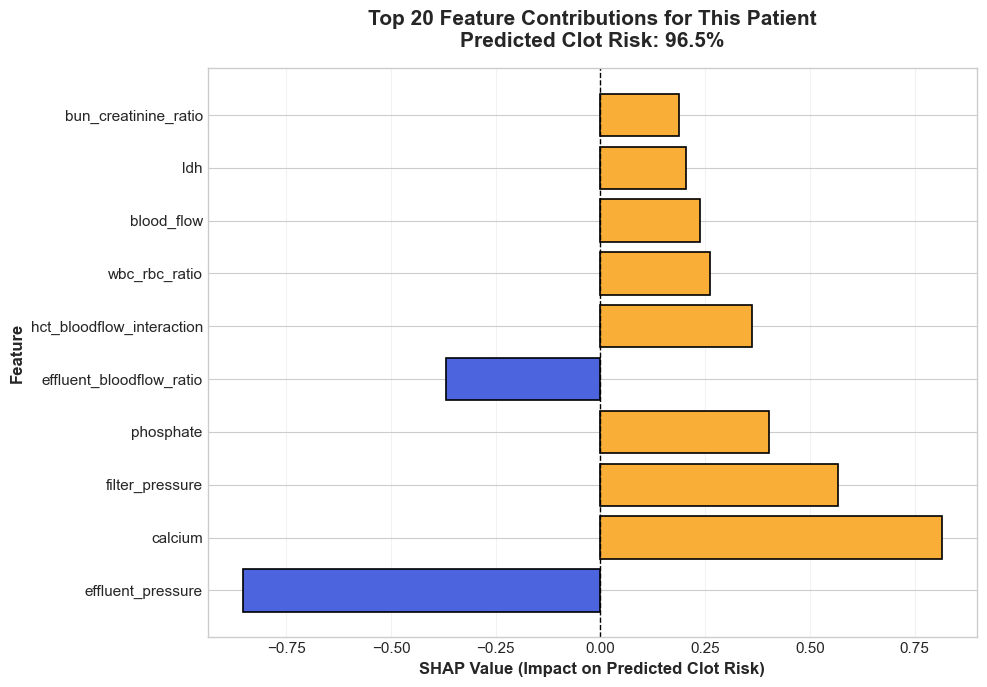

In [35]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ---- Patient Risk Prediction ----
predicted_risk_score = best_xgb.predict_proba(hypothetical_patient_data_scaled)[0,1]

# ---- Create SHAP Explainer ----
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(hypothetical_patient_data_scaled)

feature_names = X_train_xgb.columns # Corrected: Use X_train_xgb.columns

# ---- Build SHAP DataFrame ----
shap_df = pd.DataFrame({
    'feature': feature_names,
    'shap_value': shap_values[0]
}).sort_values(by='shap_value', key=abs, ascending=False).head(10)

# ---- Color Logic ----
def pick_color(val):
    if val > 0:
        return '#F9AE37'   # orange = increases clot risk
    else:
        return '#4C64DE'   # blue = decreases clot risk

shap_df['color'] = shap_df['shap_value'].apply(pick_color)

# ---- Plot ----
plt.figure(figsize=(10, 7))

plt.barh(
    shap_df['feature'],
    shap_df['shap_value'],
    color=shap_df['color'],
    edgecolor='black',
    linewidth=1.2
)

plt.xlabel("SHAP Value (Impact on Predicted Clot Risk)", fontsize=12, fontweight="bold")
plt.ylabel("Feature", fontsize=12, fontweight="bold")
plt.title(
    f"Top 20 Feature Contributions for This Patient\nPredicted Clot Risk: {predicted_risk_score:.1%}",
    fontsize=15, fontweight="bold", pad=15
)

plt.axvline(0, color='black', linestyle='--', linewidth=1)

plt.grid(axis='x', alpha=0.25)
plt.tight_layout()
plt.show()

# **Model Comparison**

### Confusion Matrices

GENERATING CONFUSION MATRICES FOR CLASSIFICATION MODELS


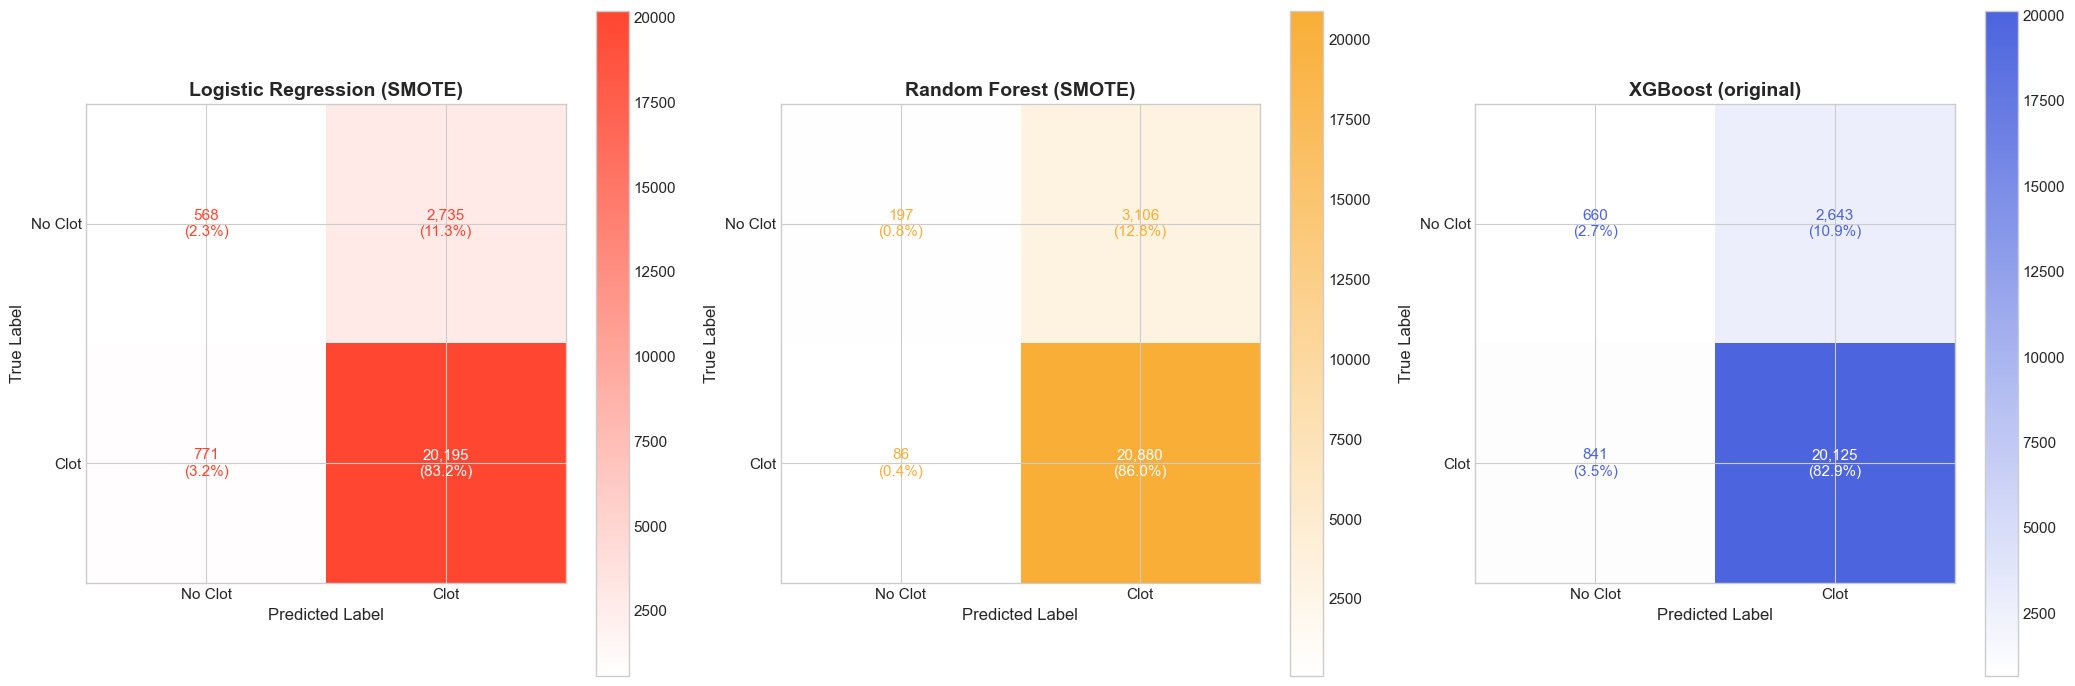

In [36]:
from matplotlib.colors import LinearSegmentedColormap

# Assuming y_test is defined and models (lr_models, rf_models, xgb_models) and results (lr_results, rf_results, xgb_results) are available
# Also assuming X_test_scaled is available for predictions if needed for model lookup

print("=" * 70)
print("GENERATING CONFUSION MATRICES FOR CLASSIFICATION MODELS")
print("=" * 70)

# Find the best resampling strategy for each model type
best_lr_name = max(lr_results.keys(), key=lambda x: lr_results[x]['roc_auc'])
best_rf_name = max(rf_results.keys(), key=lambda x: rf_results[x]['roc_auc'])
best_xgb_name = max(xgb_results.keys(), key=lambda x: xgb_results[x]['roc_auc'])

# Helper function to create a colormap from a hex color
def hex_to_cmap(hex_color, name='custom'):
    """Creates a colormap from white to the specified hex color"""
    return LinearSegmentedColormap.from_list(name, ['#FFFFFF', hex_color])

# Define your custom hex colors here
LR_COLOR = '#FF4631'   # Red
RF_COLOR = '#f9ae37'   # Gold
XGB_COLOR = '#4c64de'  # Blue

models_to_plot = {
    f'Logistic Regression ({best_lr_name})': {
        'y_pred': lr_results[best_lr_name]['y_pred'],
        'cmap': hex_to_cmap(LR_COLOR, 'lr_cmap')
    },
    f'Random Forest ({best_rf_name})': {
        'y_pred': rf_results[best_rf_name]['y_pred'],
        'cmap': hex_to_cmap(RF_COLOR, 'rf_cmap')
    },
    f'XGBoost ({best_xgb_name})': {
        'y_pred': xgb_results[best_xgb_name]['y_pred'],
        'cmap': hex_to_cmap(XGB_COLOR, 'xgb_cmap')
    }
}

fig, axes = plt.subplots(1, 3, figsize=(21, 7))
axes = axes.flatten()

for i, (model_name, data) in enumerate(models_to_plot.items()):
    cm = confusion_matrix(y_test, data['y_pred'])
    cm_percent = cm / cm.sum() * 100

    # Create annotations with both counts and percentages
    annotations = np.array([[f'{cm[i,j]:,}\n({cm_percent[i,j]:.1f}%)'
                            for j in range(2)] for i in range(2)])

    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['No Clot', 'Clot'])
    disp.plot(cmap=data['cmap'], ax=axes[i], values_format='')
    axes[i].texts[0].set_text(annotations[0, 0]) # TN
    axes[i].texts[1].set_text(annotations[0, 1]) # FP
    axes[i].texts[2].set_text(annotations[1, 0]) # FN
    axes[i].texts[3].set_text(annotations[1, 1]) # TP

    axes[i].set_title(model_name, fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Predicted Label', fontsize=12)
    axes[i].set_ylabel('True Label', fontsize=12)

plt.tight_layout()
plt.show()

In [37]:
# === EXPORT FEATURE LISTS FOR CONFIG.PY ===
print("="*60)
print("COPY THESE TO YOUR config.py")
print("="*60)

# Full features from model
full = X_train_scaled.columns.tolist()
print(f"\nFULL_FEATURES = {full}")

# Top 20 if you want more
top20 = feature_importance_df.head(20)['Feature'].tolist()
print(f"\nTOP20_FEATURES = {top20}")

COPY THESE TO YOUR config.py

FULL_FEATURES = ['access_pressure', 'blood_flow', 'citrate', 'current_goal', 'dialysate_rate', 'effluent_pressure', 'filter_pressure', 'heparin_dose', 'hourly_patient_fluid_removal', 'prefilter_replacement_rate', 'postfilter_replacement_rate', 'replacement_rate', 'return_pressure', 'ultrafiltrate_output', 'hematocrit', 'hemoglobin', 'platelet', 'rbc', 'wbc', 'fibrinogen', 'inr', 'pt', 'ptt', 'aniongap', 'bicarbonate', 'bun', 'calcium', 'chloride', 'creatinine', 'glucose', 'sodium', 'potassium', 'lactate', 'ph', 'pco2', 'magnesium', 'phosphate', 'ldh', 'bun_creatinine_ratio', 'platelet_ptt_interaction', 'hct_bloodflow_interaction', 'wbc_rbc_ratio', 'platelet_wbc_ratio', 'flow_pressure_ratio', 'platelets_squared', 'filtration_fraction', 'effluent_bloodflow_ratio', 'platelet_change', 'platelet_change_rate', 'ptt_change', 'ptt_change_rate', 'creatinine_change', 'creatinine_change_rate', 'hematocrit_change', 'hematocrit_change_rate', 'mode_heparin', 'mode_citra

MODEL COMPARISON SUMMARY

                                      Model  ROC-AUC  Avg Precision
Logistic Regression (Original (Imbalanced)) 0.682314       0.929315
      Random Forest (Original (Imbalanced)) 0.680327       0.929608
         Logistic Regression (Undersampled) 0.691775       0.931478
               Random Forest (Undersampled) 0.703326       0.933842
                Logistic Regression (SMOTE) 0.694924       0.933098
                      Random Forest (SMOTE) 0.712866       0.937436
             Logistic Regression (Combined) 0.694654       0.933031
                   Random Forest (Combined) 0.711838       0.935600
                         XGBoost (original) 0.736984       0.942609


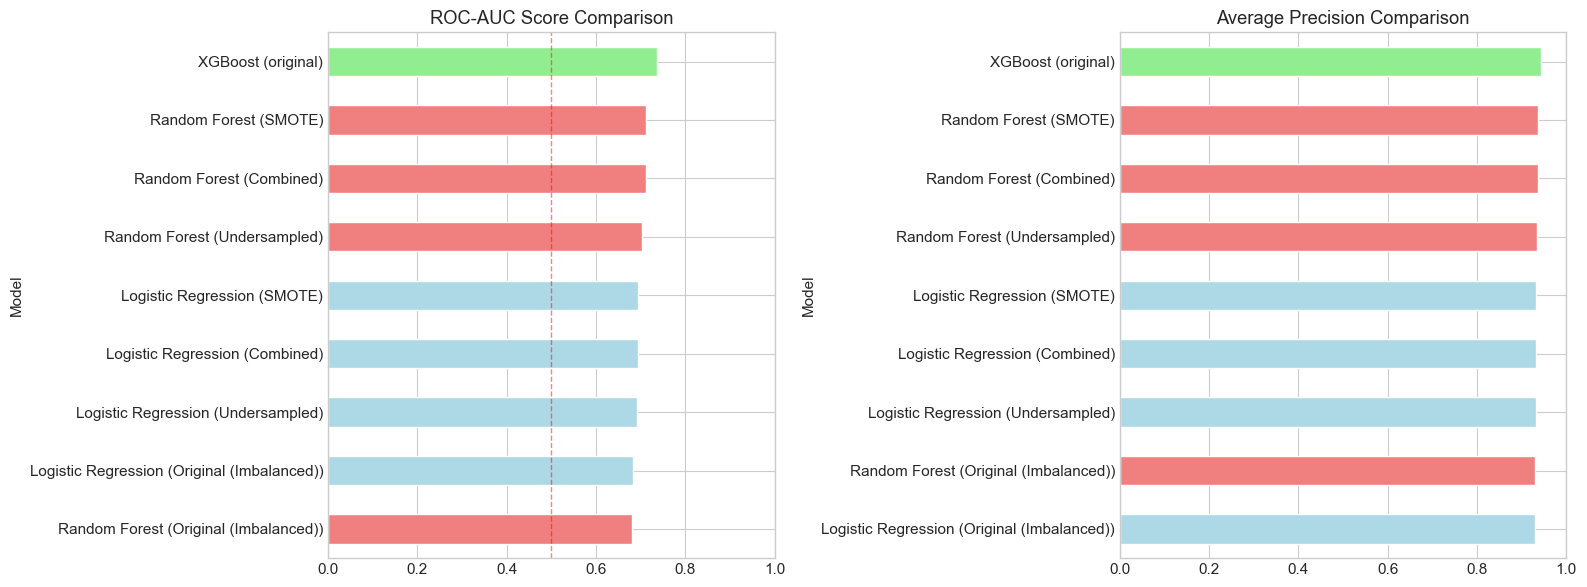


BEST MODELS:

Best ROC-AUC: XGBoost (original) = 0.7370
Best Avg Precision: XGBoost (original) = 0.9426


In [38]:
# Compare all models
print("=" * 70)
print("MODEL COMPARISON SUMMARY")
print("=" * 70)

comparison_data = []

# Add Logistic Regression + Random Forest for each training set
for name in training_sets.keys():
    # Logistic Regression
    comparison_data.append({
        'Model': f'Logistic Regression ({name})',
        'ROC-AUC': lr_results[name]['roc_auc'],
        'Avg Precision': lr_results[name]['avg_precision']
    })

    # Random Forest
    comparison_data.append({
        'Model': f'Random Forest ({name})',
        'ROC-AUC': rf_results[name]['roc_auc'],
        'Avg Precision': rf_results[name]['avg_precision']
    })

# --------------------------------------------------------------------
# ADD XGBOOST
# --------------------------------------------------------------------
comparison_data.append({
    'Model': 'XGBoost (original)',
    'ROC-AUC': xgb_results['original']['roc_auc'],
    'Avg Precision': xgb_results['original']['avg_precision']
})

# --------------------------------------------------------------------

results_df = pd.DataFrame(comparison_data)
print("\n" + results_df.to_string(index=False))

# ------------------------------
# Visualize comparison
# ------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ROC-AUC Visual
results_df_sorted = results_df.sort_values('ROC-AUC')
colors = results_df_sorted['Model'].apply(
    lambda m: 'lightgreen' if 'XGBoost' in m else
              ('lightcoral' if 'Random Forest' in m else 'lightblue')
)
results_df_sorted.plot(
    x='Model', y='ROC-AUC', kind='barh',
    ax=axes[0], legend=False, color=colors
)
axes[0].set_title('ROC-AUC Score Comparison')
axes[0].set_xlim([0, 1])
axes[0].axvline(x=0.5, color='red', linestyle='--', linewidth=1, alpha=0.5)

# Average Precision Visual
results_df_sorted = results_df.sort_values('Avg Precision')
colors = results_df_sorted['Model'].apply(
    lambda m: 'lightgreen' if 'XGBoost' in m else
              ('lightcoral' if 'Random Forest' in m else 'lightblue')
)
results_df_sorted.plot(
    x='Model', y='Avg Precision', kind='barh',
    ax=axes[1], legend=False, color=colors
)
axes[1].set_title('Average Precision Comparison')
axes[1].set_xlim([0, 1])

plt.tight_layout()
plt.show()

# ------------------------------
# Identify best models
# ------------------------------
print("\n" + "="*70)
print("BEST MODELS:")
print("="*70)

best_roc = results_df.loc[results_df['ROC-AUC'].idxmax()]
best_ap = results_df.loc[results_df['Avg Precision'].idxmax()]

print(f"\nBest ROC-AUC: {best_roc['Model']} = {best_roc['ROC-AUC']:.4f}")
print(f"Best Avg Precision: {best_ap['Model']} = {best_ap['Avg Precision']:.4f}")


## ROC Curves

The ROC Curve helps shows us how well a test can distinguish between two groups, or how well a test can see if a pt does or does NOT have a disease.
Y-axis: true positive/sensistivity
X-axis: false positive/specificity
Curve: defined by its specificity, sensitivity, and associated cutoff.


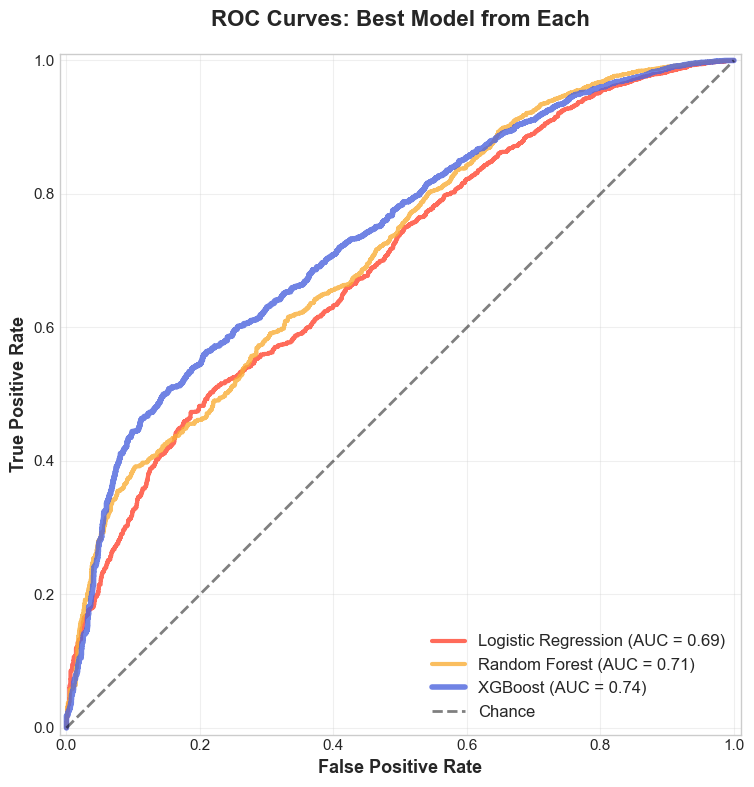

In [39]:
# ROC curves for each model, showing best one of each

fig2, ax2 = plt.subplots(figsize=(10, 8))

# Get best version of each model
lr_best = 'SMOTE'
rf_best = 'SMOTE'
xgb_best = 'Original (Imbalanced)'

# Plot best models
RocCurveDisplay.from_predictions(
    y_test, lr_results[lr_best]['y_prob'],
    ax=ax2, name=f'Logistic Regression',
    color='#FF4631', linewidth=3, alpha=0.8
)

RocCurveDisplay.from_predictions(
    y_test, rf_results[rf_best]['y_prob'],
    ax=ax2, name=f'Random Forest',
    color='#F9AE37', linewidth=3, alpha=0.8
)

RocCurveDisplay.from_predictions(
    y_test, xgb_results['original']['y_prob'],
    ax=ax2, name=f'XGBoost',
    color='#4C64DE', linewidth=4, alpha=0.8
)

# Add chance line
ax2.plot([0, 1], [0, 1], 'k--', label='Chance', alpha=0.5, linewidth=2)

# Formatting
ax2.set_title('ROC Curves: Best Model from Each',
              fontsize=16, fontweight='bold', pad=20)
ax2.legend(loc='lower right', fontsize=12, framealpha=0.95)
ax2.grid(True, alpha=0.3)
ax2.set_xlabel('False Positive Rate', fontsize=13, fontweight='bold')
ax2.set_ylabel('True Positive Rate', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

My random notes: early plateau in RF curves (orange curves rise quickly then flatten..). Means RF is good at high specificity but struggles with high sensitivity, aka good at ruling out clots, but misses some true positives. Will try feature engineering maybe...

Also, LR sucks, barely better than random. suggests the obvious of non-linear relationships in the data.

## Precision Recall Curves

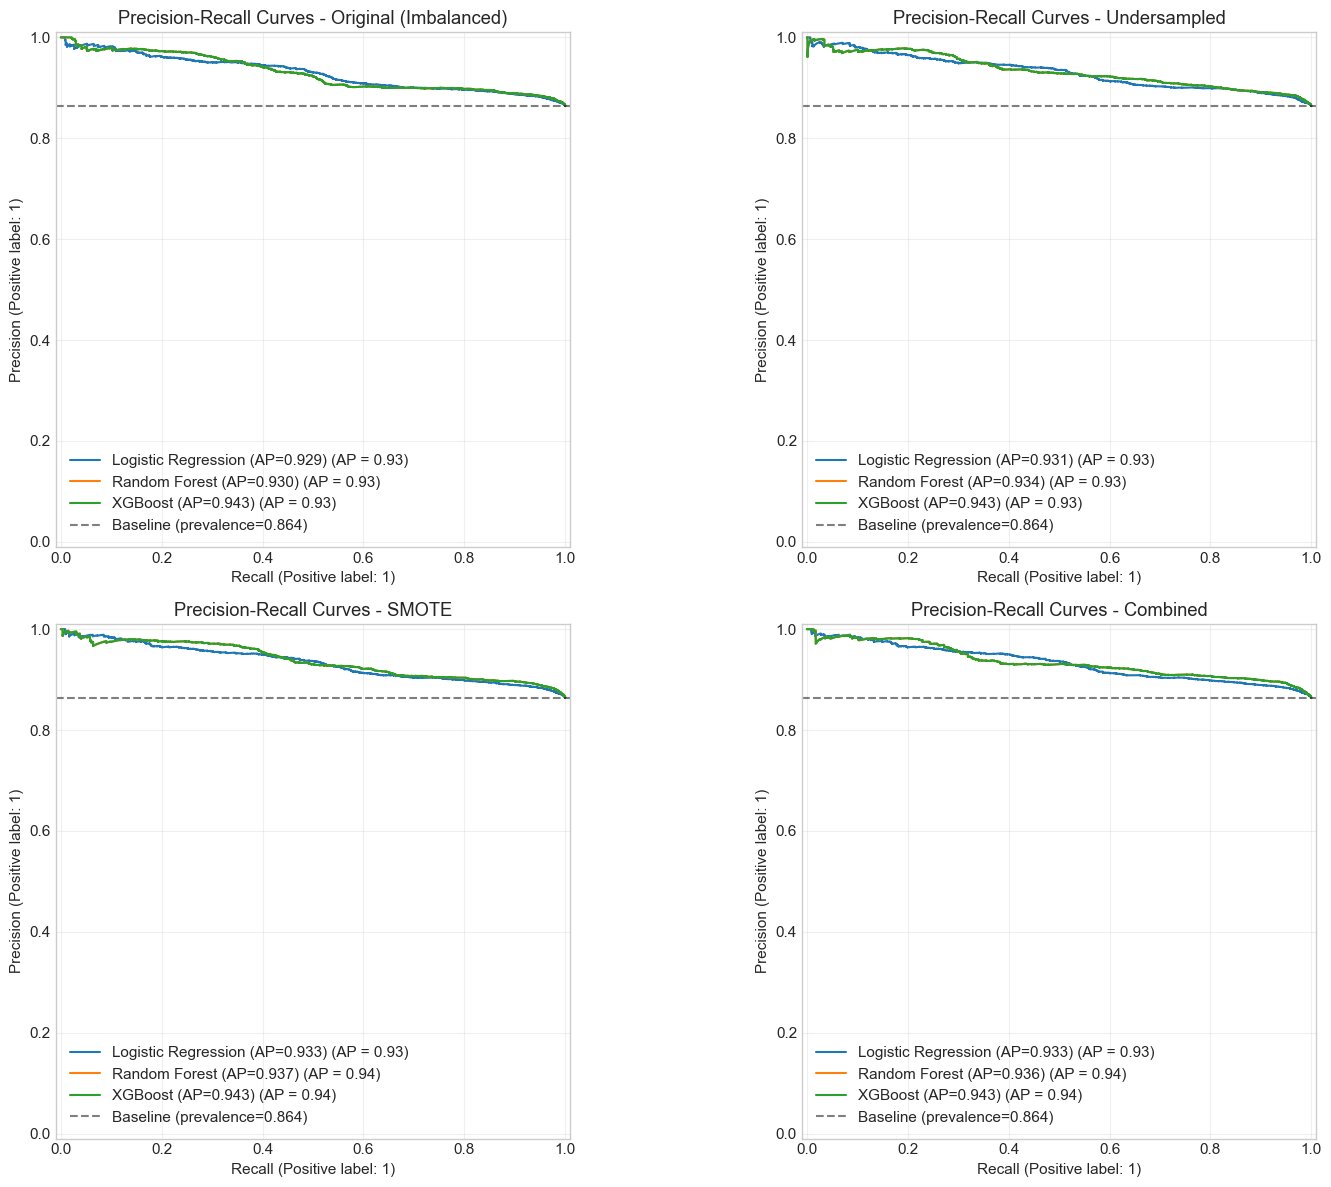

In [40]:
# Plot Precision-Recall curves (more informative for imbalanced data)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

for idx, (name, _) in enumerate(training_sets.items()):
    ax = axes[idx]

    # Plot both LR and RF
    PrecisionRecallDisplay.from_predictions(
        y_test, lr_results[name]['y_prob'],
        ax=ax, name=f'Logistic Regression (AP={lr_results[name]["avg_precision"]:.3f})'
    )
    PrecisionRecallDisplay.from_predictions(
        y_test, rf_results[name]['y_prob'],
        ax=ax, name=f'Random Forest (AP={rf_results[name]["avg_precision"]:.3f})'
    )
    PrecisionRecallDisplay.from_predictions(
        y_test, rf_results[name]['y_prob'],
        ax=ax, name=f'XGBoost (AP={xgb_results['original']["avg_precision"]:.3f})'
    )

    # Baseline (proportion of positive class)
    baseline = y_test.mean()
    ax.axhline(y=baseline, color='k', linestyle='--',
               label=f'Baseline (prevalence={baseline:.3f})', alpha=0.5)

    ax.set_title(f'Precision-Recall Curves - {name}')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

CONFUSION MATRICES - BEST MODELS


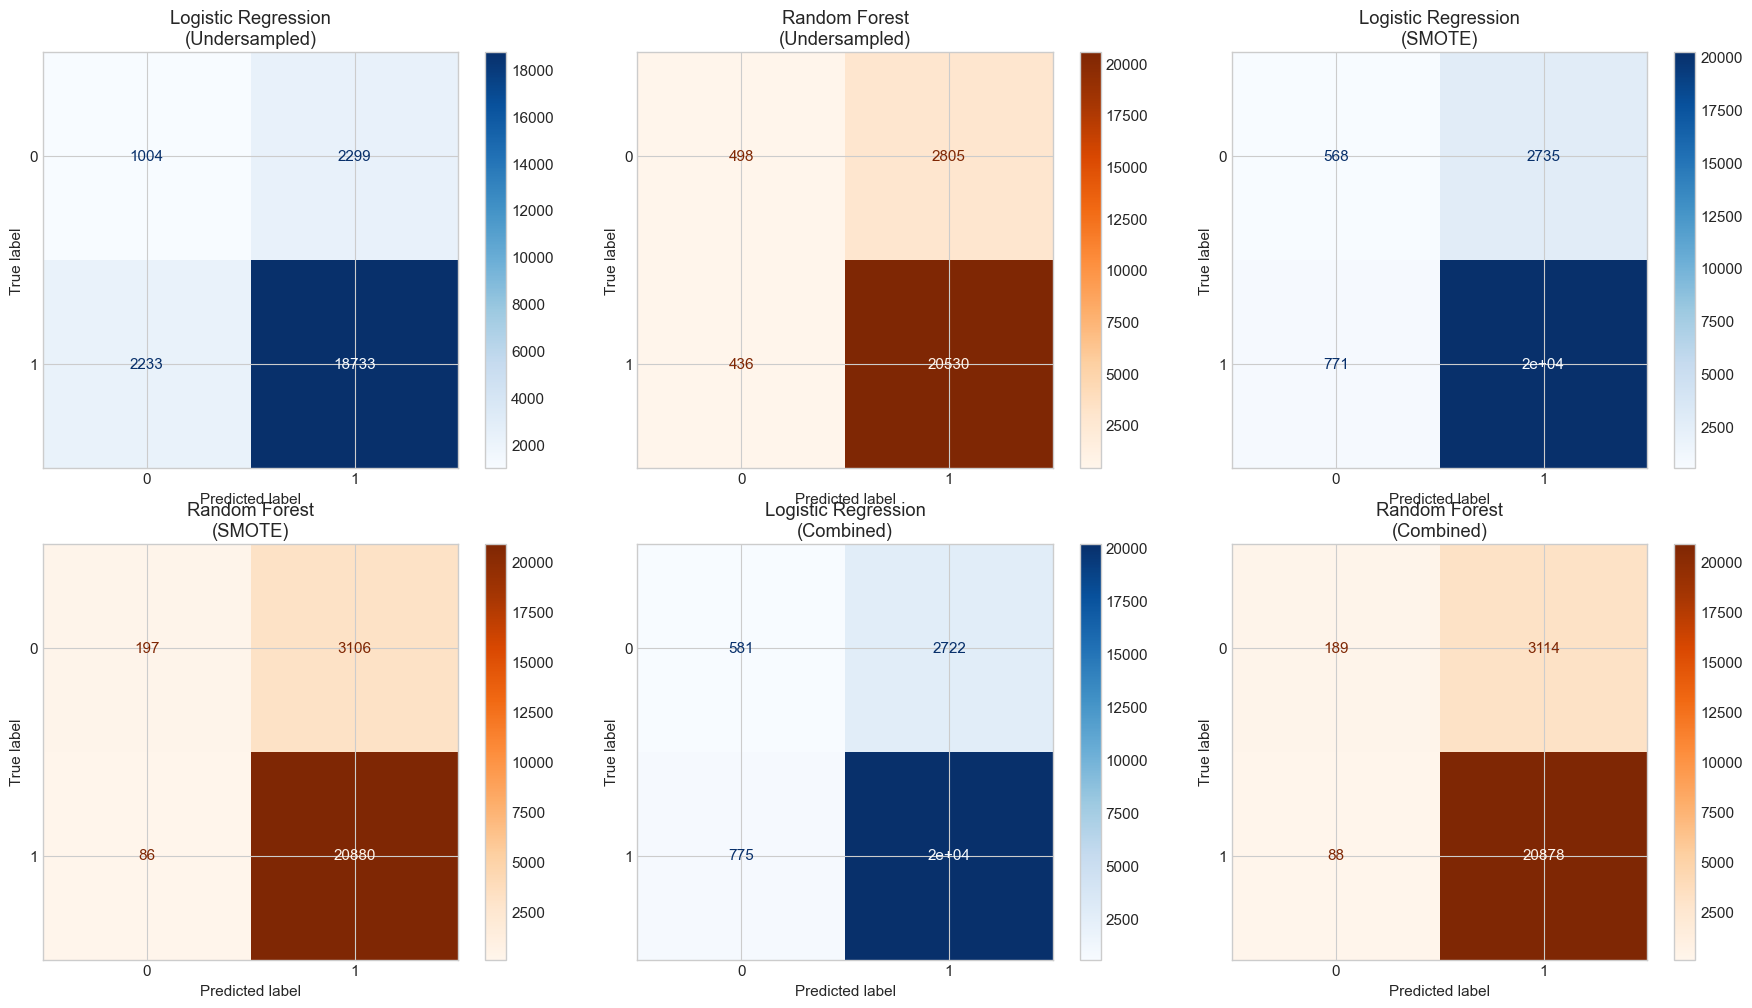

In [41]:
# Confusion matrices for best performing models
print("=" * 70)
print("CONFUSION MATRICES - BEST MODELS")
print("=" * 70)

# Show confusion matrices for resampled models
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

plot_idx = 0
for name in ['Undersampled', 'SMOTE', 'Combined']:
    # Logistic Regression
    ConfusionMatrixDisplay.from_predictions(
        y_test, lr_results[name]['y_pred'],
        ax=axes[plot_idx], cmap='Blues'
    )
    axes[plot_idx].set_title(f'Logistic Regression\n({name})')
    plot_idx += 1

    # Random Forest
    ConfusionMatrixDisplay.from_predictions(
        y_test, rf_results[name]['y_pred'],
        ax=axes[plot_idx], cmap='Oranges'
    )
    axes[plot_idx].set_title(f'Random Forest\n({name})')
    plot_idx += 1

plt.tight_layout()
plt.show()

### Best Logistic Regression Model

FEATURE IMPORTANCE - Logistic Regression (SMOTE)

Top 20 Most Important Features:
                  Feature  Coefficient
          filter_pressure     8.884968
        effluent_pressure    -0.543027
                      rbc    -0.450576
 effluent_bloodflow_ratio     0.435825
      filtration_fraction    -0.427127
     ultrafiltrate_output     0.374828
               hemoglobin     0.358007
        platelets_squared     0.336920
          return_pressure    -0.303714
                  calcium     0.251330
                phosphate    -0.244650
                 platelet    -0.228041
                 chloride    -0.224949
           dialysate_rate    -0.216060
              bicarbonate    -0.213813
hct_bloodflow_interaction    -0.175829
               blood_flow     0.169145
                   sodium     0.163572
                 aniongap    -0.162035
      flow_pressure_ratio     0.150116


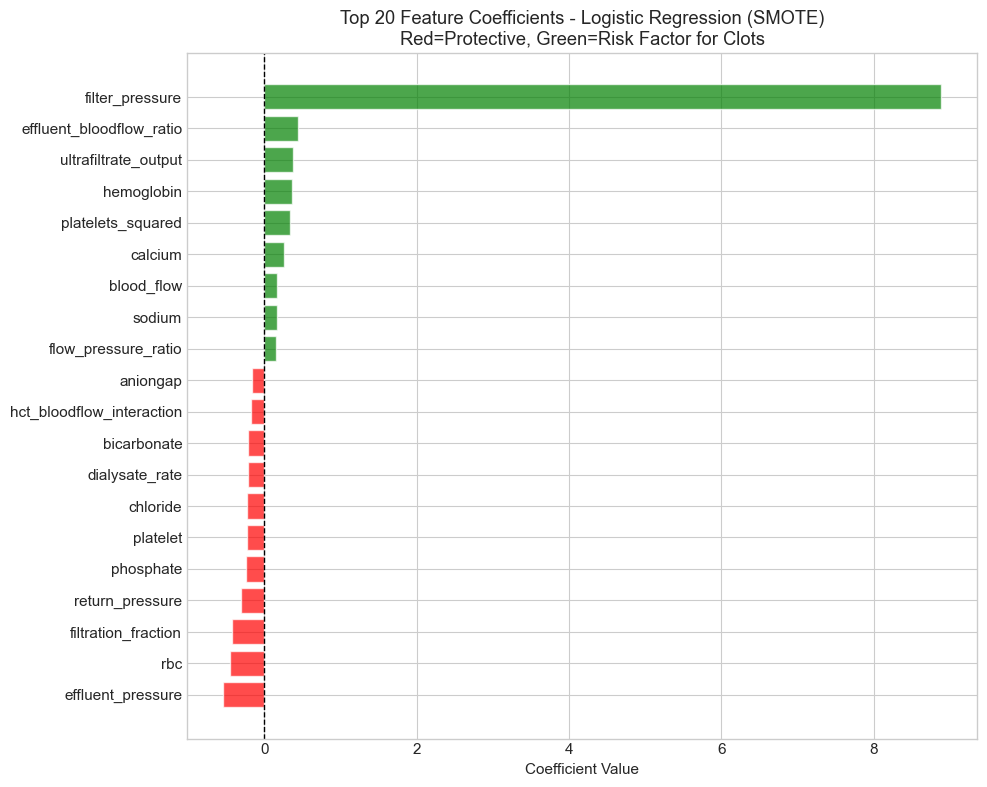

In [42]:
# Feature importance from best Logistic Regression model
best_lr_name = max(lr_results.keys(), key=lambda k: lr_results[k]['avg_precision'])
best_lr = lr_models[best_lr_name]

print("=" * 70)
print(f"FEATURE IMPORTANCE - Logistic Regression ({best_lr_name})")
print("=" * 70)

coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': best_lr.coef_[0]
}).sort_values(by='Coefficient', key=abs, ascending=False)

print("\nTop 20 Most Important Features:")
print(coef_df.head(20).to_string(index=False))

# Visualize
plt.figure(figsize=(10, 8))
top_features = coef_df.head(20).sort_values('Coefficient')
colors = ['red' if x < 0 else 'green' for x in top_features['Coefficient']]
plt.barh(range(len(top_features)), top_features['Coefficient'], color=colors, alpha=0.7)
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.xlabel('Coefficient Value')
plt.title(f'Top 20 Feature Coefficients - Logistic Regression ({best_lr_name})\nRed=Protective, Green=Risk Factor for Clots')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()

### Best Random Forest Model

FEATURE IMPORTANCE - Random Forest (SMOTE)

Top 20 Most Important Features:
                   Feature  Importance
                 phosphate    0.072176
                creatinine    0.047831
         effluent_pressure    0.045696
                   calcium    0.041909
  effluent_bloodflow_ratio    0.040885
           filter_pressure    0.036384
                       bun    0.035935
          replacement_rate    0.028406
                       ldh    0.028244
prefilter_replacement_rate    0.027071
                       ptt    0.023501
                blood_flow    0.023388
 hct_bloodflow_interaction    0.023352
       flow_pressure_ratio    0.022526
      bun_creatinine_ratio    0.021259
                       rbc    0.019709
                       wbc    0.019636
                 potassium    0.018574
            dialysate_rate    0.018412
           return_pressure    0.018303


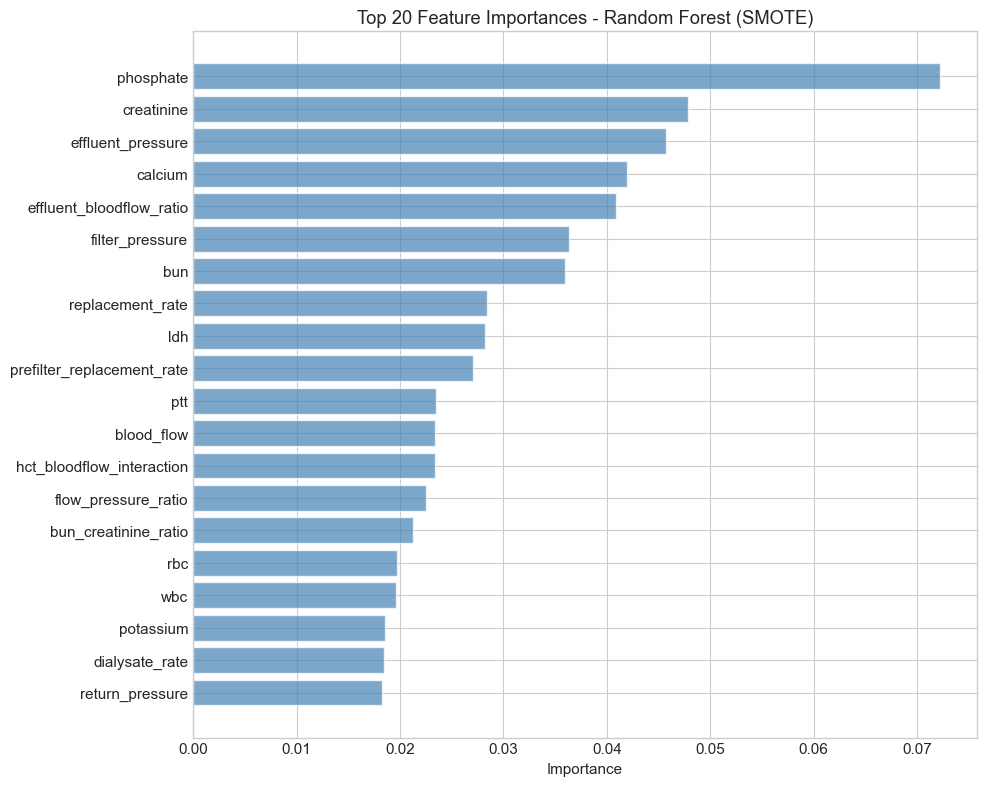

In [43]:
# Feature importance from best Random Forest model
best_rf_name = max(rf_results.keys(), key=lambda k: rf_results[k]['avg_precision'])
best_rf = rf_models[best_rf_name]

print("=" * 70)
print(f"FEATURE IMPORTANCE - Random Forest ({best_rf_name})")
print("=" * 70)

importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nTop 20 Most Important Features:")
print(importance_df.head(20).to_string(index=False))

# Visualize
plt.figure(figsize=(10, 8))
top_features = importance_df.head(20).sort_values('Importance')
plt.barh(range(len(top_features)), top_features['Importance'], color='steelblue', alpha=0.7)
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.xlabel('Importance')
plt.title(f'Top 20 Feature Importances - Random Forest ({best_rf_name})')
plt.tight_layout()
plt.show()

In [44]:
# Get all numeric features available in the scaled training data
all_numeric_features = X_train_scaled.columns.tolist()

# Define features that are NOT strictly lab values (machine parameters, engineered, temporal)
non_lab_features = [
    # Machine parameters
    'access_pressure', 'blood_flow', 'citrate', 'current_goal', 'dialysate_rate',
    'effluent_pressure', 'filter_pressure', 'heparin_dose', 'hourly_patient_fluid_removal',
    'prefilter_replacement_rate', 'postfilter_replacement_rate', 'replacement_rate',
    'return_pressure', 'ultrafiltrate_output', 'system_active',
    # Engineered/Derived features
    'high_pressure', 'bun_creatinine_ratio', 'hct_bloodflow_interaction',
    'wbc_rbc_ratio', 'flow_pressure_ratio', 'ptt_squared',
    # Temporal features
    'hour_of_day', 'day_of_week', 'is_weekend', 'is_night_shift', 'hours_since_last',
    'ptt_change', 'ptt_change_rate', 'creatinine_change', 'creatinine_change_rate',
    'hematocrit_change', 'hematocrit_change_rate', 'prior_clots_count'
]

# Filter out non-lab features to get the final list of lab-only columns
labs_only_cols = [f for f in all_numeric_features if f not in non_lab_features]

print(f"Defined 'labs_only_cols' with {len(labs_only_cols)} features:")
print(labs_only_cols)


Defined 'labs_only_cols' with 34 features:
['hematocrit', 'hemoglobin', 'platelet', 'rbc', 'wbc', 'fibrinogen', 'inr', 'pt', 'ptt', 'aniongap', 'bicarbonate', 'bun', 'calcium', 'chloride', 'creatinine', 'glucose', 'sodium', 'potassium', 'lactate', 'ph', 'pco2', 'magnesium', 'phosphate', 'ldh', 'platelet_ptt_interaction', 'platelet_wbc_ratio', 'platelets_squared', 'filtration_fraction', 'effluent_bloodflow_ratio', 'platelet_change', 'platelet_change_rate', 'mode_heparin', 'mode_citrate', 'mode_none']
